<a href="https://colab.research.google.com/github/caioadlc/TCC_IA_BIG_DATA/blob/main/hurdle_mlp.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 0. About

O objetivo deste notebook é realizar análises exploratórias sobre os data sets previamente minerados e disponibilizados em arquivos .csv.

Através dessa análise vamos realizar validações prévias, compreender o compartamento das features e levantar hipoteses.


# 1. Imports, Functions & Options

## 1.1. Imports

In [ ]:
!pip install umap-learn shap catboost imgaug optuna python-bcb category_encoders

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 948.0/948.0 kB 22.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 442.4/442.4 kB 18.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 107.9/107.9 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 268.7/268.7 kB 5.8 MB/s eta 0:00:00


In [ ]:
# Sistema
import os
import zipfile
import requests
from pathlib import Path
import unicodedata

# Principais imports
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import polars as pl
import datetime
from google.colab import drive
drive.mount('/content/drive')

# Classificadores
from sklearn import tree
from sklearn.tree import DecisionTreeClassifier # Arvore de Decisao
from sklearn.ensemble import RandomForestClassifier # Floresta de Decisao
from sklearn.svm import SVC # Support Vector Machine
from xgboost import XGBClassifier # XGBoost
from lightgbm import LGBMClassifier # LGBM
from sklearn.svm import LinearSVC # Linear Support Vector Machine
from sklearn.dummy import DummyClassifier # Classificador aleatorio
from catboost import CatBoostClassifier # CatBoost
from sklearn.linear_model import LogisticRegression # Regressao Logistica

# Calibração
from sklearn.isotonic import IsotonicRegression
from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss

# Regressores
from sklearn.ensemble import RandomForestRegressor
from lightgbm import LGBMRegressor
from sklearn.svm import LinearSVR
from xgboost import XGBRegressor
from catboost import CatBoostRegressor
from sklearn.linear_model import ElasticNet
from sklearn.linear_model import Ridge

# Clustering
from sklearn.cluster import KMeans

# Avaliadores
from sklearn.metrics import classification_report # Acc, Precision, Recall e F1-Score
from sklearn.metrics import ConfusionMatrixDisplay # Matriz de confusao
from sklearn.metrics import recall_score, precision_score, f1_score, roc_curve, roc_auc_score, accuracy_score # Metricas
from sklearn.model_selection import cross_val_score # CrossValidation com uma metrica
from sklearn.model_selection import cross_validate # CrossValidation com mais de uma metrica
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error

# Pre processamento
from sklearn.preprocessing import StandardScaler # Normaliza feature media = 0 e desvpad = 1
from sklearn.preprocessing import OneHotEncoder # Encoda uma coluna categorica
from sklearn.impute import SimpleImputer # Imputer: Preenche uma determinada feature
from imblearn.over_sampling import SMOTE # SMOTE

# Datasets nativos SKLearn
from sklearn.datasets import load_digits # Digitos Manuscritos

# DeepLearning
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, callbacks

# Utilidades
from sklearn.pipeline import make_pipeline # Cria pipeline
from sklearn.pipeline import Pipeline # Executa um pipeline
from sklearn.compose import ColumnTransformer # Aplica transformacoes em colunas
from sklearn.model_selection import train_test_split # Separa treino e teste
from sklearn.model_selection import StratifiedKFold # Estratifica os dados igualmente
from sklearn.model_selection import GridSearchCV # Busca exaustiva
from sklearn.model_selection import RandomizedSearchCV # Busca exaustiva aleatória
from sklearn.manifold import TSNE # TSNE visualização de clusters
import umap # umap visualização de clusters
import shap # Feature Importances
import optuna # Busca Bayesiana
from sklearn.decomposition import PCA # Redução de dimensionalidade
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.preprocessing import TargetEncoder

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 1.2. Functions

In [ ]:
# Funções úteis

def split(df, t_size, v_size, target, random):
    '''
    df: DataFrame a ser splitado
    t_size: Proporcao do teste
    v_size: Proporcao da Validacao
    target: Variavel target para o stratify
    random: Random state
    '''

    train_df, test_df = train_test_split(df,
                                        test_size = t_size,
                                        random_state = random,
                                        # stratify = df[target],
                                        shuffle = True)

    train_df, valid_df = train_test_split(train_df,
                                        test_size = v_size,
                                        random_state = random,
                                        # stratify = train_df[target],
                                        shuffle = True)

    print('Observacoes por DataFrame')
    print(f' Treino {train_df.shape[0]}')
    print(f' Validacao {valid_df.shape[0]}')
    print(f' Teste {test_df.shape[0]}')
    print('-----------------------------')
    print('Proporçao dos DataFrames')
    print(f' Treino {round(train_df.shape[0]/df.shape[0], 2)}')
    print(f' Validacao {round(valid_df.shape[0]/df.shape[0], 2)}')
    print(f' Teste {round(test_df.shape[0]/df.shape[0], 2)}')

    return train_df, valid_df, test_df

def avalia_modelos_c(y_true, preds, preds_prob = None):
    '''
    y_true: Target do Modelo (binário)
    preds: Predict binarizado do modelo (após threshold)
    preds_prob: Probabilidades contínuas do modelo (antes do threshold) — necessário para AUC
    '''
    resultado = {
        'Accuracy': accuracy_score(y_true, preds),
        'Recall': recall_score(y_true, preds),
        'Precision': precision_score(y_true, preds),
        'F1 Score': f1_score(y_true, preds),
    }

    if preds_prob is not None:
        resultado['AUC'] = roc_auc_score(y_true, preds_prob)

    return resultado


def avalia_modelos_r(y_true, preds):
    """
    Avalia modelos de regressão.

    Parameters
    ----------
    y_true : array-like
        Valores reais.
    preds : array-like
        Predições do modelo.

    Returns
    -------
    dict
        Dicionário com as métricas de avaliação.
    """

    return {
        "MAE": mean_absolute_error(y_true, preds),
        "MSE": mean_squared_error(y_true, preds),
        "RMSE": np.sqrt(mean_squared_error(y_true, preds)),
        "R²": r2_score(y_true, preds)
    }

def verif_nulls(df):
    '''
    Verifica presença de nullos em um DF spark
    '''
    cols = df.columns
    print('Verificando nullos...')
    for col in cols:
        print(f'Quantidade de Nulls em {col}: {df.filter(f.col(col).isNull()).count()}')

def count_unique(df):
    '''
    Conta quantos valores distintos as features de um determinado df recebe
    '''
    print('Contando distintos...')
    for col in df.columns:
        print(f'Distintos na feature {col}: {df[col].nunique()}')

## 1.3. Options

In [ ]:
# Parametros Modelos
p_test_size = 0.2
p_valid_size = 0.2
p_random = 42

# Pandas Options
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)

# Paleta
palette = ['#1F4E79', # Azul escuro
           '#4F81BD', # Azul médio
           '#9E9E9E', # Cinza
           '#D55E00', # Laranja queimado
           '#009E73'  # Verde petróleo
    ]

# 2. Load Data

## 2.1. SCR (BACEN)

In [ ]:
# df_scr: Variável que vai receber os DataFrames do SCR empilhados
df_scr = pd.DataFrame([])

# Lista de anos a serem processados
lista_anos = [2023, 2024, 2025]

# Path dos dados
data_path = '/content/drive/MyDrive/Estudos/USP/MBA/TCC/Projeto/data'

# Pipeline de processamento dos dados
for ano in lista_anos:
    lista_data = sorted(os.listdir(f"{data_path}/scrdata_{ano}"))
    print(f'Processando Pasta {ano}...')
    for arq_mes in lista_data:
        df = pd.read_csv(f'{data_path}/scrdata_{ano}/{arq_mes}', sep = ';')
        df = df[df['cliente'] == 'PJ']
        df_scr = pd.concat([df_scr, df], ignore_index = False)
        print(f'├─ Arquivo {arq_mes} processado!')
    print(f'└─ Pasta {ano} processada!')

Processando Pasta 2023...
├─ Arquivo scrdata_202310.csv processado!
├─ Arquivo scrdata_202311.csv processado!
├─ Arquivo scrdata_202312.csv processado!
└─ Pasta 2023 processada!
Processando Pasta 2024...
├─ Arquivo scrdata_202401.csv processado!
├─ Arquivo scrdata_202402.csv processado!
├─ Arquivo scrdata_202403.csv processado!
├─ Arquivo scrdata_202404.csv processado!
├─ Arquivo scrdata_202405.csv processado!
├─ Arquivo scrdata_202406.csv processado!
├─ Arquivo scrdata_202407.csv processado!
├─ Arquivo scrdata_202408.csv processado!
├─ Arquivo scrdata_202409.csv processado!
├─ Arquivo scrdata_202410.csv processado!
├─ Arquivo scrdata_202411.csv processado!
├─ Arquivo scrdata_202412.csv processado!
└─ Pasta 2024 processada!
Processando Pasta 2025...
├─ Arquivo scrdata_202501.csv processado!
├─ Arquivo scrdata_202502.csv processado!
├─ Arquivo scrdata_202503.csv processado!
├─ Arquivo scrdata_202504.csv processado!
├─ Arquivo scrdata_202505.csv processado!
├─ Arquivo scrdata_202506.csv 

In [ ]:
df_scr['anomes'] = df_scr['data_base'].astype(str).str[:4] + df_scr['data_base'].astype(str).str[5:7]

## 2.2. BACEN (SELIC)

In [ ]:
# Taxa de juros - Selic
url = 'https://api.bcb.gov.br/dados/serie/bcdata.sgs.1178/dados?formato=json&dataInicial=01/01/2020&dataFinal=31/12/2026'
dados = requests.get(url).json()
df_selic = pd.DataFrame(dados).rename(columns = {'valor': 'txa_selic'})

# Ajusta a feature 'txa_selic'
df_selic['txa_selic'] = pd.to_numeric(
    df_selic['txa_selic'],
    errors='coerce'
)

# Tratamento da variável anomes
df_selic['anomes'] = pd.to_datetime(
    df_selic['data'],
    format='%d/%m/%Y'
).dt.strftime('%Y%m')
df_selic = df_selic.drop(columns = ['data'])\
                .drop_duplicates(['anomes'])\
                .reset_index(drop = True)

## 2.3. IBGE (INPC)

In [ ]:
# Índice Nacional de Preços ao Consumidor Amplo
# url = 'https://apisidra.ibge.gov.br/values/t/1419/n1/all/v/all/p/all/c315/7169,7170,7445,7486,7558,7625,7660,7712,7766,7786/d/v63%202,v66%204,v69%202,v2265%202?formato=json'
# dados = requests.get(url).json()
# df_ipca = pd.DataFrame(dados[1:]).rename(columns = dados[0])

# rename_cols = {
#     'Nível Territorial (Código)': 'cod_nivel_terri',
#     'Nível Territorial': 'nivel_terri',
#     'Unidade de Medida (Código)': 'cod_unid_med',
#     'Unidade de Medida': 'unid_med',
#     'Valor': 'valor',
#     'Brasil (Código)': 'cod_brasil',
#     'Brasil': 'brasil',
#     'Variável (Código)': 'cod_variavel',
#     'Variável': 'variavel',
#     'Mês (Código)': 'anomes',
#     'Mês': 'mes',
#     'Geral, grupo, subgrupo, item e subitem (Código)': 'cod_categoria_ipca',
#     'Geral, grupo, subgrupo, item e subitem': 'categoria_ipca'
# }

# df_ipca = df_ipca.rename(columns = rename_cols)

# Índice Nacional de Preços ao Consumidor - INPC
url = 'https://apisidra.ibge.gov.br/values/t/1736/n1/all/v/all/p/all/d/v44%202,v68%202,v2289%2013,v2290%202,v2291%202,v2292%202?formato=json'
dados = requests.get(url).json()
df_inpc = pd.DataFrame(dados[1:]).rename(columns = dados[0])

rename_cols = {
    'Nível Territorial (Código)': 'cod_nivel_terri',
    'Nível Territorial': 'nivel_terri',
    'Unidade de Medida (Código)': 'cod_unidade_medida',
    'Unidade de Medida': 'unidade_medida',
    'Valor': 'vl_inpc',
    'Brasil (Código)': 'cod_brasil',
    'Brasil': 'brasil',
    'Variável (Código)': 'cod_variavel',
    'Variável': 'variavel',
    'Mês (Código)': 'anomes',
    'Mês': 'mes'
}

df_inpc = df_inpc.rename(columns = rename_cols)

# 2. Data Exploration

## 2.1. SCR

In [ ]:
df_scr.head()

,data_base,uf,segmento,cliente,cnae_ocupacao,porte,modalidade,submodalidade,origem,indexador,numero_de_operacoes,a_vencer_ate_90_dias,a_vencer_de_91_ate_360_dias,a_vencer_de_361_ate_1080_dias,a_vencer_de_1081_ate_1800_dias,a_vencer_de_1801_ate_5400_dias,a_vencer_acima_de_5400_dias,carteira_a_vencer,vencido_de_15_ate_90_dias,vencido_acima_de_90_dias,carteira_vencida,carteira_ativa,carteira_inadimplencia,ativo_problematico,anomes
0,2023-10-31,AC,Arrendamento,PJ,Comércio; reparação de veículos automotores e ...,Médio,Operações de arrendamento,Arrendamento financeiro exceto veículos automo...,Sem destinação específica,Prefixado,-1,"193583,25","504705,04","1186770,39","429065,71","0,00","0,00","2314124,39","0,00","0,00","0,00","2314124,39","0,00","0,00",202310
2051,2023-10-31,AC,Banco,PJ,"Administração pública, defesa e seguridade social",Grande,Empréstimos,Capital de giro com prazo de vencimento superi...,Sem destinação específica,Flutuantes,-1,"1279514,11","2951544,24","7870784,64","7542835,28","6558993,04","0,00","26203671,31","0,00","0,00","0,00","26203671,31","0,00","0,00",202310
2052,2023-10-31,AC,Banco,PJ,"Administração pública, defesa e seguridade social",Grande,Financiamentos,Financiamento de projeto,Com destinação específica,Pós-fixado,-1,"1328276,46","3984829,38","10626211,68","10183452,86","19995964,24","22546688,76","68665423,38","0,00","0,00","0,00","68665423,38","0,00","0,00",202310
2053,2023-10-31,AC,Banco,PJ,"Administração pública, defesa e seguridade social",Grande,Financiamentos,Outros financiamentos,Sem destinação específica,Flutuantes,-1,"2585385,45","7756156,35","20683083,60","7570568,65","0,00","0,00","38595194,05","0,00","0,00","0,00","38595194,05","0,00","0,00",202310
2054,2023-10-31,AC,Banco,PJ,"Administração pública, defesa e seguridade social",Grande,Financiamentos de infraestrutura e desenvolvim...,Financiamento de infraestrutura e desenvolvimento,Com destinação específica,Flutuantes,-1,"9986490,78","29142683,45","72100130,46","64739730,87","40638425,73","0,00","216607461,29","0,00","0,00","0,00","216607461,29","0,00","0,00",202310


In [ ]:
df_scr.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3390054 entries, 0 to 308699
Data columns (total 25 columns):
 #   Column                          Dtype 
---  ------                          ----- 
 0   data_base                       object
 1   uf                              object
 2   segmento                        object
 3   cliente                         object
 4   cnae_ocupacao                   object
 5   porte                           object
 6   modalidade                      object
 7   submodalidade                   object
 8   origem                          object
 9   indexador                       object
 10  numero_de_operacoes             int64 
 11  a_vencer_ate_90_dias            object
 12  a_vencer_de_91_ate_360_dias     object
 13  a_vencer_de_361_ate_1080_dias   object
 14  a_vencer_de_1081_ate_1800_dias  object
 15  a_vencer_de_1801_ate_5400_dias  object
 16  a_vencer_acima_de_5400_dias     object
 17  carteira_a_vencer               object
 18  vencido_

In [ ]:
to_num = ['numero_de_operacoes', 'a_vencer_ate_90_dias', 'a_vencer_de_91_ate_360_dias', 'a_vencer_de_361_ate_1080_dias',
          'a_vencer_de_1081_ate_1800_dias', 'a_vencer_de_1801_ate_5400_dias', 'a_vencer_acima_de_5400_dias', 'carteira_a_vencer',
          'vencido_de_15_ate_90_dias', 'vencido_acima_de_90_dias', 'carteira_vencida', 'carteira_ativa', 'carteira_inadimplencia',
          'ativo_problematico']

for col in to_num:
    df_scr[col] = pd.to_numeric(df_scr[col].astype('str').str.replace(',', '.'), errors = 'coerce').astype('float64')

In [ ]:
df_scr['data_base'] = pd.to_datetime(df_scr['data_base'])
df_scr['anomes_m1'] = (df_scr['data_base'] - pd.DateOffset(months=1)).dt.strftime('%Y%m')
df_scr['anomes_m3'] = (df_scr['data_base'] - pd.DateOffset(months=3)).dt.strftime('%Y%m')
df_scr['anomes_m6'] = (df_scr['data_base'] - pd.DateOffset(months=6)).dt.strftime('%Y%m')

In [ ]:
df_scr

,data_base,uf,segmento,cliente,cnae_ocupacao,porte,modalidade,submodalidade,origem,indexador,numero_de_operacoes,a_vencer_ate_90_dias,a_vencer_de_91_ate_360_dias,a_vencer_de_361_ate_1080_dias,a_vencer_de_1081_ate_1800_dias,a_vencer_de_1801_ate_5400_dias,a_vencer_acima_de_5400_dias,carteira_a_vencer,vencido_de_15_ate_90_dias,vencido_acima_de_90_dias,carteira_vencida,carteira_ativa,carteira_inadimplencia,ativo_problematico,anomes,anomes_m1,anomes_m3,anomes_m6
0,2023-10-31,AC,Arrendamento,PJ,Comércio; reparação de veículos automotores e ...,Médio,Operações de arrendamento,Arrendamento financeiro exceto veículos automo...,Sem destinação específica,Prefixado,-1.0000,193583.2500,504705.0400,1186770.3900,429065.7100,0.0000,0.0000,2314124.3900,0.0000,0.0000,0.0000,2314124.3900,0.0000,0.0000,202310,202309,202307,202304
2051,2023-10-31,AC,Banco,PJ,"Administração pública, defesa e seguridade social",Grande,Empréstimos,Capital de giro com prazo de vencimento superi...,Sem destinação específica,Flutuantes,-1.0000,1279514.1100,2951544.2400,7870784.6400,7542835.2800,6558993.0400,0.0000,26203671.3100,0.0000,0.0000,0.0000,26203671.3100,0.0000,0.0000,202310,202309,202307,202304
2052,2023-10-31,AC,Banco,PJ,"Administração pública, defesa e seguridade social",Grande,Financiamentos,Financiamento de projeto,Com destinação específica,Pós-fixado,-1.0000,1328276.4600,3984829.3800,10626211.6800,10183452.8600,19995964.2400,22546688.7600,68665423.3800,0.0000,0.0000,0.0000,68665423.3800,0.0000,0.0000,202310,202309,202307,202304
2053,2023-10-31,AC,Banco,PJ,"Administração pública, defesa e seguridade social",Grande,Financiamentos,Outros financiamentos,Sem destinação específica,Flutuantes,-1.0000,2585385.4500,7756156.3500,20683083.6000,7570568.6500,0.0000,0.0000,38595194.0500,0.0000,0.0000,0.0000,38595194.0500,0.0000,0.0000,202310,202309,202307,202304
2054,2023-10-31,AC,Banco,PJ,"Administração pública, defesa e seguridade social",Grande,Financiamentos de infraestrutura e desenvolvim...,Financiamento de infraestrutura e desenvolvimento,Com destinação específica,Flutuantes,-1.0000,9986490.7800,29142683.4500,72100130.4600,64739730.8700,40638425.7300,0.0000,216607461.2900,0.0000,0.0000,0.0000,216607461.2900,0.0000,0.0000,202310,202309,202307,202304
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
308622,2025-12-31,TO,Instituição de pagamento,PJ,"Transporte, armazenagem e correio",Pequeno,Outros créditos,Cartão de crédito - compra à vista e parcelado...,Sem destinação específica,Prefixado,14.0000,30228.6900,2065.0000,0.0000,0.0000,0.0000,0.0000,32293.6900,0.0000,0.0000,0.0000,32293.6900,0.0000,0.0000,202512,202511,202509,202506
308696,2025-12-31,TO,Outros,PJ,Comércio; reparação de veículos automotores e ...,Micro,Empréstimos,Capital de giro com prazo de vencimento superi...,Sem destinação específica,Prefixado,-1.0000,3535.5400,7683.6300,0.0000,0.0000,0.0000,0.0000,11219.1700,0.0000,0.0000,0.0000,11219.1700,0.0000,0.0000,202512,202511,202509,202506
308697,2025-12-31,TO,Outros,PJ,Comércio; reparação de veículos automotores e ...,Micro,Empréstimos,Microcrédito,Sem destinação específica,Prefixado,-1.0000,9684.4000,8598.2800,0.0000,0.0000,0.0000,0.0000,18282.6800,0.0000,0.0000,0.0000,18282.6800,0.0000,0.0000,202512,202511,202509,202506
308698,2025-12-31,TO,Outros,PJ,Comércio; reparação de veículos automotores e ...,Pequeno,Empréstimos,Capital de giro com prazo de vencimento superi...,Sem destinação específica,Prefixado,-1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,5181.7800,1727.2600,6909.0400,6909.0400,6909.0400,6909.0400,202512,202511,202509,202506


In [ ]:
df_scr.describe().T

,count,mean,min,25%,50%,75%,max,std
data_base,3390054,2024-12-01 04:02:12.630810112,2023-10-31 00:00:00,2024-04-30 00:00:00,2024-11-30 00:00:00,2025-06-30 00:00:00,2025-12-31 00:00:00,NaN
numero_de_operacoes,3390054.0000,226.8847,-1.0000,-1.0000,4.0000,32.0000,851760.0000,3558.7419
a_vencer_ate_90_dias,3390054.0000,4024194.2821,0.0000,3282.7450,40630.7750,356291.0350,105264717252.0000,139292935.9939
a_vencer_de_91_ate_360_dias,3390054.0000,5221607.2954,0.0000,0.0000,41978.5450,481648.7775,45875175503.4900,106762375.9766
a_vencer_de_361_ate_1080_dias,3390054.0000,5669507.3752,0.0000,0.0000,3267.4950,312185.3550,11746506754.2700,68868331.6702
a_vencer_de_1081_ate_1800_dias,3390054.0000,2221517.7818,0.0000,0.0000,0.0000,31855.3075,24988451603.0800,59624876.5975
a_vencer_de_1801_ate_5400_dias,3390054.0000,2497432.3357,0.0000,0.0000,0.0000,0.0000,21727562633.2700,97262795.5221
a_vencer_acima_de_5400_dias,3390054.0000,475671.8517,0.0000,0.0000,0.0000,0.0000,9394916067.7100,33356538.7081
carteira_a_vencer,3390054.0000,20109930.9219,0.0000,17576.8125,211099.5550,2016003.3500,106543454020.5700,322434269.0262
vencido_de_15_ate_90_dias,3390054.0000,98488.8597,0.0000,0.0000,0.0000,8005.4725,1666001955.4100,2146884.9227



### 2.1.1. Pessoa Jurídica

In [ ]:
# Verifica os distintos de cada feature

count_unique(df_scr)

Contando distintos...
Distintos na feature data_base: 27
Distintos na feature uf: 27
Distintos na feature segmento: 8
Distintos na feature cliente: 1
Distintos na feature cnae_ocupacao: 22
Distintos na feature porte: 5
Distintos na feature modalidade: 13
Distintos na feature submodalidade: 56
Distintos na feature origem: 2
Distintos na feature indexador: 6
Distintos na feature numero_de_operacoes: 18429
Distintos na feature a_vencer_ate_90_dias: 2558616
Distintos na feature a_vencer_de_91_ate_360_dias: 2274939
Distintos na feature a_vencer_de_361_ate_1080_dias: 1698169
Distintos na feature a_vencer_de_1081_ate_1800_dias: 1097841
Distintos na feature a_vencer_de_1801_ate_5400_dias: 526964
Distintos na feature a_vencer_acima_de_5400_dias: 228426
Distintos na feature carteira_a_vencer: 2919884
Distintos na feature vencido_de_15_ate_90_dias: 1153826
Distintos na feature vencido_acima_de_90_dias: 1002996
Distintos na feature carteira_vencida: 1330900
Distintos na feature carteira_ativa: 305

In [ ]:
df_scr['fl_num_opr_ngtv'] = np.where(df_scr['numero_de_operacoes'] < 0, 1, 0)

cols_agrup = ['data_base', 'anomes', 'anomes_m1', 'anomes_m3', 'anomes_m6', 'uf', 'segmento', 'porte', 'modalidade']

df_scr = df_scr\
    .groupby(cols_agrup)\
    .agg(
        {col: 'sum' for col in to_num}
    ).reset_index()

In [ ]:
df_scr.describe().T

,count,mean,min,25%,50%,75%,max,std
data_base,94137,2024-11-29 02:13:54.519901952,2023-10-31 00:00:00,2024-04-30 00:00:00,2024-11-30 00:00:00,2025-06-30 00:00:00,2025-12-31 00:00:00,NaN
numero_de_operacoes,94137.0000,8170.5542,-36.0000,-1.0000,58.0000,1328.0000,1721693.0000,46482.6646
a_vencer_ate_90_dias,94137.0000,144918957.7175,0.0000,228412.6300,2569085.8400,25054747.3000,135437006126.0400,1370034928.6148
a_vencer_de_91_ate_360_dias,94137.0000,188040097.9241,0.0000,128309.1100,2744928.3600,33445949.5500,79195080786.6300,1395167558.5066
a_vencer_de_361_ate_1080_dias,94137.0000,204169839.2269,0.0000,818.6600,947599.9300,26819577.1400,38949511252.5800,1224637965.0147
a_vencer_de_1081_ate_1800_dias,94137.0000,80001117.9694,0.0000,0.0000,58013.4600,6941927.2900,32503814291.3700,615306350.3875
a_vencer_de_1801_ate_5400_dias,94137.0000,89937330.4813,0.0000,0.0000,0.0000,1130682.5000,41867684552.1400,1023630717.4627
a_vencer_acima_de_5400_dias,94137.0000,17129856.0980,0.0000,0.0000,0.0000,139.0000,13726042557.8300,290546621.1488
carteira_a_vencer,94137.0000,724197199.4173,0.0000,927755.4400,11857534.0800,140632201.0000,187568322873.4000,4617406240.2706
vencido_de_15_ate_90_dias,94137.0000,3546772.8193,0.0000,0.0000,17841.6100,433681.1000,1666401496.3500,28852887.2776


In [ ]:
df_scr.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 94137 entries, 0 to 94136
Data columns (total 23 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   data_base                       94137 non-null  datetime64[ns]
 1   anomes                          94137 non-null  object        
 2   anomes_m1                       94137 non-null  object        
 3   anomes_m3                       94137 non-null  object        
 4   anomes_m6                       94137 non-null  object        
 5   uf                              94137 non-null  object        
 6   segmento                        94137 non-null  object        
 7   porte                           94137 non-null  object        
 8   modalidade                      94137 non-null  object        
 9   numero_de_operacoes             94137 non-null  float64       
 10  a_vencer_ate_90_dias            94137 non-null  float64       
 11  a_

$$
t(x) = \frac{\Sigma_{i=0}^{N} I_i(x)}{\Sigma_{i=0}^{N} C_i(x)}
$$

$$
t'(x) = \frac{1}{N}\Sigma_{i=0}^{N}\frac{I_i(x)}{C_i(x)}
$$

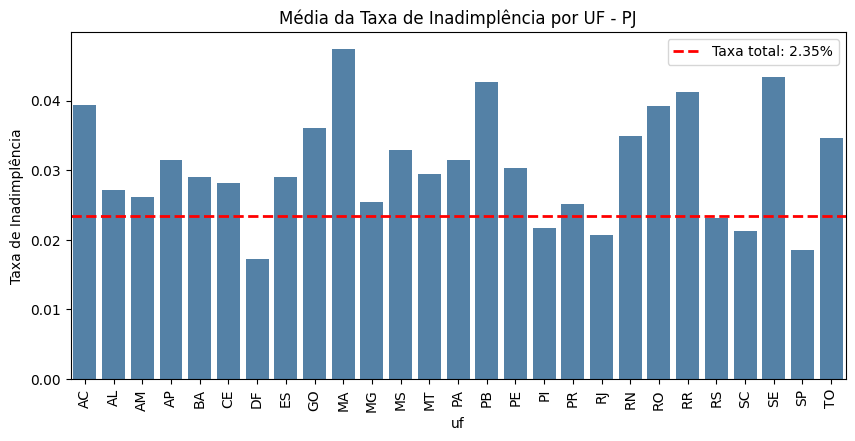

In [ ]:
# Calculo a taxa de inadimplência por UF e por data_base
df_cubo_scr = df_scr\
                .groupby(['uf', 'data_base'])\
                .agg(
                    cart_ativ =  ('carteira_ativa', lambda x: x.sum()/10**9),
                    cart_inad =  ('carteira_inadimplencia', lambda x: x.sum()/10**9)
                ).reset_index()

df_cubo_scr['data_base'] = df_cubo_scr['data_base'].astype(str).str[:7]
df_cubo_scr['txa_inad'] = df_cubo_scr['cart_inad']/df_cubo_scr['cart_ativ']
df_cubo_scr = df_cubo_scr\
                .groupby('uf')\
                .agg(
                    txa_inad = ('txa_inad', 'mean')
                ).reset_index()

df_cubo_scr2 = df_scr\
                    .groupby(['data_base'])\
                    .agg(
                        cart_ativ =  ('carteira_ativa', lambda x: x.sum()/10**9),
                        cart_inad =  ('carteira_inadimplencia', lambda x: x.sum()/10**9)
                    ).reset_index()
df_cubo_scr2['txa_inad'] = df_cubo_scr2['cart_inad']/df_cubo_scr2['cart_ativ']
txa_inad_total = df_cubo_scr2['txa_inad'].mean()

plt.figure(figsize = (10, 4.5))
sns.barplot(data = df_cubo_scr,
            x = 'uf',
            y = 'txa_inad',
            color = 'steelblue')

plt.axhline(y = txa_inad_total,
            color = 'red',
            linestyle = '--',
            linewidth = 2,
            label = f'Taxa total: {txa_inad_total:.2%}')

plt.xticks(rotation=90)
plt.title('Média da Taxa de Inadimplência por UF - PJ')
plt.ylabel('Taxa de Inadimplência')
plt.legend()
plt.show()

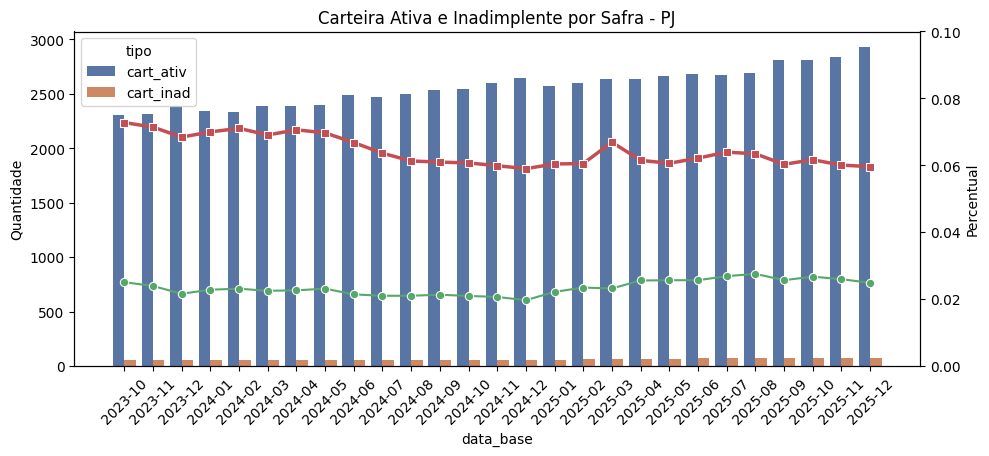

In [ ]:
df_cubo_scr = df_scr\
                .groupby(['data_base'])\
                .agg(
                    qtd_ope =    ('numero_de_operacoes', lambda x: x.sum()/10**3),
                    cart_ativ = ('carteira_ativa', lambda x: x.sum()/10**9),
                    cart_inad =  ('carteira_inadimplencia', lambda x: x.sum()/10**9),
                    ativ_prob =  ('ativo_problematico', lambda x: x.sum()/10**9)
                ).reset_index()

df_cubo_scr['data_base'] = df_cubo_scr['data_base'].astype(str).str[:7]
df_cubo_scr['txa_inad'] = df_cubo_scr['cart_inad']/df_cubo_scr['cart_ativ']
df_cubo_scr['txa_prob'] = df_cubo_scr['ativ_prob']/df_cubo_scr['cart_ativ']

# Gráfico com Clientes e cancelamentos por safra
fig, ax1 = plt.subplots(figsize = (10, 4.5))

# Plot de barras
sns.barplot(df_cubo_scr.melt(id_vars = 'data_base',
                            value_vars = ['cart_ativ', 'cart_inad'],
                            var_name = 'tipo',
                            value_name = 'value'),
            x = 'data_base',
            y = 'value',
            hue = 'tipo',
            palette = 'deep',
            ax = ax1)

# Plot de linha
ax2 = ax1.twinx()
sns.lineplot(data = df_cubo_scr,
            x = 'data_base',
            y = 'txa_inad',
            marker = 'o',
            color = '#55A868',
            legend = False,
            ax = ax2)

sns.lineplot(
    data=df_cubo_scr,
    x='data_base',
    y='txa_prob',
    marker='s',
    linewidth=2.5,
    color='#C44E52',   # Vermelho
    ax = ax2
)

# Configura subplots
ax1.tick_params(axis='x', rotation=45)
ax1.set_ylabel('Quantidade')

ax2.set_ylabel('Percentual')
ax2.set_ylim(0, 0.1)

ax1.grid(False)
ax2.grid(False)

plt.tight_layout()
plt.title('Carteira Ativa e Inadimplente por Safra - PJ')
plt.show()
# del df_cubo_scr

## 2.2. BACEN

### 2.2.2. Taxa SELIC

In [ ]:
df_selic.head()

,txa_selic,anomes
0,4.4000,202001
1,4.4000,202002
2,4.1500,202003
3,3.6500,202004
4,3.6500,202005


In [ ]:
df_selic = df_selic.drop_duplicates()

In [ ]:
df_selic_m1 = df_selic.rename(columns = {
    'anomes': 'anomes_m1',
    'txa_selic': 'txa_selic_m1'
})

df_selic_m3 = df_selic.rename(columns = {
    'anomes': 'anomes_m3',
    'txa_selic': 'txa_selic_m3'
})

df_selic_m6 = df_selic.rename(columns = {
    'anomes': 'anomes_m6',
    'txa_selic': 'txa_selic_m6'
})

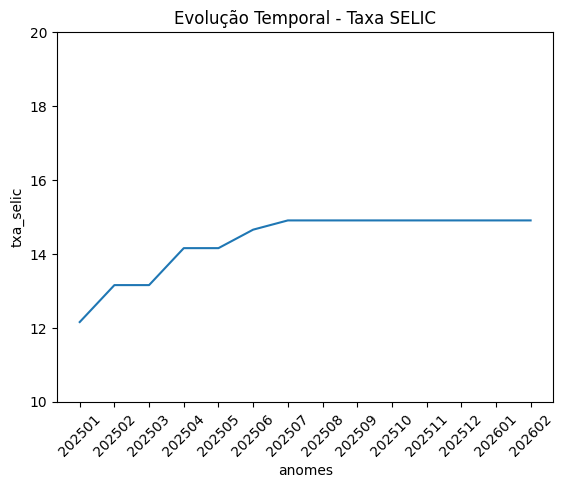

In [ ]:
sns.lineplot(data = df_selic[(df_selic['anomes'] >= '202501') &
                             (df_selic['anomes'] <= '202602')],
             x = 'anomes',
             y = 'txa_selic')
plt.title('Evolução Temporal - Taxa SELIC')
plt.ylim(10, 20)
plt.xticks(rotation = 45)
plt.show()

In [ ]:
df_selic['anomes'] = df_selic['anomes'].astype('category')
df_selic_m1['anomes_m1'] = df_selic_m1['anomes_m1'].astype('category')
df_selic_m3['anomes_m3'] = df_selic_m3['anomes_m3'].astype('category')
df_selic_m6['anomes_m6'] = df_selic_m6['anomes_m6'].astype('category')

## 2.3. IBGE

### 2.3.2. INPC

In [ ]:
df_inpc.head()

,cod_nivel_terri,nivel_terri,cod_unidade_medida,unidade_medida,vl_inpc,cod_brasil,brasil,cod_variavel,variavel,anomes,mes,txa_inpc_mensal,txa_inpc_acum_12m
0,NaN,NaN,2,NaN,2741.4500,NaN,NaN,2292,INPC - Variação acumulada em 12 meses,199401,JAN,0.0000,2741.4500
1,NaN,NaN,2,NaN,41.3200,NaN,NaN,44,INPC - Variação mensal,199401,JAN,41.3200,0.0000
2,NaN,NaN,2,NaN,3100.7000,NaN,NaN,2292,INPC - Variação acumulada em 12 meses,199402,FEV,0.0000,3100.7000
3,NaN,NaN,2,NaN,40.5700,NaN,NaN,44,INPC - Variação mensal,199402,FEV,40.5700,0.0000
4,NaN,NaN,2,NaN,3489.5800,NaN,NaN,2292,INPC - Variação acumulada em 12 meses,199403,MAR,0.0000,3489.5800


In [ ]:
df_inpc.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 784 entries, 0 to 783
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   cod_nivel_terri     0 non-null      float64
 1   nivel_terri         0 non-null      float64
 2   cod_unidade_medida  784 non-null    object 
 3   unidade_medida      0 non-null      float64
 4   vl_inpc             784 non-null    float64
 5   cod_brasil          0 non-null      float64
 6   brasil              0 non-null      float64
 7   cod_variavel        784 non-null    object 
 8   variavel            784 non-null    object 
 9   anomes              784 non-null    object 
 10  mes                 784 non-null    object 
 11  txa_inpc_mensal     784 non-null    float64
 12  txa_inpc_acum_12m   784 non-null    float64
dtypes: float64(8), object(5)
memory usage: 79.8+ KB


In [ ]:
df_inpc['vl_inpc'] = pd.to_numeric(df_inpc['vl_inpc'], errors = 'coerce').astype('float64')

In [ ]:
count_unique(df_inpc)

Contando distintos...
Distintos na feature cod_nivel_terri: 0
Distintos na feature nivel_terri: 0
Distintos na feature cod_unidade_medida: 1
Distintos na feature unidade_medida: 0
Distintos na feature vl_inpc: 501
Distintos na feature cod_brasil: 0
Distintos na feature brasil: 0
Distintos na feature cod_variavel: 2
Distintos na feature variavel: 2
Distintos na feature anomes: 392
Distintos na feature mes: 12
Distintos na feature txa_inpc_mensal: 164
Distintos na feature txa_inpc_acum_12m: 340


In [ ]:
cols = df_inpc.columns

for c in cols:
    print(f'Dominio feature {c}: {df_inpc[c].unique()[:10]}')
    print('\n')

Dominio feature cod_nivel_terri: [nan]


Dominio feature nivel_terri: [nan]


Dominio feature cod_unidade_medida: ['2']


Dominio feature unidade_medida: [nan]


Dominio feature vl_inpc: [2741.45   41.32 3100.7    40.57 3489.58   43.08 3894.75   42.86 4397.36
   42.73]


Dominio feature cod_brasil: [nan]


Dominio feature brasil: [nan]


Dominio feature cod_variavel: ['2292' '44']


Dominio feature variavel: ['INPC - Variação acumulada em 12 meses' 'INPC - Variação mensal']


Dominio feature anomes: ['199401' '199402' '199403' '199404' '199405' '199406' '199407' '199408'
 '199409' '199410']


Dominio feature mes: ['JAN' 'FEV' 'MAR' 'ABR' 'MAI' 'JUN' 'JUL' 'AGO' 'SET' 'OUT']


Dominio feature txa_inpc_mensal: [ 0.   41.32 40.57 43.08 42.86 42.73 48.24  7.75  1.85  1.4 ]


Dominio feature txa_inpc_acum_12m: [2741.45    0.   3100.7  3489.58 3894.75 4397.36 5013.82 4105.88 3112.62
 2301.83]




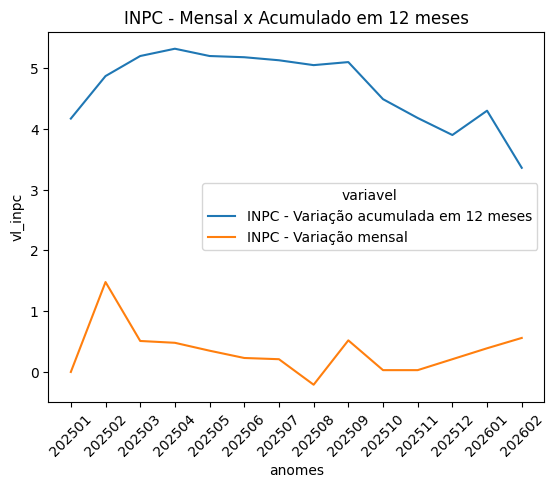

In [ ]:
sns.lineplot(data = df_inpc[(df_inpc['anomes'] >= '202501') &
                            (df_inpc['anomes'] <= '202602') &
                            (df_inpc['cod_unidade_medida'] == '2') &
                            (df_inpc['cod_variavel'].isin(['44', '2292']))],
            x = 'anomes',
            y = 'vl_inpc',
            hue = 'variavel')
plt.xticks(rotation = 45)
plt.title('INPC - Mensal x Acumulado em 12 meses')
plt.show()

In [ ]:
df_inpc['txa_inpc_mensal'] = np.where(df_inpc['cod_variavel'] == '44', df_inpc['vl_inpc'], 0)
df_inpc['txa_inpc_acum_12m'] = np.where(df_inpc['cod_variavel'] == '2292', df_inpc['vl_inpc'], 0)

In [ ]:
df_inpc2 = df_inpc\
            .groupby('anomes')\
            .agg(
                txa_inpc_mensal = ('txa_inpc_mensal', 'max'),
                txa_inpc_acum_12m = ('txa_inpc_acum_12m', 'max')
            ).reset_index()

df_inpc_m1 = df_inpc2.rename(columns = {
    'anomes': 'anomes_m1',
    'txa_inpc_mensal': 'txa_inpc_mensal_m1'
}).drop(columns = ['txa_inpc_acum_12m'])

df_inpc_m3 = df_inpc2.rename(columns = {
    'anomes': 'anomes_m3',
    'txa_inpc_mensal': 'txa_inpc_mensal_m3'
}).drop(columns = ['txa_inpc_acum_12m'])

df_inpc_m6 = df_inpc2.rename(columns = {
    'anomes': 'anomes_m6',
    'txa_inpc_mensal': 'txa_inpc_mensal_m6'
}).drop(columns = ['txa_inpc_acum_12m'])


df_inpc2['anomes'] = df_inpc2['anomes'].astype('category')
df_inpc_m1['anomes_m1'] = df_inpc_m1['anomes_m1'].astype('category')
df_inpc_m3['anomes_m3'] = df_inpc_m3['anomes_m3'].astype('category')
df_inpc_m6['anomes_m6'] = df_inpc_m6['anomes_m6'].astype('category')

# 3. Construção da Master

In [ ]:
df_master = df_scr\
            .merge(df_selic,
                on = 'anomes',
                how = 'left')\
            .merge(df_selic_m1,
                on = 'anomes_m1',
                how = 'left')\
            .merge(df_selic_m3,
                on = 'anomes_m3',
                how = 'left')\
            .merge(df_selic_m6,
                on = 'anomes_m6',
                how = 'left')\
            .merge(df_inpc2,
                on = 'anomes',
                how = 'left')\
            .merge(df_inpc_m1,
                on = 'anomes_m1',
                how = 'left')\
            .merge(df_inpc_m3,
                on = 'anomes_m3',
                how = 'left')\
            .merge(df_inpc_m6,
                on = 'anomes_m6',
                how = 'left')

In [ ]:
df_master_orig = df_master.copy()

In [ ]:
df_master.head()

,data_base,anomes,anomes_m1,anomes_m3,anomes_m6,uf,segmento,porte,modalidade,numero_de_operacoes,a_vencer_ate_90_dias,a_vencer_de_91_ate_360_dias,a_vencer_de_361_ate_1080_dias,a_vencer_de_1081_ate_1800_dias,a_vencer_de_1801_ate_5400_dias,a_vencer_acima_de_5400_dias,carteira_a_vencer,vencido_de_15_ate_90_dias,vencido_acima_de_90_dias,carteira_vencida,carteira_ativa,carteira_inadimplencia,ativo_problematico,txa_selic,txa_selic_m1,txa_selic_m3,txa_selic_m6,txa_inpc_mensal,txa_inpc_acum_12m,txa_inpc_mensal_m1,txa_inpc_mensal_m3,txa_inpc_mensal_m6
0,2023-10-31,202310,202309,202307,202304,AC,Arrendamento,Médio,Operações de arrendamento,-1.0000,193583.2500,504705.0400,1186770.3900,429065.7100,0.0000,0.0000,2314124.3900,0.0000,0.0000,0.0000,2314124.3900,0.0000,0.0000,12.6500,13.1500,13.6500,13.6500,0.1200,4.1400,0.1100,0.0000,0.5300
1,2023-10-31,202310,202309,202307,202304,AC,Banco,Grande,Adiantamentos a depositantes,-1.0000,69.1400,0.0000,0.0000,0.0000,0.0000,0.0000,69.1400,0.0000,0.0000,0.0000,69.1400,0.0000,0.0000,12.6500,13.1500,13.6500,13.6500,0.1200,4.1400,0.1100,0.0000,0.5300
2,2023-10-31,202310,202309,202307,202304,AC,Banco,Grande,Empréstimos,-9.0000,12429622.4800,8605920.2700,108292603.1000,7902576.3200,6558993.0400,0.0000,143789715.2100,0.0000,0.0000,0.0000,143789715.2100,0.0000,0.0000,12.6500,13.1500,13.6500,13.6500,0.1200,4.1400,0.1100,0.0000,0.5300
3,2023-10-31,202310,202309,202307,202304,AC,Banco,Grande,Financiamentos,9.0000,12428014.0400,46051779.5800,73449111.5200,57579088.1800,171213267.5400,132506690.1000,493227950.9600,0.0000,0.0000,0.0000,493227950.9600,0.0000,0.0000,12.6500,13.1500,13.6500,13.6500,0.1200,4.1400,0.1100,0.0000,0.5300
4,2023-10-31,202310,202309,202307,202304,AC,Banco,Grande,Financiamentos de infraestrutura e desenvolvim...,-3.0000,17360359.4300,49880858.9400,123571645.0100,111684758.5900,180599213.4700,0.0000,483096835.4400,0.0000,0.0000,0.0000,483096835.4400,0.0000,0.0000,12.6500,13.1500,13.6500,13.6500,0.1200,4.1400,0.1100,0.0000,0.5300


### 3.1. Feature Engineering

In [ ]:
def _div_segura(numerador, denominador):
    """Divisão segura: evita inf/NaN quando o denominador é 0."""
    return np.where(denominador == 0, 0, numerador / np.where(denominador == 0, 1, denominador))

# ticket_medio: Volume médio por operação
## Se numero_operacoes = 0, vamos considerar 1
df_master['ticket_medio'] = _div_segura(df_master['carteira_ativa'], np.where(df_master['numero_de_operacoes'] < 0, 1, df_master['numero_de_operacoes']))

# Construção features de percentual a vencer por faixa em curto e longo prazo
df_master['perc_a_vencer_curto_prazo']    = _div_segura(df_master['a_vencer_ate_90_dias'] + df_master['a_vencer_de_91_ate_360_dias'],
                                                        df_master['carteira_ativa'])
df_master['perc_a_vencer_longo_prazo']    = _div_segura(df_master['a_vencer_de_361_ate_1080_dias'] + df_master['a_vencer_de_1081_ate_1800_dias'] + df_master['a_vencer_de_1801_ate_5400_dias'] + df_master['a_vencer_acima_de_5400_dias'],
                                                        df_master['carteira_ativa'])
df_master['perc_a_vencer_ate90']          = _div_segura(df_master['a_vencer_ate_90_dias'],
                                                        df_master['carteira_ativa'])
df_master['perc_a_vencer_91_360']         = _div_segura(df_master['a_vencer_de_91_ate_360_dias'],
                                                        df_master['carteira_ativa'])
df_master['perc_a_vencer_361_1080']       = _div_segura(df_master['a_vencer_de_361_ate_1080_dias'],
                                                        df_master['carteira_ativa'])
df_master['perc_a_vencer_1081_1800']      = _div_segura(df_master['a_vencer_de_1081_ate_1800_dias'],
                                                        df_master['carteira_ativa'])
df_master['perc_a_vencer_1801_5400']      = _div_segura(df_master['a_vencer_de_1801_ate_5400_dias'],
                                                        df_master['carteira_ativa'])
df_master['perc_a_vencer_acima_5400']     = _div_segura(df_master['a_vencer_acima_de_5400_dias'],
                                                        df_master['carteira_ativa'])
df_master['perc_carteira_vencida']        = _div_segura(df_master['carteira_vencida'],
                                                        df_master['carteira_ativa'])
df_master['perc_vencido_15_90']           = _div_segura(df_master['vencido_de_15_ate_90_dias'],
                                                        df_master['carteira_ativa'])
df_master['perc_vencido_90']              = _div_segura(df_master['vencido_acima_de_90_dias'],
                                                        df_master['carteira_ativa'])
df_master['perc_ativo_problematico']      = _div_segura(df_master['ativo_problematico'],
                                                        df_master['carteira_ativa'])
df_master['perc_vencido90_sobre_vencida'] = _div_segura(df_master['vencido_acima_de_90_dias'],
                                                        df_master['carteira_vencida'])
df_master['perc_inad_sobre_vencida']      = _div_segura(df_master['carteira_inadimplencia'],
                                                        df_master['carteira_vencida'])

In [ ]:
chaves_grupo = ['uf', 'segmento', 'porte', 'modalidade']
HORIZONTES = list(range(1, 13))  # h = 1 a 12 meses

df_master['txa_inad_atual'] = df_master['carteira_inadimplencia'] / df_master['carteira_ativa']

df_master = df_master.sort_values(chaves_grupo + ['anomes']).reset_index(drop=True)

lista_stack = []
for h in HORIZONTES:
    df_h = df_master.copy()
    df_h['txa_inad'] = df_h.groupby(chaves_grupo)['txa_inad_atual'].shift(-h)
    df_h['horizonte'] = h
    lista_stack.append(df_h)

df_master = pd.concat(lista_stack, ignore_index=True)
# Linhas sem target (últimos HORIZONTE meses de cada grupo) são removidas
qtd_antes = len(df_master)
df_master = df_master.dropna(subset=['txa_inad']).reset_index(drop=True)
qtd_depois = len(df_master)

print(f'Linhas removidas (sem target futura): {qtd_antes - qtd_depois:,}')
print(f'Linhas restantes: {qtd_depois:,}')

Linhas removidas (sem target futura): 299,811
Linhas restantes: 829,833


In [ ]:
df_master[(df_master['uf'] == 'SP') &
          (df_master['porte'] == 'Grande') &
          (df_master['segmento'] == 'Fintech') &
          (df_master['anomes'] == '202401') &
          (df_master['modalidade'] == 'Empréstimos')]

,data_base,anomes,anomes_m1,anomes_m3,anomes_m6,uf,segmento,porte,modalidade,numero_de_operacoes,a_vencer_ate_90_dias,a_vencer_de_91_ate_360_dias,a_vencer_de_361_ate_1080_dias,a_vencer_de_1081_ate_1800_dias,a_vencer_de_1801_ate_5400_dias,a_vencer_acima_de_5400_dias,carteira_a_vencer,vencido_de_15_ate_90_dias,vencido_acima_de_90_dias,carteira_vencida,carteira_ativa,carteira_inadimplencia,ativo_problematico,txa_selic,txa_selic_m1,txa_selic_m3,txa_selic_m6,txa_inpc_mensal,txa_inpc_acum_12m,txa_inpc_mensal_m1,txa_inpc_mensal_m3,txa_inpc_mensal_m6,ticket_medio,perc_a_vencer_curto_prazo,perc_a_vencer_longo_prazo,perc_a_vencer_ate90,perc_a_vencer_91_360,perc_a_vencer_361_1080,perc_a_vencer_1081_1800,perc_a_vencer_1801_5400,perc_a_vencer_acima_5400,perc_carteira_vencida,perc_vencido_15_90,perc_vencido_90,perc_ativo_problematico,perc_vencido90_sobre_vencida,perc_inad_sobre_vencida,txa_inad_atual,txa_inad,horizonte
85974,2024-01-31,202401,202312,202310,202307,SP,Fintech,Grande,Empréstimos,-3.0000,27944805.8100,2129.4200,0.0000,0.0000,0.0000,0.0000,27946935.2300,0.0000,475895.2300,475895.2300,28422830.4600,475895.2300,475895.2300,11.6500,12.1500,12.6500,13.6500,0.5700,3.8200,0.5500,0.1200,0.0000,28422830.4600,0.9833,0.0000,0.9832,0.0001,0.0000,0.0000,0.0000,0.0000,0.0167,0.0000,0.0167,0.0167,1.0000,1.0000,0.0167,0.0171,1
172298,2024-01-31,202401,202312,202310,202307,SP,Fintech,Grande,Empréstimos,-3.0000,27944805.8100,2129.4200,0.0000,0.0000,0.0000,0.0000,27946935.2300,0.0000,475895.2300,475895.2300,28422830.4600,475895.2300,475895.2300,11.6500,12.1500,12.6500,13.6500,0.5700,3.8200,0.5500,0.1200,0.0000,28422830.4600,0.9833,0.0000,0.9832,0.0001,0.0000,0.0000,0.0000,0.0000,0.0167,0.0000,0.0167,0.0167,1.0000,1.0000,0.0167,0.0000,2
254715,2024-01-31,202401,202312,202310,202307,SP,Fintech,Grande,Empréstimos,-3.0000,27944805.8100,2129.4200,0.0000,0.0000,0.0000,0.0000,27946935.2300,0.0000,475895.2300,475895.2300,28422830.4600,475895.2300,475895.2300,11.6500,12.1500,12.6500,13.6500,0.5700,3.8200,0.5500,0.1200,0.0000,28422830.4600,0.9833,0.0000,0.9832,0.0001,0.0000,0.0000,0.0000,0.0000,0.0167,0.0000,0.0167,0.0167,1.0000,1.0000,0.0167,0.0000,3
333279,2024-01-31,202401,202312,202310,202307,SP,Fintech,Grande,Empréstimos,-3.0000,27944805.8100,2129.4200,0.0000,0.0000,0.0000,0.0000,27946935.2300,0.0000,475895.2300,475895.2300,28422830.4600,475895.2300,475895.2300,11.6500,12.1500,12.6500,13.6500,0.5700,3.8200,0.5500,0.1200,0.0000,28422830.4600,0.9833,0.0000,0.9832,0.0001,0.0000,0.0000,0.0000,0.0000,0.0167,0.0000,0.0167,0.0167,1.0000,1.0000,0.0167,0.0000,4
408026,2024-01-31,202401,202312,202310,202307,SP,Fintech,Grande,Empréstimos,-3.0000,27944805.8100,2129.4200,0.0000,0.0000,0.0000,0.0000,27946935.2300,0.0000,475895.2300,475895.2300,28422830.4600,475895.2300,475895.2300,11.6500,12.1500,12.6500,13.6500,0.5700,3.8200,0.5500,0.1200,0.0000,28422830.4600,0.9833,0.0000,0.9832,0.0001,0.0000,0.0000,0.0000,0.0000,0.0167,0.0000,0.0167,0.0167,1.0000,1.0000,0.0167,0.0000,5
478988,2024-01-31,202401,202312,202310,202307,SP,Fintech,Grande,Empréstimos,-3.0000,27944805.8100,2129.4200,0.0000,0.0000,0.0000,0.0000,27946935.2300,0.0000,475895.2300,475895.2300,28422830.4600,475895.2300,475895.2300,11.6500,12.1500,12.6500,13.6500,0.5700,3.8200,0.5500,0.1200,0.0000,28422830.4600,0.9833,0.0000,0.9832,0.0001,0.0000,0.0000,0.0000,0.0000,0.0167,0.0000,0.0167,0.0167,1.0000,1.0000,0.0167,0.0000,6
546203,2024-01-31,202401,202312,202310,202307,SP,Fintech,Grande,Empréstimos,-3.0000,27944805.8100,2129.4200,0.0000,0.0000,0.0000,0.0000,27946935.2300,0.0000,475895.2300,475895.2300,28422830.4600,475895.2300,475895.2300,11.6500,12.1500,12.6500,13.6500,0.5700,3.8200,0.5500,0.1200,0.0000,28422830.4600,0.9833,0.0000,0.9832,0.0001,0.0000,0.0000,0.0000,0.0000,0.0167,0.0000,0.0167,0.0167,1.0000,1.0000,0.0167,0.0000,7
609704,2024-01-31,202401,202312,202310,202307,SP,Fintech,Grande,Empréstimos,-3.0000,27944805.8100,2129.4200,0.0000,0.0000,0.0000,0.0000,27946935.2300,0.0000,475895.2300,475895.2300,284

### 3.2. Target

In [ ]:
df_master['txa_inad'].describe().T

,txa_inad
count,829833.0000
mean,0.0939
std,0.2060
min,0.0000
25%,0.0000
50%,0.0062
75%,0.0670
max,1.0000


In [ ]:
# Analisando os extremos da target
print(f'Target = 0: {(df_master['txa_inad'] == 0).mean():.0%}')
print(f'Target = 1: {(df_master['txa_inad'] == 1).mean():.0%}')

Target = 0: 39%
Target = 1: 1%


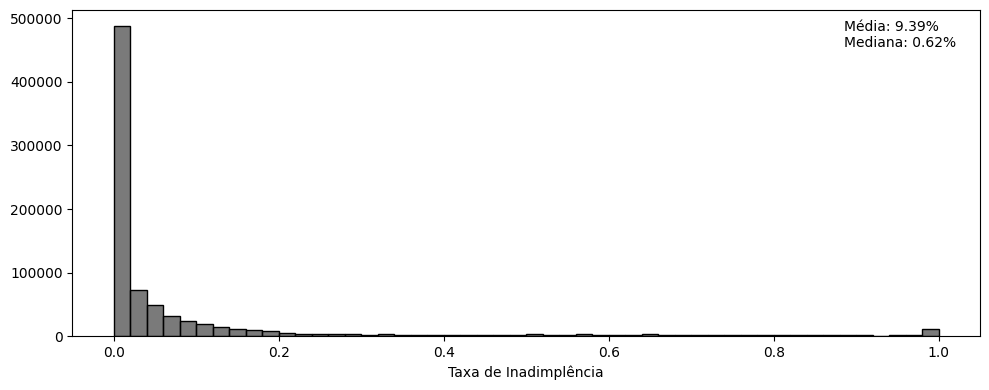

In [ ]:
media = np.mean(df_master['txa_inad'])
mediana = np.median(df_master['txa_inad'])

# Histograma
plt.figure(figsize=(10, 4))
sns.histplot(data = df_master['txa_inad'],
             bins = 50,
             color = '#4D4D4D')
plt.xlabel('Taxa de Inadimplência')
plt.ylabel('')

plt.text(
    0.85, 0.97,
    f'Média: {media:.2%}\n'
    f'Mediana: {mediana:.2%}\n',
    transform=plt.gca().transAxes,
    ha='left',
    va='top',
    fontsize=10
)

plt.savefig(
    '/content/drive/MyDrive/Estudos/USP/MBA/TCC/Projeto/output/Figures/hist_inad.pdf',
    bbox_inches='tight'
)

plt.tight_layout()
plt.show()

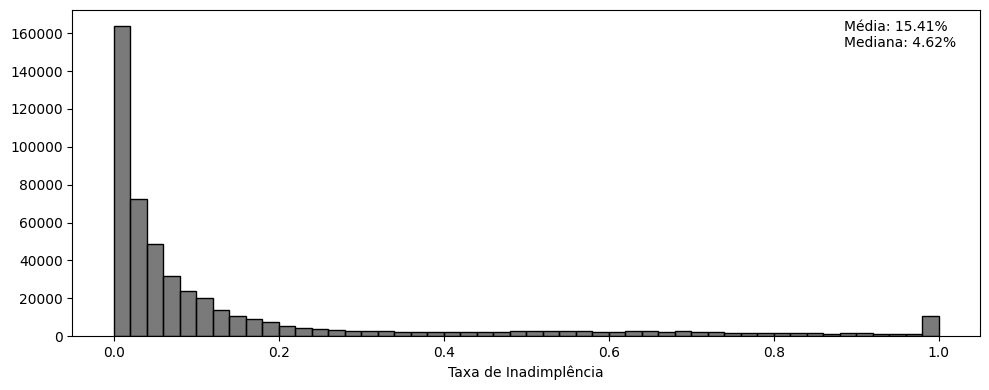

In [ ]:
media = np.mean(df_master[df_master['txa_inad'] > 0]['txa_inad'])
mediana = np.median(df_master[df_master['txa_inad'] > 0]['txa_inad'])

# Histograma
plt.figure(figsize=(10, 4))
sns.histplot(data = df_master[df_master['txa_inad'] > 0]['txa_inad'],
             bins = 50,
             color = '#4D4D4D')
plt.xlabel('Taxa de Inadimplência')
plt.ylabel('')

plt.text(
    0.85, 0.97,
    f'Média: {media:.2%}\n'
    f'Mediana: {mediana:.2%}\n',
    transform=plt.gca().transAxes,
    ha='left',
    va='top',
    fontsize=10
)

plt.savefig(
    '/content/drive/MyDrive/Estudos/USP/MBA/TCC/Projeto/output/Figures/hist_inad_sem_zeros.pdf',
    bbox_inches='tight'
)

plt.tight_layout()
plt.show()

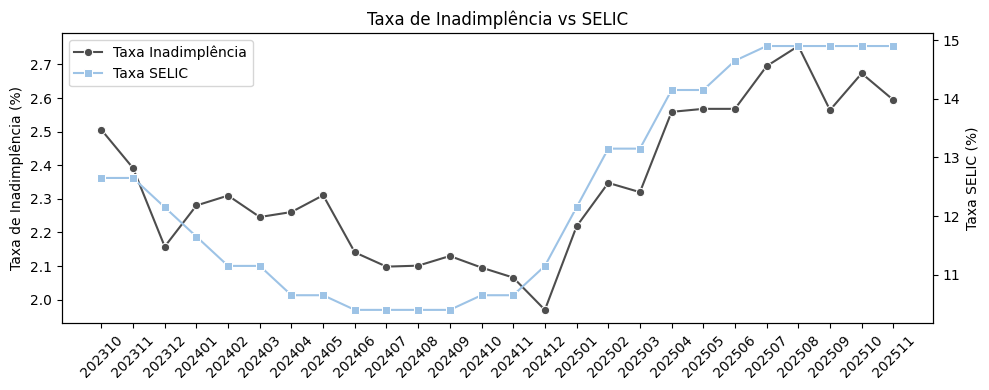

In [ ]:
cubo_master = df_master\
    .groupby(['anomes'])\
    .agg(
        cart_ativ = ('carteira_ativa', lambda x: x.sum()/10**9),
        cart_inad =  ('carteira_inadimplencia', lambda x: x.sum()/10**9),
        txa_selic = ('txa_selic', 'max'),
        txa_inpc_acum_12m = ('txa_inpc_acum_12m', 'max')
    ).reset_index()

cubo_master['txa_inad'] = 100*cubo_master['cart_inad']/cubo_master['cart_ativ']
fig, ax1 = plt.subplots(figsize=(10, 4))

# Eixo esquerdo - Inadimplência
sns.lineplot(
    data = cubo_master,
    x = 'anomes',
    y = 'txa_inad',
    label = 'Taxa Inadimplência',
    color = '#4D4D4D',
    marker = 'o',
    ax = ax1
)

# Eixo direito - SELIC
ax2 = ax1.twinx()

sns.lineplot(
    data = cubo_master,
    x = 'anomes',
    y = 'txa_selic',
    label = 'Taxa SELIC',
    color = '#9DC3E6',  # azul suave
    marker = 's',
    ax = ax2
)

# Junta as legendas
handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()

ax1.legend(
    handles1 + handles2,
    labels1 + labels2,
    loc='upper left'
)

ax2.get_legend().remove()

ax1.set_xlabel('')
ax1.set_ylabel('Taxa de Inadimplência (%)')
ax2.set_ylabel('Taxa SELIC (%)')

ax1.tick_params(axis='x', labelrotation=45)

plt.title('Taxa de Inadimplência vs SELIC')
plt.tight_layout()

plt.savefig(
    '/content/drive/MyDrive/Estudos/USP/MBA/TCC/Projeto/output/Figures/selic_vs_inad.pdf',
    bbox_inches='tight'
)

plt.show()

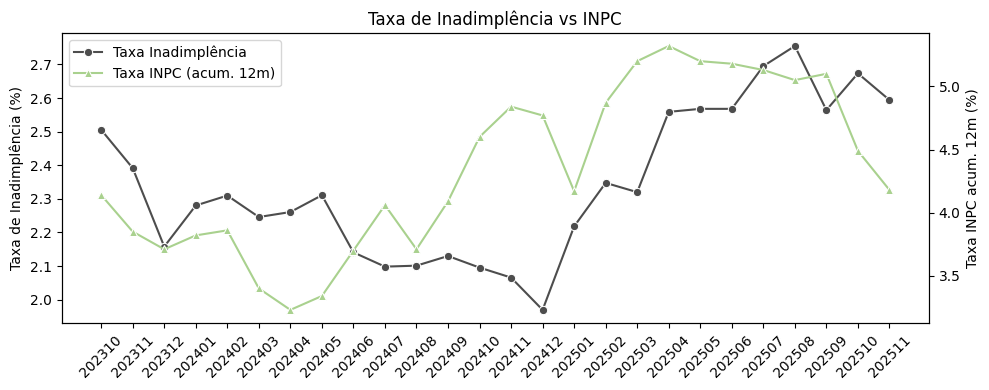

In [ ]:
fig, ax1 = plt.subplots(figsize=(10, 4))

# Eixo esquerdo - Inadimplência
sns.lineplot(
    data = cubo_master,
    x = 'anomes',
    y = 'txa_inad',
    label = 'Taxa Inadimplência',
    color = '#4D4D4D',
    marker = 'o',
    ax = ax1
)

# Eixo direito - INPC
ax2 = ax1.twinx()

sns.lineplot(
    data = cubo_master,
    x = 'anomes',
    y = 'txa_inpc_acum_12m',
    label = 'Taxa INPC (acum. 12m)',
    color = '#A9D18E',  # verde suave
    marker = '^',
    ax = ax2
)

# Junta as legendas
handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()

ax1.legend(
    handles1 + handles2,
    labels1 + labels2,
    loc='upper left'
)

ax2.get_legend().remove()

ax1.set_xlabel('')
ax1.set_ylabel('Taxa de Inadimplência (%)')
ax2.set_ylabel('Taxa INPC acum. 12m (%)')

ax1.tick_params(axis='x', labelrotation=45)

plt.title('Taxa de Inadimplência vs INPC')
plt.tight_layout()

plt.savefig(
    '/content/drive/MyDrive/Estudos/USP/MBA/TCC/Projeto/output/Figures/inpc_vs_inad.pdf',
    bbox_inches='tight'
)

plt.show()

In [ ]:
drop_cols = ['data_base', 'anomes_m1', 'anomes_m3', 'anomes_m6']

df_master = df_master.drop(columns = drop_cols)

In [ ]:
df_master[df_master['txa_inad'] > 0.2].head()

,anomes,uf,segmento,porte,modalidade,numero_de_operacoes,a_vencer_ate_90_dias,a_vencer_de_91_ate_360_dias,a_vencer_de_361_ate_1080_dias,a_vencer_de_1081_ate_1800_dias,a_vencer_de_1801_ate_5400_dias,a_vencer_acima_de_5400_dias,carteira_a_vencer,vencido_de_15_ate_90_dias,vencido_acima_de_90_dias,carteira_vencida,carteira_ativa,carteira_inadimplencia,ativo_problematico,txa_selic,txa_selic_m1,txa_selic_m3,txa_selic_m6,txa_inpc_mensal,txa_inpc_acum_12m,txa_inpc_mensal_m1,txa_inpc_mensal_m3,txa_inpc_mensal_m6,ticket_medio,perc_a_vencer_curto_prazo,perc_a_vencer_longo_prazo,perc_a_vencer_ate90,perc_a_vencer_91_360,perc_a_vencer_361_1080,perc_a_vencer_1081_1800,perc_a_vencer_1801_5400,perc_a_vencer_acima_5400,perc_carteira_vencida,perc_vencido_15_90,perc_vencido_90,perc_ativo_problematico,perc_vencido90_sobre_vencida,perc_inad_sobre_vencida,txa_inad_atual,txa_inad,horizonte
219,202310,AC,Banco,Indisponível,Adiantamentos a depositantes,-4.0000,0.0000,0.0000,0.0000,0.0000,0.0000,3646.2000,3646.2000,0.0000,13129.2700,13129.2700,16775.4700,13129.2700,16775.4700,12.6500,13.1500,13.6500,13.6500,0.1200,4.1400,0.1100,0.0000,0.5300,16775.4700,0.0000,0.2174,0.0000,0.0000,0.0000,0.0000,0.0000,0.2174,0.7826,0.0000,0.7826,1.0000,1.0000,1.0000,0.7826,0.6529,1
220,202311,AC,Banco,Indisponível,Adiantamentos a depositantes,-4.0000,50.3500,0.0000,0.0000,0.0000,0.0000,1378.6500,1429.0000,5552.3200,13129.2700,18681.5900,20110.5900,13129.2700,14507.9200,12.6500,12.6500,13.6500,13.6500,0.1000,3.8500,0.1200,0.2000,0.3600,20110.5900,0.0025,0.0686,0.0025,0.0000,0.0000,0.0000,0.0000,0.0686,0.9289,0.2761,0.6529,0.7214,0.7028,0.7028,0.6529,0.2968,1
221,202312,AC,Banco,Indisponível,Adiantamentos a depositantes,-5.0000,11734.7200,0.0000,0.0000,0.0000,0.0000,1378.6500,13113.3700,6864.7500,8434.1500,15298.9000,28412.2700,8434.1500,9812.8000,12.1500,12.6500,13.1500,13.6500,0.5500,3.7100,0.1000,0.1100,0.0000,28412.2700,0.4130,0.0485,0.4130,0.0000,0.0000,0.0000,0.0000,0.0485,0.5385,0.2416,0.2968,0.3454,0.5513,0.5513,0.2968,0.2631,1
222,202401,AC,Banco,Indisponível,Adiantamentos a depositantes,-5.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1378.6500,1378.6500,22246.9800,8434.1500,30681.1300,32059.7800,8434.1500,9812.8000,11.6500,12.1500,12.6500,13.6500,0.5700,3.8200,0.5500,0.1200,0.0000,32059.7800,0.0000,0.0430,0.0000,0.0000,0.0000,0.0000,0.0000,0.0430,0.9570,0.6939,0.2631,0.3061,0.2749,0.2749,0.2631,0.4623,1
223,202402,AC,Banco,Indisponível,Adiantamentos a depositantes,-5.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1378.6500,1378.6500,16821.3000,15646.7900,32468.0900,33846.7400,15646.7900,17025.4400,11.1500,11.6500,12.6500,13.6500,0.8100,3.8600,0.5700,0.1000,0.2000,33846.7400,0.0000,0.0407,0.0000,0.0000,0.0000,0.0000,0.0000,0.0407,0.9593,0.4970,0.4623,0.5030,0.4819,0.4819,0.4623,0.9593,1


In [ ]:
df_master['anomes'] = df_master['anomes'].astype('category')

In [ ]:
df_master.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 829833 entries, 0 to 829832
Data columns (total 46 columns):
 #   Column                          Non-Null Count   Dtype   
---  ------                          --------------   -----   
 0   anomes                          829833 non-null  category
 1   uf                              829833 non-null  object  
 2   segmento                        829833 non-null  object  
 3   porte                           829833 non-null  object  
 4   modalidade                      829833 non-null  object  
 5   numero_de_operacoes             829833 non-null  float64 
 6   a_vencer_ate_90_dias            829833 non-null  float64 
 7   a_vencer_de_91_ate_360_dias     829833 non-null  float64 
 8   a_vencer_de_361_ate_1080_dias   829833 non-null  float64 
 9   a_vencer_de_1081_ate_1800_dias  829833 non-null  float64 
 10  a_vencer_de_1801_ate_5400_dias  829833 non-null  float64 
 11  a_vencer_acima_de_5400_dias     829833 non-null  float64 
 12  ca

In [ ]:
df_master.describe().T

,count,mean,std,min,25%,50%,75%,max
numero_de_operacoes,829833.0000,8223.4996,46961.0344,-36.0000,-1.0000,67.0000,1411.0000,1721693.0000
a_vencer_ate_90_dias,829833.0000,143068025.4394,1209752925.4938,0.0000,262972.2900,2682533.6300,25720446.0700,135437006126.0400
a_vencer_de_91_ate_360_dias,829833.0000,189824439.5946,1382049164.7970,0.0000,160246.1600,2914659.5100,34333390.8100,79195080786.6300
a_vencer_de_361_ate_1080_dias,829833.0000,205332902.5425,1221943039.0115,0.0000,2248.0600,1058265.5400,27871559.4500,38949511252.5800
a_vencer_de_1081_ate_1800_dias,829833.0000,82310178.3414,657288048.3319,0.0000,0.0000,78408.0200,7444417.6700,32503814291.3700
a_vencer_de_1801_ate_5400_dias,829833.0000,90859690.5321,1022918466.5948,0.0000,0.0000,0.0000,1312620.9900,40423495917.7500
a_vencer_acima_de_5400_dias,829833.0000,17991374.2474,297353911.2413,0.0000,0.0000,0.0000,498.9300,13726042557.8300
carteira_a_vencer,829833.0000,729386610.6974,4563768579.9066,0.0000,1045104.2900,12505232.9600,147212597.3400,185474557875.1400
vencido_de_15_ate_90_dias,829833.0000,3573325.2284,29961859.9046,0.0000,0.0000,20692.3700,435157.5000,1666401496.3500
vencido_acima_de_90_dias,829833.0000,6847424.6243,75608797.4457,0.0000,0.0000,21564.7300,745928.6900,7424808896.6000


### 3.3. Histplot

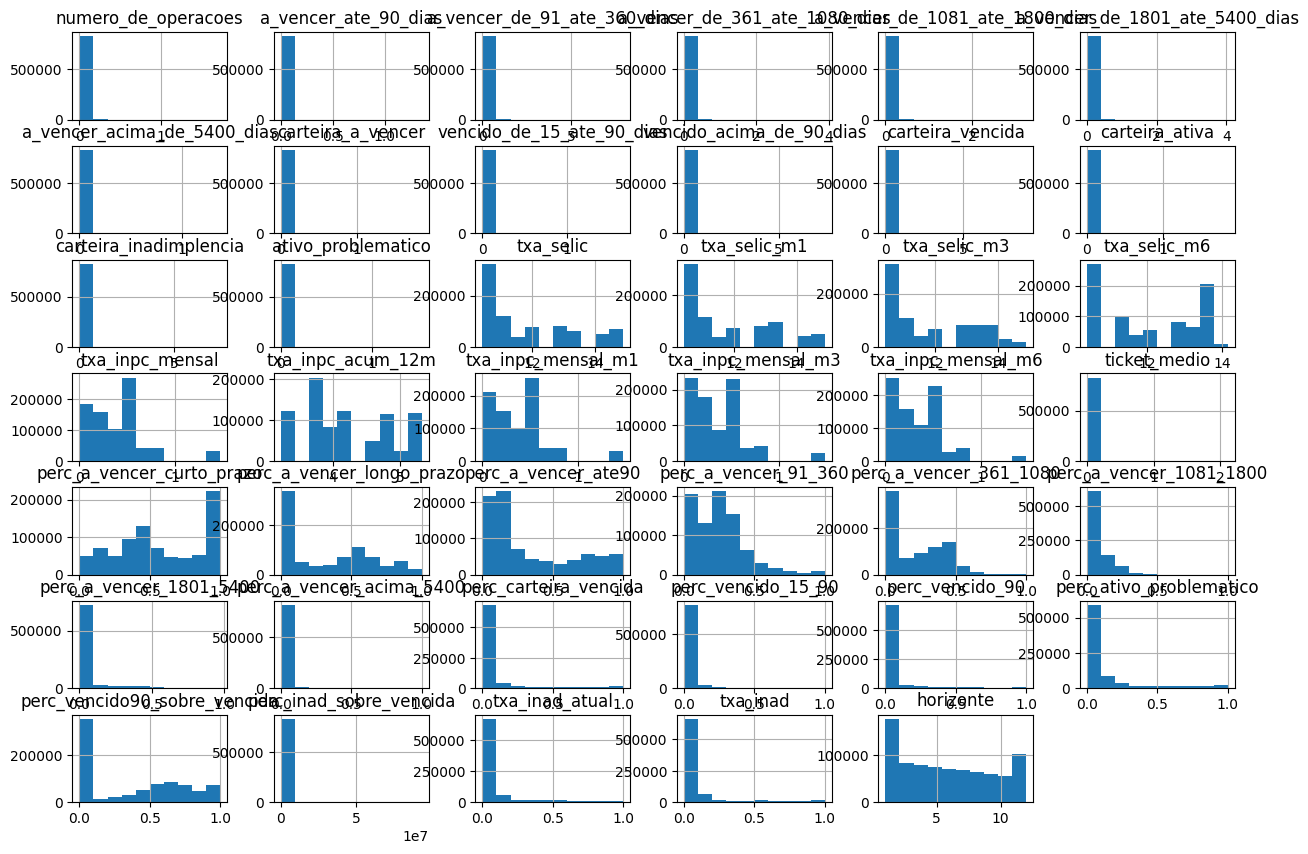

In [ ]:
df_master.hist(figsize = (15, 10))
plt.show()

In [ ]:
col_num = df_master.select_dtypes(include = 'number').columns

### 3.4. Correlações

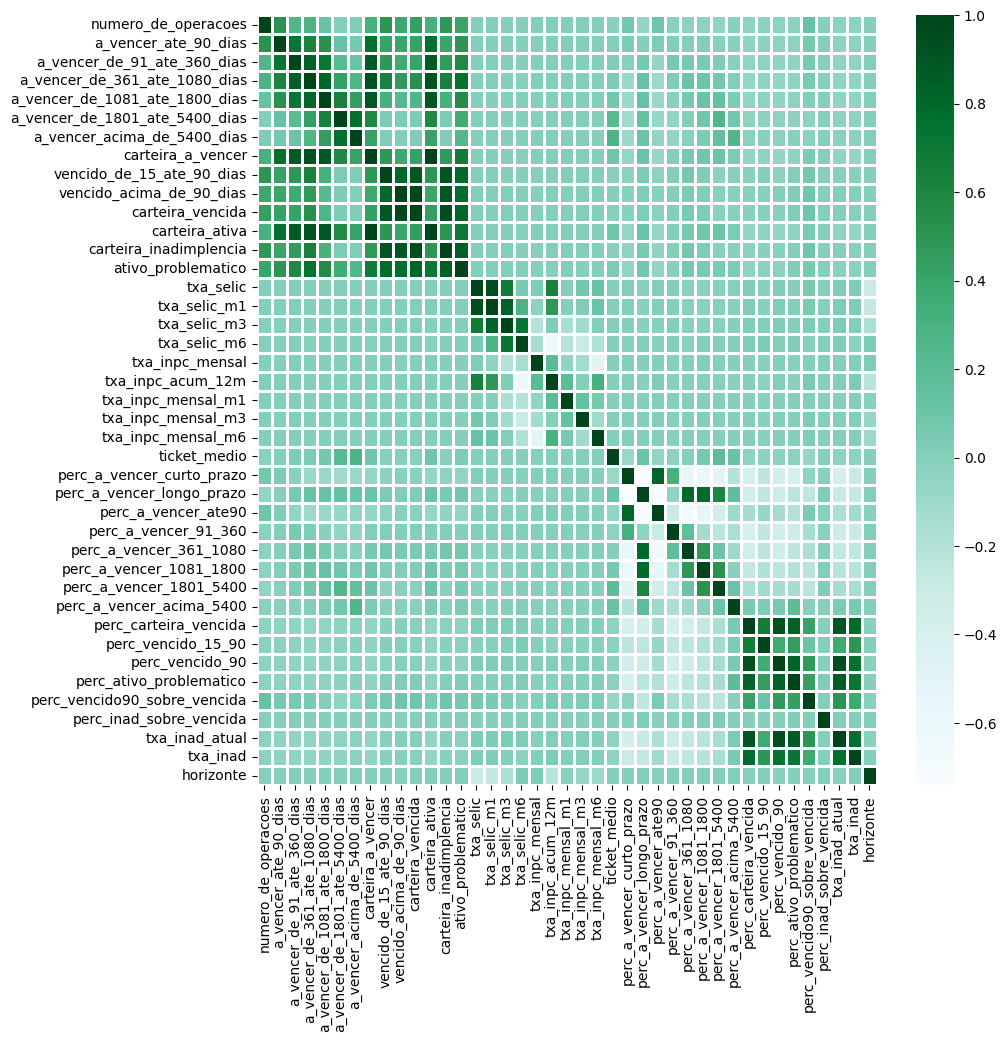

In [ ]:
# Perason
plt.figure(figsize = (10, 10))
corr = np.corrcoef
sns.heatmap(df_master[col_num].corr(),
            annot = False,
            fmt = '.1f',
            linewidths = 1,
            cmap = 'BuGn')
plt.xticks(rotation = 90)
plt.show()

In [ ]:
corr = df_master[col_num].corr(method='pearson')

# Mantém apenas o triângulo superior
upper = corr.where(
    np.triu(np.ones(corr.shape), k=1).astype(bool)
)

# Transforma em pares
corr_pairs = (
    upper.stack()
         .reset_index()
         .rename(columns={
             'level_0': 'Variavel_1',
             'level_1': 'Variavel_2',
             0: 'Correlacao'
         })
)

# Correlação absoluta
corr_pairs['Abs_Correlacao'] = corr_pairs['Correlacao'].abs()

# Ordena pela magnitude
corr_pairs = corr_pairs.sort_values(
    'Abs_Correlacao',
    ascending=False
).reset_index(drop=True)

corr_pairs[corr_pairs['Abs_Correlacao'] >= 0.8].head(20)

,Variavel_1,Variavel_2,Correlacao,Abs_Correlacao
0,carteira_a_vencer,carteira_ativa,0.9998,0.9998
1,vencido_acima_de_90_dias,carteira_vencida,0.9840,0.9840
2,perc_vencido_90,txa_inad_atual,0.9500,0.9500
3,txa_selic,txa_selic_m1,0.9492,0.9492
4,carteira_vencida,carteira_inadimplencia,0.9394,0.9394
5,perc_carteira_vencida,perc_vencido_90,0.9368,0.9368
6,a_vencer_de_361_ate_1080_dias,carteira_ativa,0.9223,0.9223
7,a_vencer_de_361_ate_1080_dias,carteira_a_vencer,0.9193,0.9193
8,vencido_de_15_ate_90_dias,carteira_inadimplencia,0.9099,0.9099
9,perc_carteira_vencida,txa_inad_atual,0.8982,0.8982


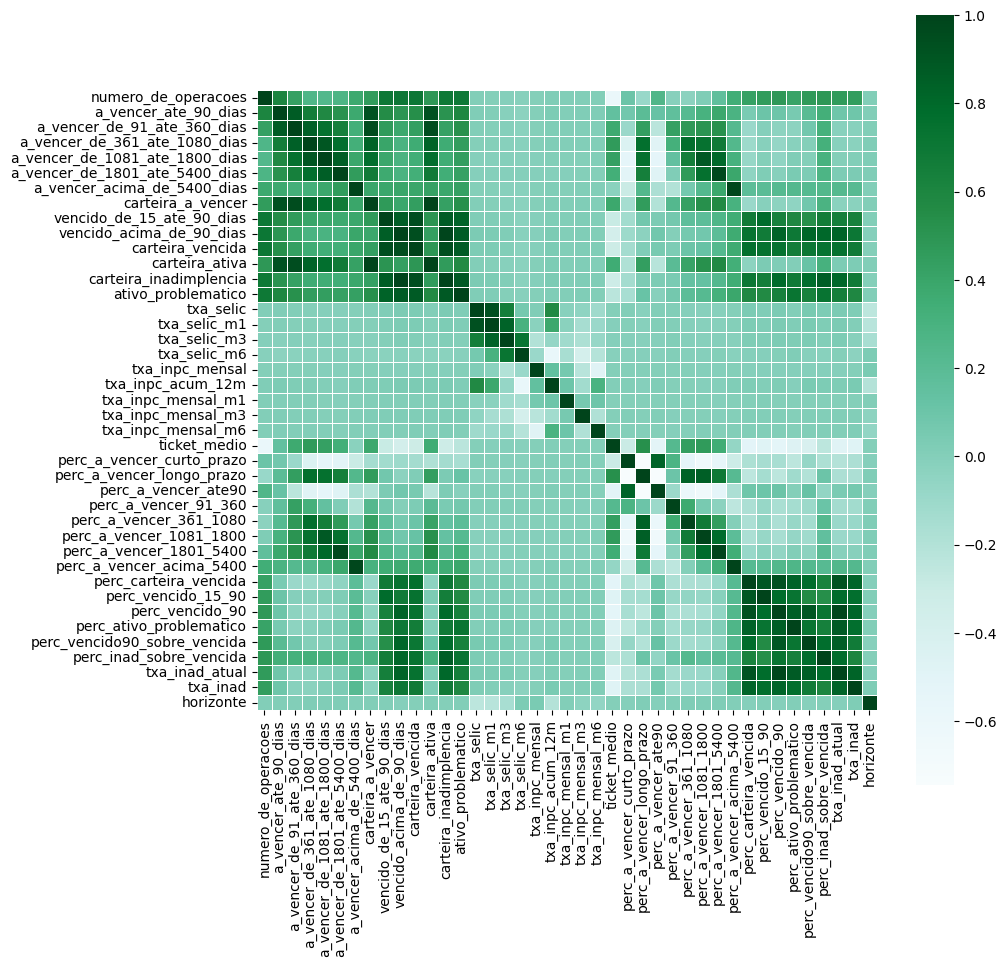

In [ ]:
# Spearman
plt.figure(figsize=(10, 10))

sns.heatmap(
    df_master[col_num].corr(method='spearman'),
    annot = False,
    fmt = '.1f',
    cmap = 'BuGn',
    linewidths = 0.5,
    square = True
)

plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.show()

In [ ]:
corr = df_master[col_num].corr(method='spearman')

# Pega apenas o triângulo superior da matriz
upper = corr.where(
    np.triu(np.ones(corr.shape), k=1).astype(bool)
)

# Transforma em lista de pares
corr_pairs = (
    upper.stack()
         .reset_index()
         .rename(columns={
             'level_0': 'Variavel_1',
             'level_1': 'Variavel_2',
             0: 'Correlacao'
         })
)

# Ordena pela magnitude da correlação
corr_pairs['Abs_Correlacao'] = corr_pairs['Correlacao'].abs()

corr_pairs = corr_pairs.sort_values(
    'Abs_Correlacao',
    ascending=False
).reset_index(drop=True)

corr_pairs[corr_pairs['Abs_Correlacao'] >= 0.8].head(20)

,Variavel_1,Variavel_2,Correlacao,Abs_Correlacao
0,carteira_a_vencer,carteira_ativa,0.9940,0.9940
1,vencido_acima_de_90_dias,carteira_inadimplencia,0.9878,0.9878
2,perc_vencido_90,txa_inad_atual,0.9842,0.9842
3,a_vencer_acima_de_5400_dias,perc_a_vencer_acima_5400,0.9818,0.9818
4,a_vencer_de_1801_ate_5400_dias,perc_a_vencer_1801_5400,0.9675,0.9675
5,a_vencer_de_91_ate_360_dias,carteira_a_vencer,0.9572,0.9572
6,vencido_de_15_ate_90_dias,carteira_vencida,0.9500,0.9500
7,a_vencer_de_91_ate_360_dias,carteira_ativa,0.9459,0.9459
8,vencido_acima_de_90_dias,carteira_vencida,0.9451,0.9451
9,carteira_vencida,carteira_inadimplencia,0.9393,0.9393


### 3.5. Boxplot

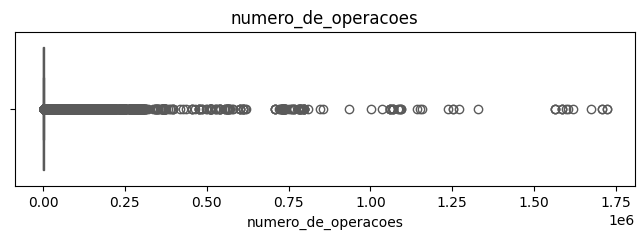

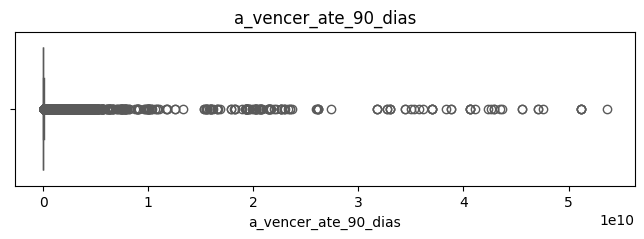

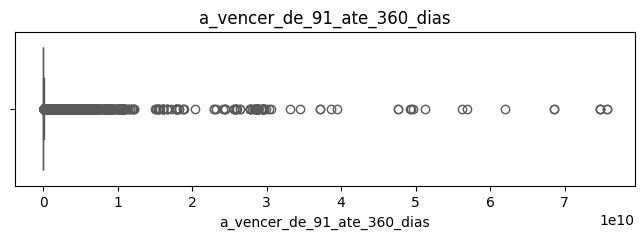

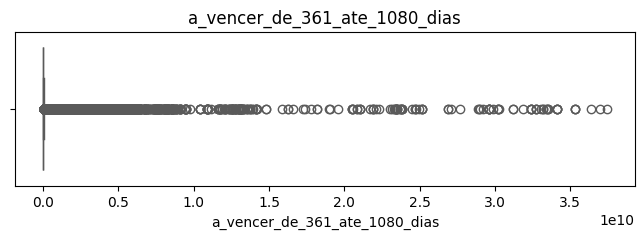

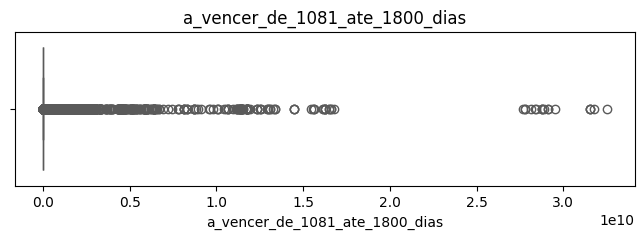

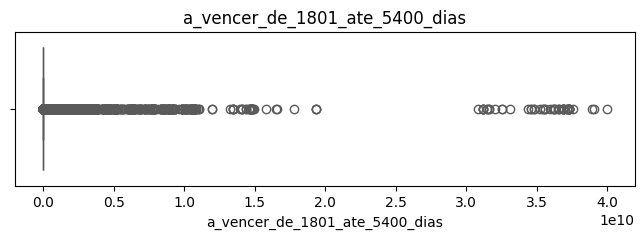

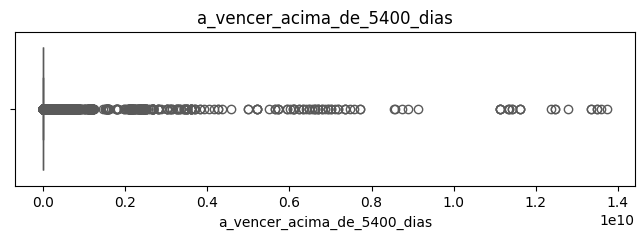

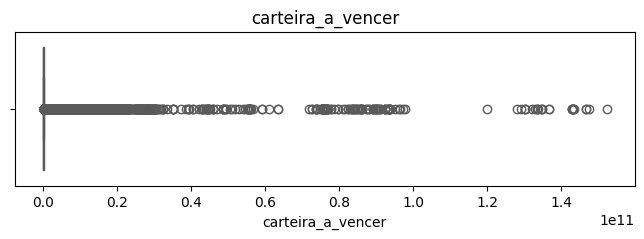

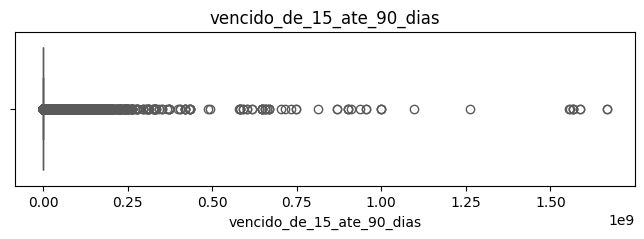

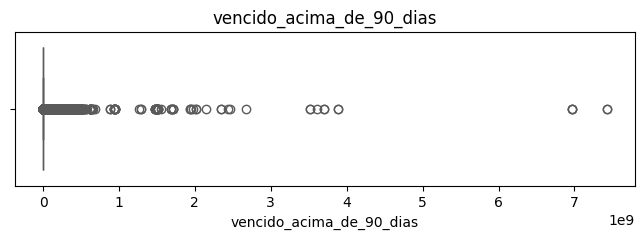

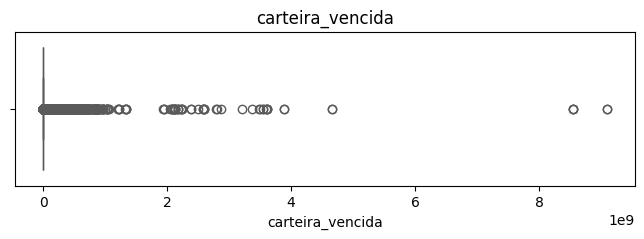

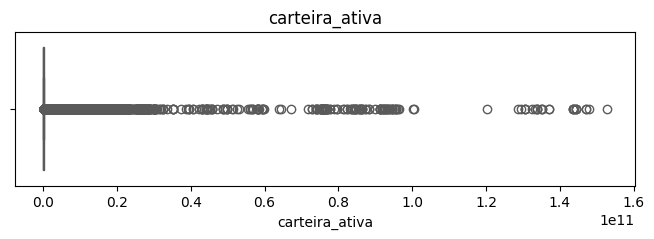

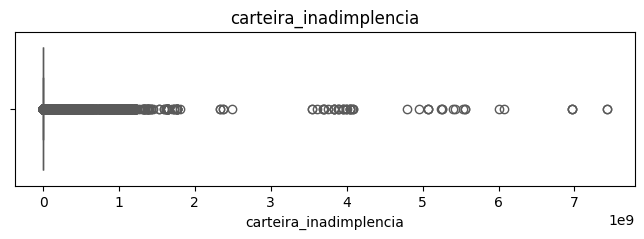

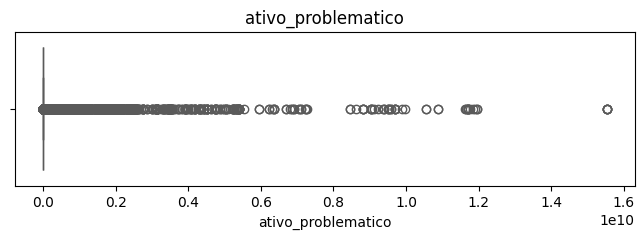

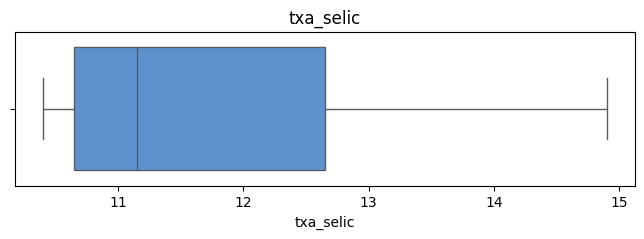

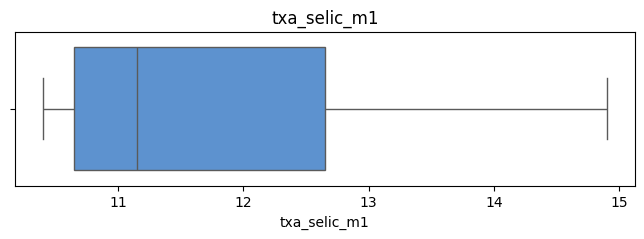

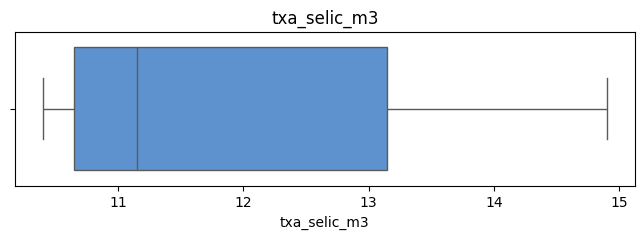

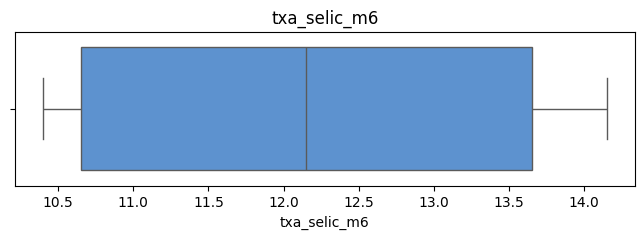

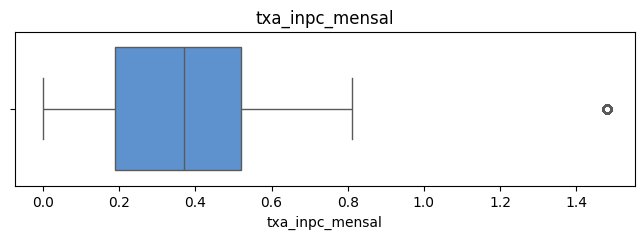

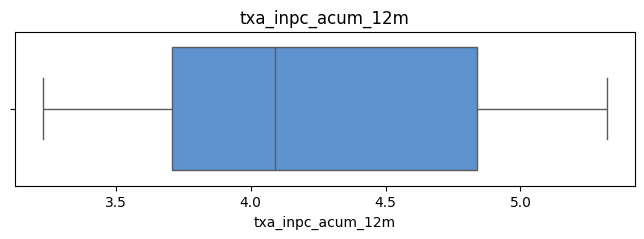

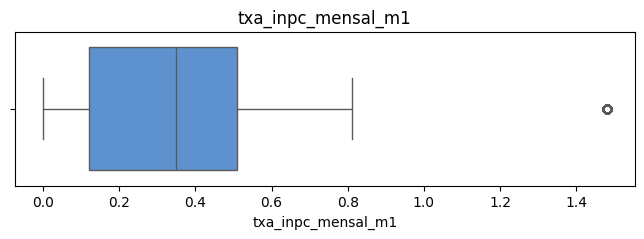

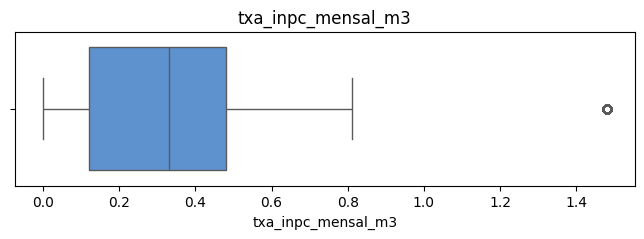

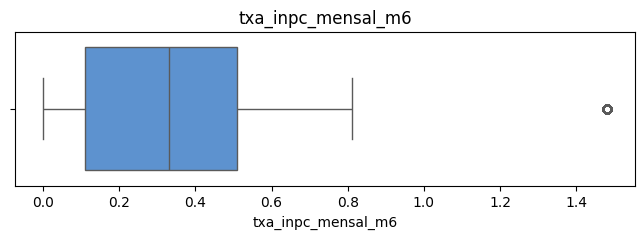

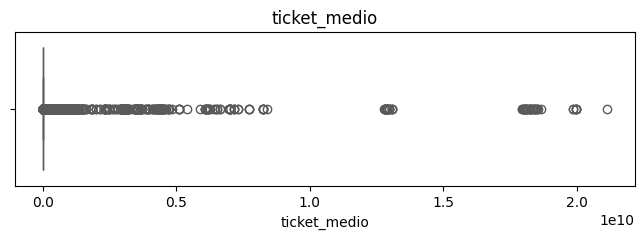

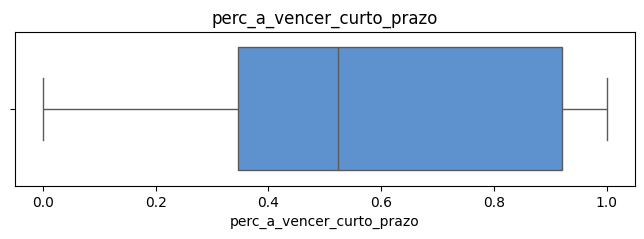

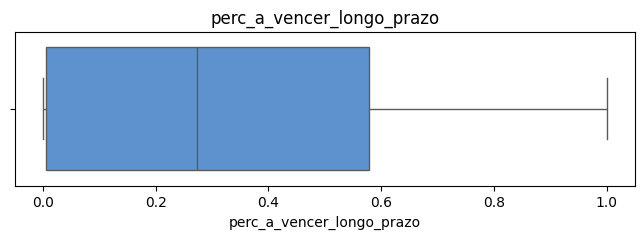

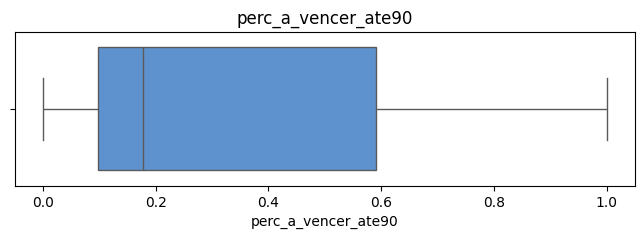

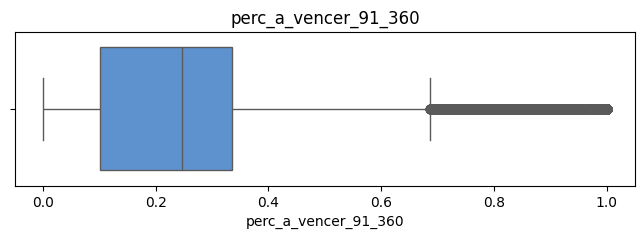

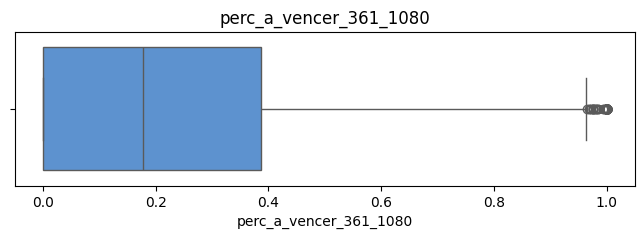

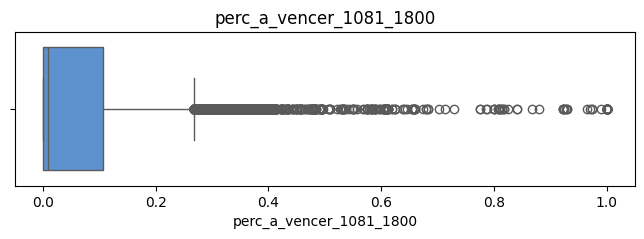

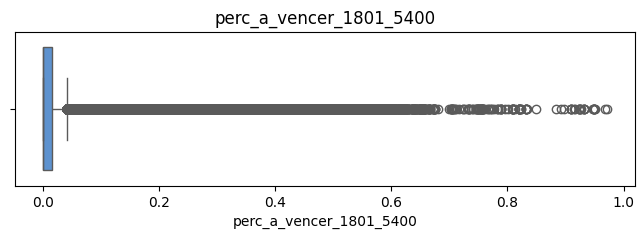

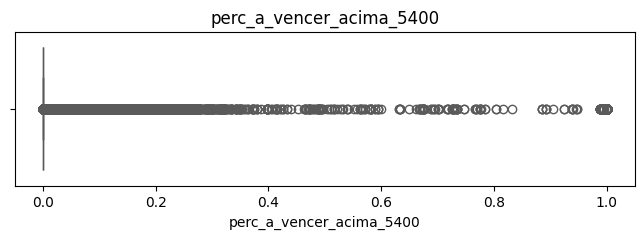

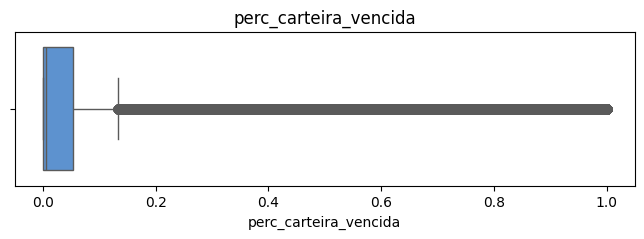

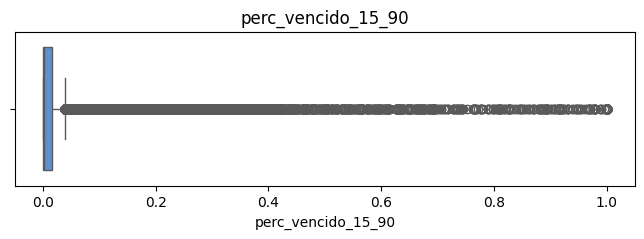

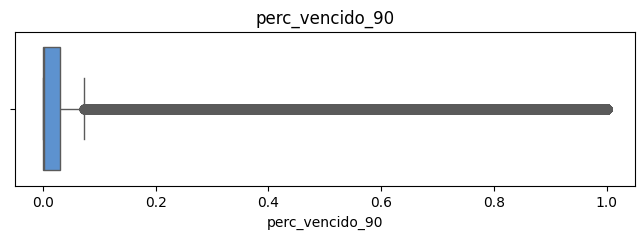

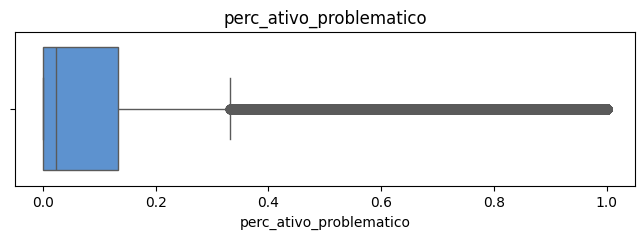

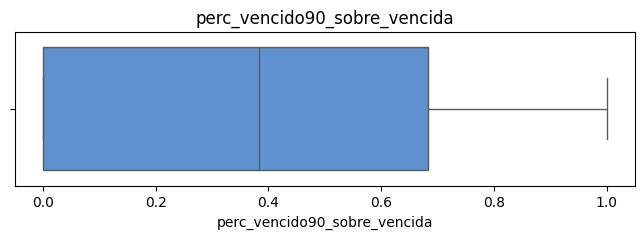

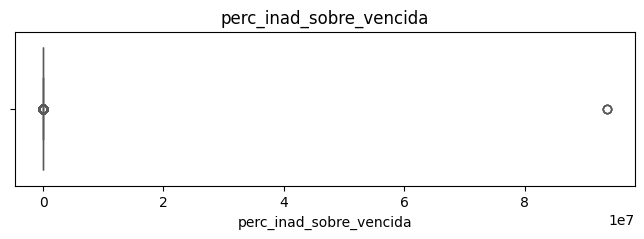

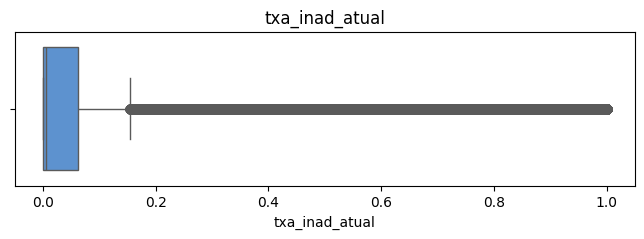

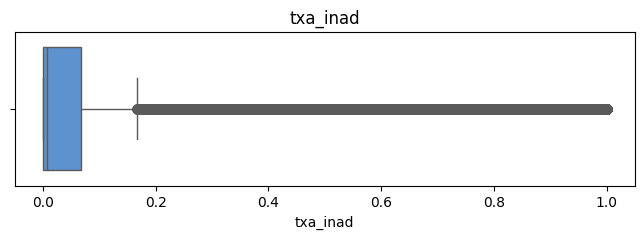

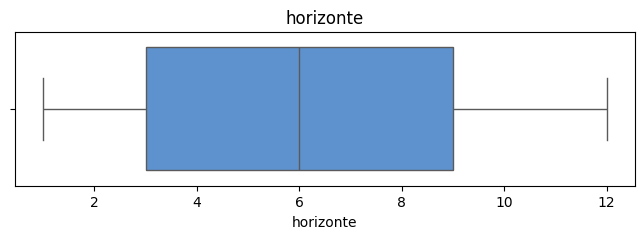

In [ ]:
df_sample = df_master.sample(frac = 0.1,
                             random_state = 42)

# boxplot das features numéricas
for col in col_num:
    plt.figure(figsize=(8, 2))
    plt.title(col)
    sns.boxplot(
        data = df_sample,
        x = col,
        orient = 'h',
        color = '#4A90E2'
    )
    plt.show()

In [ ]:
to_cat = ['uf', 'segmento', 'porte', 'anomes']

df_master[to_cat] = df_master[to_cat].astype('category')

In [ ]:
df_master['modalidade'] = df_master['modalidade']\
                                .apply(lambda x: unicodedata.normalize("NFKD", x)\
                                    .encode("ascii", "ignore")\
                                    .decode("utf-8"))\
                                .str.replace(r"[^a-zA-Z0-9\s]", "", regex=True)\
                                .str.replace(r"\s+", " ", regex=True)\
                                .str.strip()\
                                .astype('category')
                                # .str.split('')

# 4. Split Data

In [ ]:
target = 'txa_inad'
predictors = df_master.drop(columns = target).columns

In [ ]:
meses_treino = ['202310', '202311', '202312', '202401', '202402', '202403', '202404', '202405', '202406', '202407', '202408', '202409']
meses_valid  = ['202410', '202411']
meses_teste  = ['202412']

# Filtra uma única vez por partição (com 'anomes' ainda presente)
train_full = df_master[df_master['anomes'].isin(meses_treino)]
valid_full = df_master[df_master['anomes'].isin(meses_valid)]
test_full  = df_master[df_master['anomes'].isin(meses_teste)]

# Deriva os IDs (para reassociar depois) e os dados de modelagem (sem 'anomes'), a partir do mesmo objeto
train_ids, train_df = train_full[['anomes']], train_full.drop(columns = 'anomes')
valid_ids, valid_df = valid_full[['anomes']], valid_full.drop(columns = 'anomes')
test_ids,  test_df  = test_full[['anomes']],  test_full.drop(columns = 'anomes')

print('Observacoes por DataFrame')
print(f' Treino {train_df.shape[0]}')
print(f' Validacao {valid_df.shape[0]}')
print(f' Teste {test_df.shape[0]}')
print('-----------------------------')
print('Proporçao dos DataFrames')
print(f' Treino {round(train_df.shape[0]/df_master[df_master['anomes'].isin(meses_treino + meses_valid + meses_teste)].shape[0], 2)}')
print(f' Validacao {round(valid_df.shape[0]/df_master[df_master['anomes'].isin(meses_treino + meses_valid + meses_teste)].shape[0], 2)}')
print(f' Teste {round(test_df.shape[0]/df_master[df_master['anomes'].isin(meses_treino + meses_valid + meses_teste)].shape[0], 2)}')

Observacoes por DataFrame
 Treino 487977
 Validacao 80591
 Teste 39896
-----------------------------
Proporçao dos DataFrames
 Treino 0.8
 Validacao 0.13
 Teste 0.07


In [ ]:
col_cat = train_df.select_dtypes(exclude = 'number').columns.tolist()

# 5. Preprocessing

In [ ]:
predictors = train_df.drop(columns = target).columns

In [ ]:
# Salvo uma copia dos DFs antes de passar pelo preprocessing
train_df_orig = train_df.copy()
valid_df_orig = valid_df.copy()
test_df_orig = test_df.copy()

col_num = train_df.drop(columns = target).select_dtypes(include = 'number').columns.tolist()
col_cat = train_df.select_dtypes(exclude = 'number').columns.tolist()

# Pipeline para features numericas
pipeline_numerico = Pipeline(
    steps = [
        ('imputer', SimpleImputer(strategy = 'median')),
        ('scaler', StandardScaler())
        ]
    )

# Pipeline para features categoricas
pipeline_categorico = Pipeline(
    steps = [
        ('imputer', SimpleImputer(strategy = 'most_frequent')),
        ('onehot', OneHotEncoder(handle_unknown='ignore',
                                sparse_output=False)),
        ]
    )

# Crio o ColumnTransformer com os pipelines
preprocess = ColumnTransformer(
    transformers = [
        ('num', pipeline_numerico, col_num),
       ('cat', pipeline_categorico, col_cat),
    ]
)

# Aplico os pipelines sobre os DFs
X_train_transf = preprocess.fit_transform(train_df)
X_valid_transf = preprocess.transform(valid_df)
X_test_transf = preprocess.transform(test_df)

# Capturo os nomes das colunas categoricas transformadas pelo OneHot
col_cat_out = preprocess.named_transformers_['cat']['onehot'].get_feature_names_out(col_cat)

# Crio um numpy com as colunas pos preprocessamento
col_transf = np.concatenate([col_num, col_cat_out])

# Reconstruindo os DataFrames
# Treino
train_df_transf = pd.DataFrame(X_train_transf, columns = col_transf, index = train_df_orig.index)
train_df_transf[target] = train_df_orig[target]

# Validacao
valid_df_transf = pd.DataFrame(X_valid_transf, columns = col_transf, index = valid_df_orig.index)
valid_df_transf[target] = valid_df_orig[target]

# Teste
test_df_transf = pd.DataFrame(X_test_transf, columns = col_transf, index = test_df_orig.index)
test_df_transf[target] = test_df_orig[target]

print('Shape Final',
      '\n',
      f' Treino: {train_df_transf.shape}',
      '\n',
      f' Validacao: {valid_df_transf.shape}',
      '\n',
      f' Teste: {test_df_transf.shape}')
print('-----------------------------')
print('Média da target',
      '\n',
      f' Treino: {round(train_df_transf[target].mean(), 2)}',
      '\n',
      f' Validacao: {round(valid_df_transf[target].mean(), 2)}',
      '\n',
      f' Teste: {round(test_df_transf[target].mean(), 2)}')
print('-----------------------------')
print(f'Features pos preprocessing {len(col_transf)}',
      '\n',
      col_transf)

Shape Final 
  Treino: (487977, 94) 
  Validacao: (80591, 94) 
  Teste: (39896, 94)
-----------------------------
Média da target 
  Treino: 0.09 
  Validacao: 0.1 
  Teste: 0.1
-----------------------------
Features pos preprocessing 93 
 ['numero_de_operacoes' 'a_vencer_ate_90_dias'
 'a_vencer_de_91_ate_360_dias' 'a_vencer_de_361_ate_1080_dias'
 'a_vencer_de_1081_ate_1800_dias' 'a_vencer_de_1801_ate_5400_dias'
 'a_vencer_acima_de_5400_dias' 'carteira_a_vencer'
 'vencido_de_15_ate_90_dias' 'vencido_acima_de_90_dias' 'carteira_vencida'
 'carteira_ativa' 'carteira_inadimplencia' 'ativo_problematico'
 'txa_selic' 'txa_selic_m1' 'txa_selic_m3' 'txa_selic_m6'
 'txa_inpc_mensal' 'txa_inpc_acum_12m' 'txa_inpc_mensal_m1'
 'txa_inpc_mensal_m3' 'txa_inpc_mensal_m6' 'ticket_medio'
 'perc_a_vencer_curto_prazo' 'perc_a_vencer_longo_prazo'
 'perc_a_vencer_ate90' 'perc_a_vencer_91_360' 'perc_a_vencer_361_1080'
 'perc_a_vencer_1081_1800' 'perc_a_vencer_1801_5400'
 'perc_a_vencer_acima_5400' 'perc_car

# Modelo de Hurdle

In [ ]:
n_patience = 5
n_epochs = 50

## Classificação

A primeira etapa do modelo busca capturar a probabilidade da target (Y) ser maior que 0 dado um exemplo X
$$P(Y > 0 | X)$$

In [ ]:
target_bin = 'target_inad'

train_df_transf[target_bin] = (train_df_transf[target] > 0).astype(int)
valid_df_transf[target_bin] = (valid_df_transf[target] > 0).astype(int)
test_df_transf[target_bin] = (test_df_transf[target] > 0).astype(int)

predictors = train_df_transf.drop(columns = [target, target_bin]).columns

print('Média da target',
      '\n',
      f' Treino: {round(train_df_transf[target_bin].sum()/train_df_transf.shape[0], 2)}',
      '\n',
      f' Validacao: {round(valid_df_transf[target_bin].sum()/valid_df_transf.shape[0], 2)}',
      '\n',
      f' Teste: {round(test_df_transf[target_bin].sum()/test_df_transf.shape[0], 2)}')

Média da target 
  Treino: 0.59 
  Validacao: 0.62 
  Teste: 0.63


### Arquitetura da Rede

In [ ]:
tf.keras.backend.clear_session()
tf.keras.utils.set_random_seed(p_random)
tf.config.experimental.enable_op_determinism()

In [ ]:
# Dimensao de entrada
input_dim = len(predictors)

print(f'Features de entrada: {input_dim}')

mlp_classif = models.Sequential([
    # ---------------- Input Layer ---------------- #
    layers.Input(shape = (input_dim,)),


    # ---------------- First Layer ---------------- #
    layers.Dense(128),   # Primeira Layer oculta
    layers.BatchNormalization(),
    layers.Activation('relu'), # Função de Ativação Relu
    layers.Dropout(0.3),                   # dropout (evita overfitting)

    # ---------------- Second Layer ---------------- #
    layers.Dense(64),   # Primeira Layer oculta
    layers.BatchNormalization(),
    layers.Activation('relu'), # Função de Ativação Relu
    layers.Dropout(0.3),                   # dropout (evita overfitting)

    # ---------------- Thrid Layer ---------------- #
    layers.Dense(32),   # Segunda Layer oculta
    layers.BatchNormalization(),
    layers.Activation('relu'), # Função de Ativação Relu
    layers.Dropout(0.3),                   # dropout (evita overfitting)

    # ---------------- Output Layer ---------------- #
    layers.Dense(1, activation = "sigmoid")  # Saida para classificacao binaria com sigmoid
])

mlp_classif.summary()

Features de entrada: 93


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │        12,032 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,297 (91.00 KB)

 Trainable params: 22,849 (89.25 KB)

 Non-trainable params: 448 (1.75 KB)

In [ ]:
# Compila o modelo
mlp_classif.compile(
    optimizer = 'adam',
    loss = 'binary_crossentropy', # Funcao de Custo
    metrics = [
        'accuracy',
        keras.metrics.F1Score(threshold=0.5, average='micro'),
        keras.metrics.AUC(name='AUC')
    ] # metrica de Avalicao
)

early_stop = callbacks.EarlyStopping(
    monitor = 'val_AUC',         # Quantity to be monitored. Defaults to "val_loss".
    mode = 'max',
    patience = n_patience,                # Para apos 5 epocas sem avancos
    restore_best_weights = True  # Se True captura os pesos da melhor epoca
)

# Treinar o modelo
history_classif = mlp_classif.fit(
    train_df_transf[predictors], # Dados do DataFrame de Treino
    train_df_transf[target_bin], # Target do DataFrame de Treino
    validation_data = (valid_df_transf[predictors],
                       valid_df_transf[target_bin]), # DataFrame de Validacao
    epochs = n_epochs,               # Maximo de epocas
    batch_size = 256,           # Tamanho do batch
    callbacks = [early_stop],
    verbose = 1
)

Epoch 1/50
1907/1907 ━━━━━━━━━━━━━━━━━━━━ 21s 9ms/step - AUC: 0.9500 - accuracy: 0.8840 - f1_score: 0.9020 - loss: 0.2804 - val_AUC: 0.9616 - val_accuracy: 0.8930 - val_f1_score: 0.9122 - val_loss: 0.2444
Epoch 2/50
1907/1907 ━━━━━━━━━━━━━━━━━━━━ 16s 8ms/step - AUC: 0.9677 - accuracy: 0.9045 - f1_score: 0.9194 - loss: 0.2257 - val_AUC: 0.9668 - val_accuracy: 0.9005 - val_f1_score: 0.9190 - val_loss: 0.2262
Epoch 3/50
1907/1907 ━━━━━━━━━━━━━━━━━━━━ 16s 8ms/step - AUC: 0.9728 - accuracy: 0.9125 - f1_score: 0.9262 - loss: 0.2068 - val_AUC: 0.9697 - val_accuracy: 0.9051 - val_f1_score: 0.9229 - val_loss: 0.2161
Epoch 4/50
1907/1907 ━━━━━━━━━━━━━━━━━━━━ 16s 8ms/step - AUC: 0.9758 - accuracy: 0.9171 - f1_score: 0.9301 - loss: 0.1951 - val_AUC: 0.9719 - val_accuracy: 0.9087 - val_f1_score: 0.9258 - val_loss: 0.2075
Epoch 5/50
1907/1907 ━━━━━━━━━━━━━━━━━━━━ 16s 8ms/step - AUC: 0.9777 - accuracy: 0.9205 - f1_score: 0.9329 - loss: 0.1872 - val_AUC: 0.9744 - val_accuracy: 0.9131 - val_f1_score: 0

### Avaliação

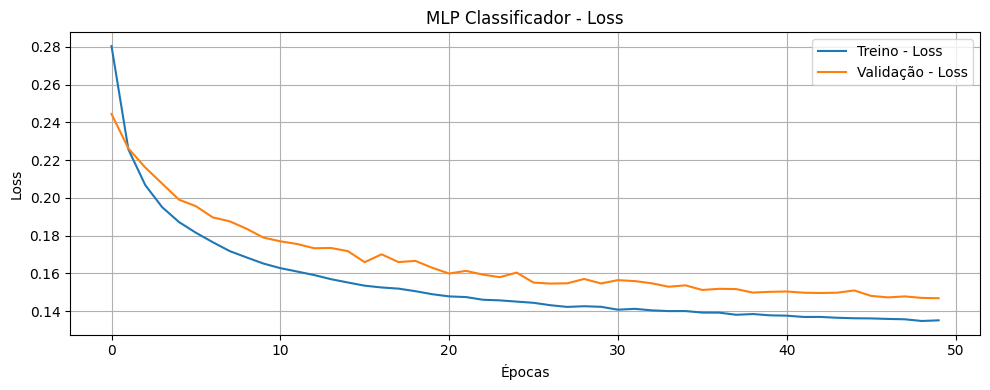

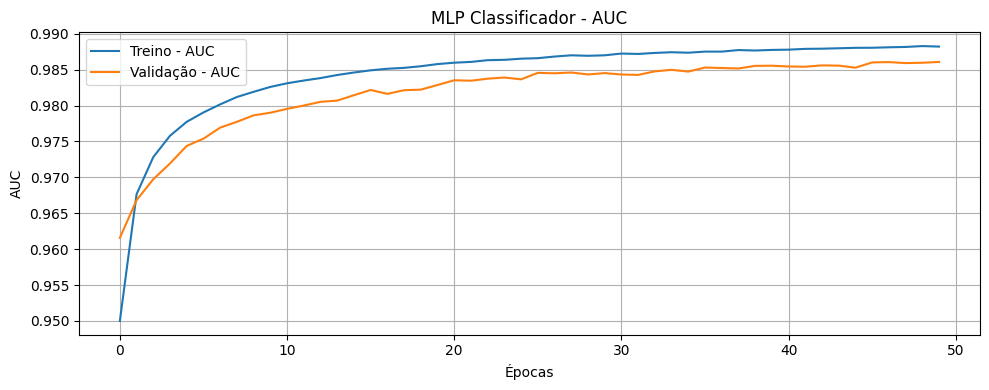

In [ ]:
# Histórico
history_classif_dict = history_classif.history

# Loss
plt.figure(figsize = (10, 4))
plt.plot(history_classif_dict['loss'], label = 'Treino - Loss')
plt.plot(history_classif_dict['val_loss'], label = 'Validação - Loss')
plt.xlabel('Épocas')
plt.ylabel('Loss')
# plt.ylim(0, 1)
plt.title('MLP Classificador - Loss')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(
    '/content/drive/MyDrive/Estudos/USP/MBA/TCC/Projeto/output/Figures/loss_classificador.pdf',
    bbox_inches='tight'
)
plt.show()

# AUC
plt.figure(figsize = (10, 4))
plt.plot(history_classif_dict['AUC'], label = 'Treino - AUC')
plt.plot(history_classif_dict['val_AUC'], label = 'Validação - AUC')
plt.xlabel('Épocas')
plt.ylabel('AUC')
# plt.ylim(0, 1)
plt.title('MLP Classificador - AUC')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(
    '/content/drive/MyDrive/Estudos/USP/MBA/TCC/Projeto/output/Figures/acc_classificador.pdf',
    bbox_inches='tight'
)
plt.show()

In [ ]:
probs_c = mlp_classif.predict(valid_df_transf[predictors]).flatten()
preds_c = (probs_c > 0.5).astype(int)

avalia_modelos_c(valid_df_transf[target_bin].values, preds_c, probs_c)

2519/2519 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step


{'Accuracy': 0.9386159744884665,
 'Recall': 0.9432202541779245,
 'Precision': 0.957146919046265,
 'F1 Score': 0.9501325564751066,
 'AUC': np.float64(0.9862991411953496)}

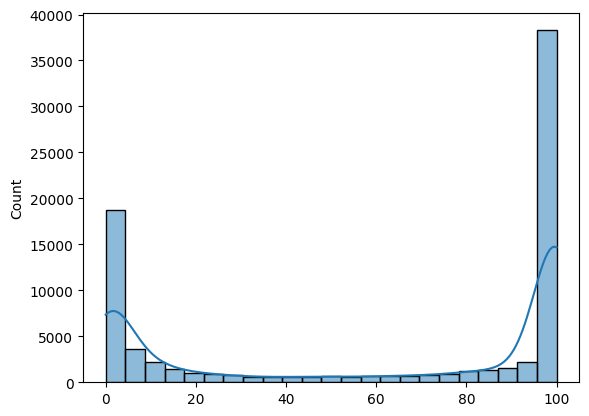

In [ ]:
sns.histplot(probs_c*100,
             kde = True)
plt.show()

<Figure size 800x600 with 0 Axes>

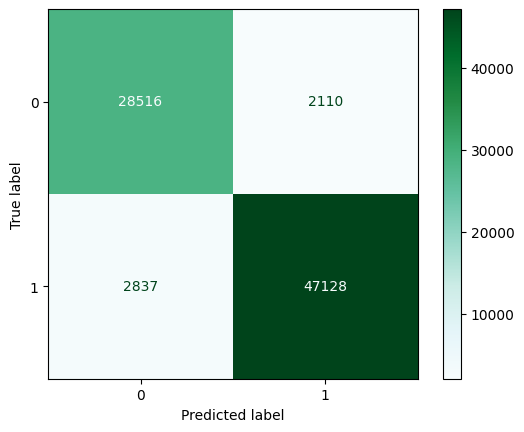

In [ ]:
plt.figure(figsize = (8, 6))
ConfusionMatrixDisplay.from_predictions(valid_df_transf[target_bin].values,
                                        preds_c,
                                        cmap = 'BuGn')

plt.show()

### Calibração

2519/2519 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step
1247/1247 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step


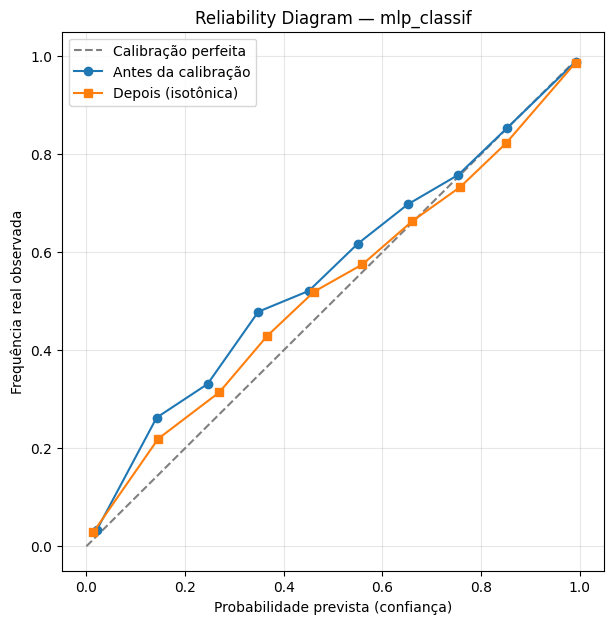

In [ ]:
# Capturo as saídas brutas do modelo de classificação
probs_valid_c = mlp_classif.predict(valid_df_transf[predictors]).flatten()
probs_test_c  = mlp_classif.predict(test_df_transf[predictors]).flatten()

# Calibra a curva Isotonica na Validacao
iso_calibrator = IsotonicRegression(out_of_bounds = 'clip')
iso_calibrator.fit(probs_valid_c, valid_df_transf[target_bin].values)

# Aplica no teste (única vez, sem refit)
probs_test_c_calib = iso_calibrator.predict(probs_test_c)
probs_valid_c_calib = iso_calibrator.predict(probs_valid_c)

# Reability Diagram
prob_true_raw, prob_pred_raw = calibration_curve(test_df_transf[target_bin].values,
                                                 probs_test_c,
                                                 n_bins = 10,
                                                 strategy='uniform')
prob_true_calib, prob_pred_calib = calibration_curve(test_df_transf[target_bin].values,
                                                     probs_test_c_calib,
                                                     n_bins = 10,
                                                     strategy = 'uniform')

plt.figure(figsize=(7,7))
plt.plot([0,1], [0,1], linestyle='--', color='gray', label='Calibração perfeita')
plt.plot(prob_pred_raw, prob_true_raw, marker='o', label='Antes da calibração')
plt.plot(prob_pred_calib, prob_true_calib, marker='s', label='Depois (isotônica)')
plt.xlabel('Probabilidade prevista (confiança)')
plt.ylabel('Frequência real observada')
plt.title('Reliability Diagram — mlp_classif')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

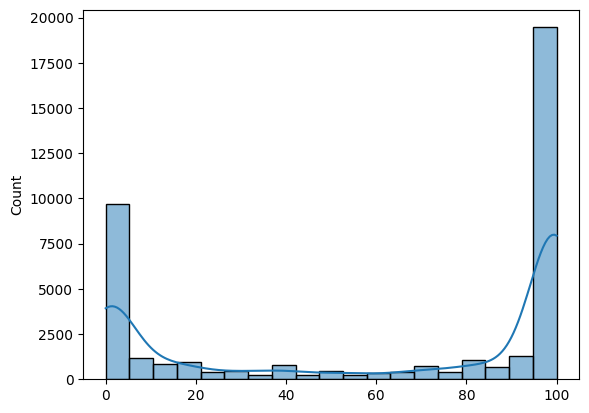

In [ ]:
sns.histplot(probs_test_c_calib*100,
             kde = True)
plt.show()

In [ ]:
avalia_modelos_c(valid_df_transf[target_bin].values,
                (probs_valid_c > 0.5).astype(int),
                probs_valid_c)

{'Accuracy': 0.9386159744884665,
 'Recall': 0.9432202541779245,
 'Precision': 0.957146919046265,
 'F1 Score': 0.9501325564751066,
 'AUC': np.float64(0.9862991411953496)}

{'Accuracy': 0.9390006328250052, 'Recall': 0.9451015710997699, 'Precision': 0.9560076930863448, 'F1 Score': 0.9505233494363929, 'AUC': np.float64(0.9863993370426235)}


<Figure size 667x500 with 0 Axes>

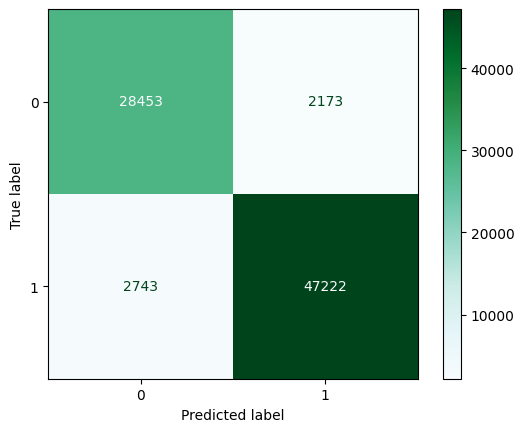

In [ ]:
print(avalia_modelos_c(valid_df_transf[target_bin].values,
                       (probs_valid_c_calib > 0.5).astype(int),
                       probs_valid_c_calib))

plt.figure(figsize = (6.67, 5))
ConfusionMatrixDisplay.from_predictions(valid_df_transf[target_bin].values,
                                        (probs_valid_c_calib > 0.5).astype(int),
                                        cmap = 'BuGn')
plt.savefig(
    '/content/drive/MyDrive/Estudos/USP/MBA/TCC/Projeto/output/Figures/matriz_confusao.pdf',
    bbox_inches='tight'
)
plt.show()

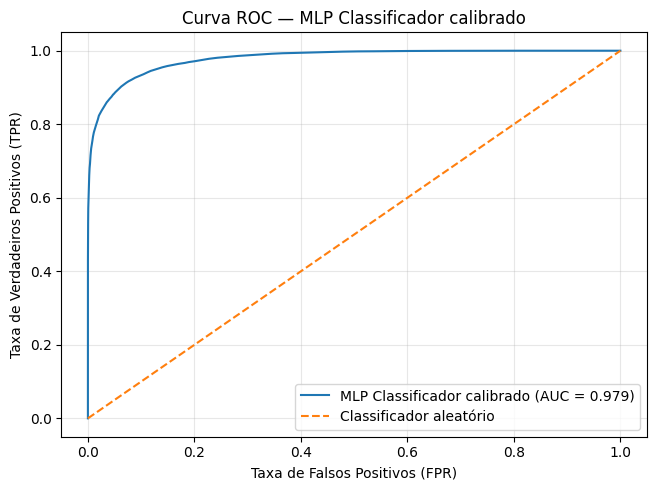

In [ ]:
y_score_calib = probs_test_c_calib

fpr_calib, tpr_calib, thresholds_calib = roc_curve(
    test_df_transf[target_bin].values,
    y_score_calib
)

auc_calib = roc_auc_score(
    test_df_transf[target_bin].values,
    y_score_calib
)

plt.figure(figsize = (6.67, 5))
plt.plot(
    fpr_calib,
    tpr_calib,
    label=f'MLP Classificador calibrado (AUC = {auc_calib:.3f})'
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle='--',
    label='Classificador aleatório'
)

plt.xlabel('Taxa de Falsos Positivos (FPR)')
plt.ylabel('Taxa de Verdadeiros Positivos (TPR)')
plt.title('Curva ROC — MLP Classificador calibrado')

plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig(
    '/content/drive/MyDrive/Estudos/USP/MBA/TCC/Projeto/output/Figures/curva_roc.pdf',
    bbox_inches='tight'
)

plt.show()

## Modelo de Regressão

A segunda etapa busca calcular a esperança da target Y dado Y > 0 e um exemplo X

$$E[Y | Y > 0, X]$$

### Arquitetura da Rede

In [ ]:
tf.keras.backend.clear_session()      # limpa grafo/estado do Keras
tf.keras.utils.set_random_seed(p_random)
tf.config.experimental.enable_op_determinism()

In [ ]:
input_dim = len(predictors)

mlp_regress = models.Sequential([
    # ---------------- Input Layer ---------------- #
    layers.Input(shape=(input_dim,)),

    # ---------------- First Layer ---------------- #
    layers.Dense(128),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.Dropout(0.2),

    # ---------------- Second Layer ---------------- #
    layers.Dense(64),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.Dropout(0.2),

    # ---------------- Third Layer ---------------- #
    layers.Dense(32),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.Dropout(0.15),

    # ---------------- Output Layer ---------------- #
    layers.Dense(1, activation='linear')   # saída linear, sem sigmoid
])

mlp_regress.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │        12,032 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,297 (91.00 KB)

 Trainable params: 22,849 (89.25 KB)

 Non-trainable params: 448 (1.75 KB)

In [ ]:
# Compila o modelo de regressão
mlp_regress.compile(
    optimizer = 'adam',
    loss = keras.losses.Huber(delta=1.0),   # mais robusta a outliers que MSE puro
    metrics = [
        'mae',
        keras.metrics.RootMeanSquaredError(name = 'rmse')
    ]
)

early_stop = callbacks.EarlyStopping(
    monitor = 'val_rmse',        # ou 'val_loss' — ambos fazem sentido aqui
    mode = 'min',
    patience = n_patience,
    restore_best_weights = True
)

# Treinar o modelo
history_regress = mlp_regress.fit(
    train_df_transf[train_df_transf[target] > 0][predictors],          # apenas Y > 0
    train_df_transf[train_df_transf[target] > 0][target],         # target contínua (ou já transformada, se usar logit)
    validation_data = (valid_df_transf[valid_df_transf[target] > 0][predictors],
                       valid_df_transf[valid_df_transf[target] > 0][target]),  # também apenas Y > 0
    epochs = n_epochs,
    batch_size = 256,
    callbacks = [early_stop],
    verbose = 1
)

Epoch 1/50
1133/1133 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - loss: 0.0281 - mae: 0.1412 - rmse: 0.2526 - val_loss: 0.0108 - val_mae: 0.0769 - val_rmse: 0.1467
Epoch 2/50
1133/1133 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - loss: 0.0101 - mae: 0.0809 - rmse: 0.1420 - val_loss: 0.0101 - val_mae: 0.0734 - val_rmse: 0.1422
Epoch 3/50
1133/1133 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - loss: 0.0088 - mae: 0.0739 - rmse: 0.1330 - val_loss: 0.0092 - val_mae: 0.0685 - val_rmse: 0.1358
Epoch 4/50
1133/1133 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - loss: 0.0078 - mae: 0.0689 - rmse: 0.1251 - val_loss: 0.0087 - val_mae: 0.0673 - val_rmse: 0.1321
Epoch 5/50
1133/1133 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - loss: 0.0070 - mae: 0.0653 - rmse: 0.1187 - val_loss: 0.0078 - val_mae: 0.0633 - val_rmse: 0.1246
Epoch 6/50
1133/1133 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - loss: 0.0065 - mae: 0.0624 - rmse: 0.1138 - val_loss: 0.0069 - val_mae: 0.0596 - val_rmse: 0.1176
Epoch 7/50
1133/1133 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - loss: 0.0061 - m

### Resultados

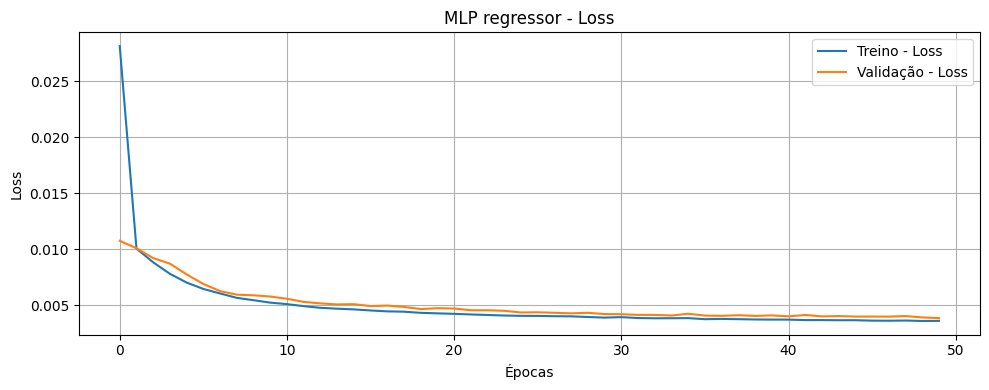

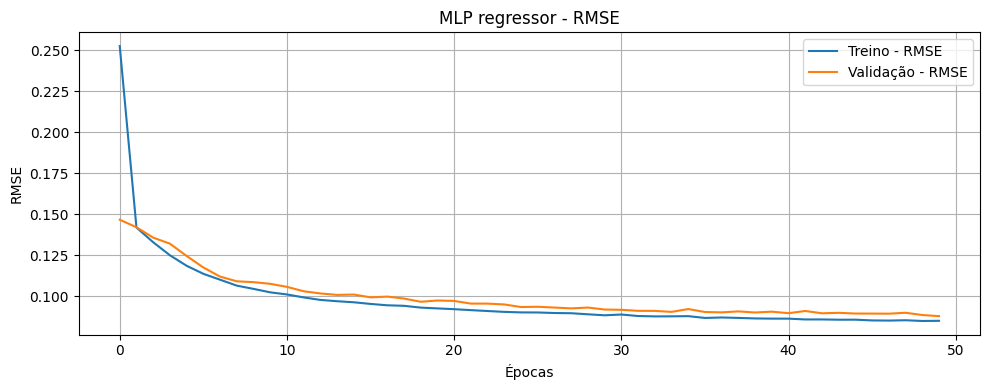

In [ ]:
# Histórico
history_regress_dict = history_regress.history

# Loss
plt.figure(figsize = (10, 4))
plt.plot(history_regress_dict['loss'], label = 'Treino - Loss')
plt.plot(history_regress_dict['val_loss'], label = 'Validação - Loss')
plt.xlabel('Épocas')
plt.ylabel('Loss')
# plt.ylim(0, 1)
plt.title('MLP regressor - Loss')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(
    '/content/drive/MyDrive/Estudos/USP/MBA/TCC/Projeto/output/Figures/loss_regressor.pdf',
    bbox_inches='tight'
)
plt.show()

# RMSE
plt.figure(figsize = (10, 4))
plt.plot(history_regress_dict['rmse'], label = 'Treino - RMSE')
plt.plot(history_regress_dict['val_rmse'], label = 'Validação - RMSE')
plt.xlabel('Épocas')
plt.ylabel('RMSE')
# plt.ylim(0, 1)
plt.title('MLP regressor - RMSE')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(
    '/content/drive/MyDrive/Estudos/USP/MBA/TCC/Projeto/output/Figures/rmse_regressor.pdf',
    bbox_inches='tight'
)
plt.show()

In [ ]:
valid_df[valid_df[target] > 0][target].describe().T

,txa_inad
count,49965.0000
mean,0.1552
std,0.2477
min,0.0000
25%,0.0121
50%,0.0468
75%,0.1498
max,1.0000


In [ ]:
preds_r = mlp_regress.predict(valid_df_transf[valid_df_transf[target] > 0][predictors]).flatten()

avalia_modelos_r(valid_df_transf[valid_df_transf[target] > 0][target].values, preds_r)

1562/1562 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step


{'MAE': 0.04363353174891475,
 'MSE': 0.007733927197853113,
 'RMSE': np.float64(0.08794274954681093),
 'R²': 0.8739752943673331}

In [ ]:
df_eval = pd.DataFrame({
    'real': valid_df_transf[valid_df_transf[target] > 0][target].values,
    'pred': preds_r
})

df_eval['percentil'] = pd.qcut(
    df_eval['pred'],
    q = 10,
    labels=False,
    duplicates='drop'
)

resultado = (
    df_eval
    .groupby('percentil')
    .agg(
        qtd = ('real', 'size'),
        taxa_real = ('real', 'mean'),
        taxa_prev = ('pred', 'mean'),
        mae=('real', lambda x: np.mean(np.abs(x - df_eval.loc[x.index, 'pred'])))
    )
    .reset_index()
)

resultado

,percentil,qtd,taxa_real,taxa_prev,mae
0,0,4997,0.0084,0.0023,0.0086
1,1,4996,0.0146,0.0111,0.0119
2,2,4997,0.0219,0.0162,0.0157
3,3,4996,0.0311,0.0221,0.0202
4,4,4997,0.0429,0.0314,0.0250
5,5,4996,0.0619,0.0511,0.0319
6,6,4996,0.0949,0.0947,0.0381
7,7,4997,0.1518,0.1588,0.0540
8,8,4996,0.3674,0.3988,0.1229
9,9,4997,0.7574,0.7646,0.1081


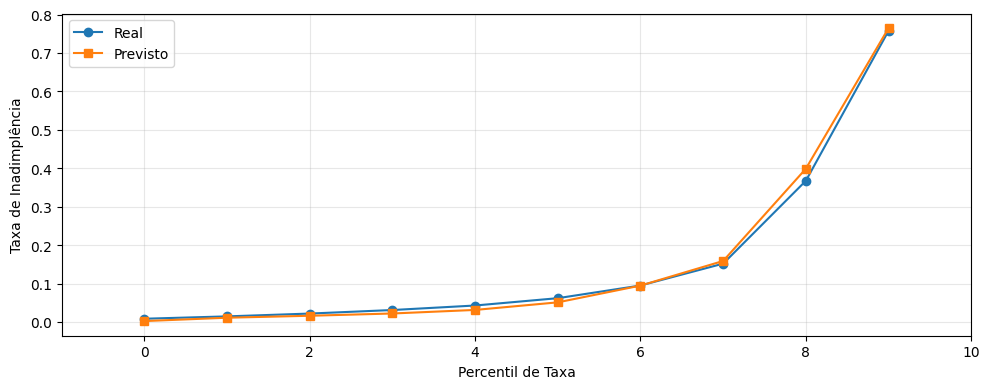

In [ ]:
plt.figure(figsize=(10, 4))

plt.plot(resultado['percentil'],
         resultado['taxa_real'],
         marker = 'o',
         label = 'Real')

plt.plot(resultado['percentil'],
         resultado['taxa_prev'],
         marker = 's',
         label = 'Previsto')

plt.xlim(-1, 10)
plt.xlabel('Percentil de Taxa')
plt.ylabel('Taxa de Inadimplência')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig(
    '/content/drive/MyDrive/Estudos/USP/MBA/TCC/Projeto/output/Figures/decil_regressor.pdf',
    bbox_inches='tight'
)

plt.show()

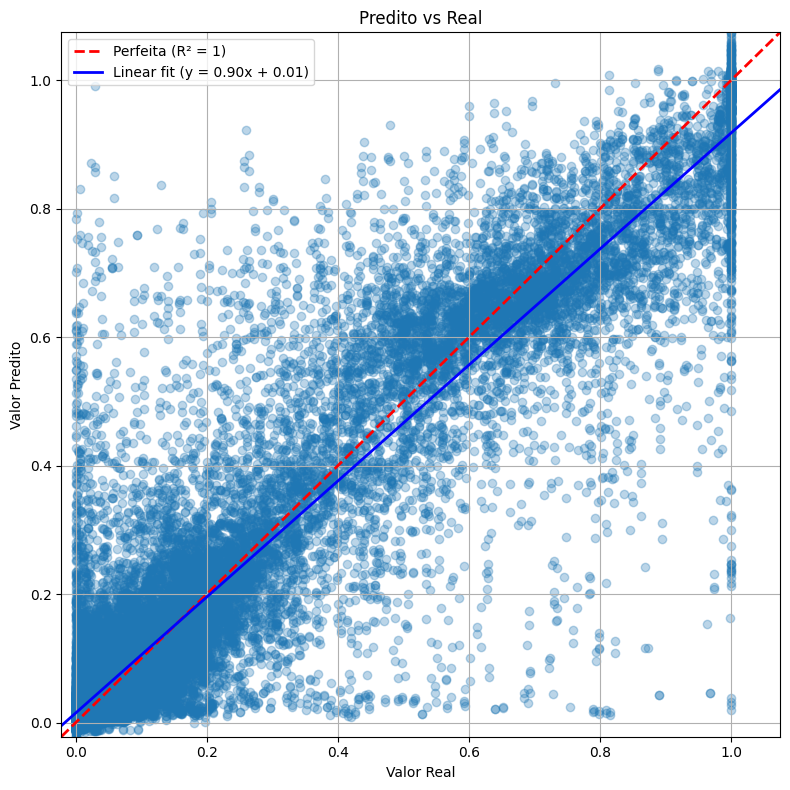

In [ ]:
y_true = valid_df_transf[valid_df_transf[target] > 0][target].values
y_pred = preds_r

plt.figure(figsize=(8, 8))

plt.scatter(y_true, y_pred, alpha=0.3)

# Limites comuns aos dois eixos
lims = [
    min(y_true.min(), y_pred.min()),
    max(y_true.max(), y_pred.max())
]

# Linha de referência: y = x (R² = 1)
plt.plot(
    lims,
    lims,
    'r--',
    linewidth=2,
    label='Perfeita (R² = 1)'
)

# Ajuste linear: y_pred = a * y_true + b
coef = np.polyfit(y_true, y_pred, 1)
a, b = coef

x_fit = np.linspace(lims[0], lims[1], 100)
y_fit = a * x_fit + b

plt.plot(
    x_fit,
    y_fit,
    color='blue',
    linewidth=2,
    label=f'Linear fit (y = {a:.2f}x + {b:.2f})'
)

plt.xlim(lims)
plt.ylim(lims)

plt.xlabel('Valor Real')
plt.ylabel('Valor Predito')
plt.title('Predito vs Real')

plt.legend()
plt.grid(True)
plt.tight_layout()

plt.show()

## Modelo Combinado

In [ ]:
avalia_modelos_c((probs_test_c_calib > 0.5).astype(int),
                 test_df_transf[target_bin].values,
                 probs_test_c_calib)

{'Accuracy': 0.9209444555845198,
 'Recall': 0.947157109254603,
 'Precision': 0.9265651035467746,
 'F1 Score': 0.9367479544360661,
 'AUC': np.float64(1.0)}

<Figure size 667x500 with 0 Axes>

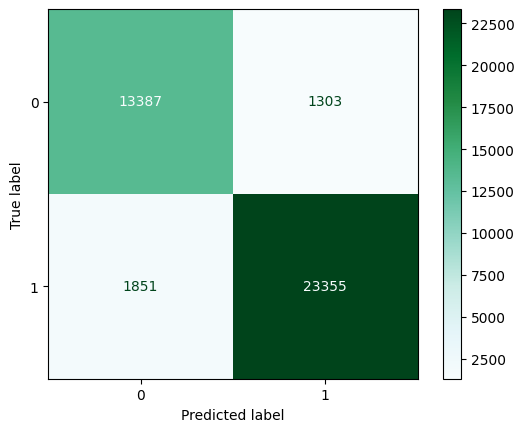

In [ ]:
plt.figure(figsize = (6.67, 5))
ConfusionMatrixDisplay.from_predictions(test_df_transf[target_bin].values,
                                        (probs_test_c_calib > 0.5).astype(int),
                                        cmap = 'BuGn')
plt.show()

In [ ]:
# Primeiro o MLP Classificador indica os casos com txa_inad > 0
test_df_transf['probs_test_c_calib'] = probs_test_c_calib

# Índice dos casos classificados como positivos
mask = test_df_transf['probs_test_c_calib'] > 0.5

# MLP Regressor prevê apenas para os casos positivos
preds_r = mlp_regress.predict(test_df_transf.loc[mask, predictors]).flatten()

preds_r = np.where(preds_r > 1, 1, preds_r)
preds_r = np.where(preds_r < 0, 0, preds_r)

# Retorna a previsão do regressor para as linhas correspondentes
test_df_transf['preds_r'] = 0
test_df_transf.loc[mask, 'preds_r'] = preds_r

771/771 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step


/tmp/ipykernel_2936/107996174.py:15: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[0.43471694 0.33706492 0.01997421 ... 0.01844282 0.01824844 0.09647314]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  test_df_transf.loc[mask, 'preds_r'] = preds_r


In [ ]:
avalia_modelos_r(test_df_transf[target].values, test_df_transf['preds_r'].values)

{'MAE': 0.039252417118587804,
 'MSE': 0.012610113903961473,
 'RMSE': np.float64(0.11229476347524613),
 'R²': 0.7230793057804082}

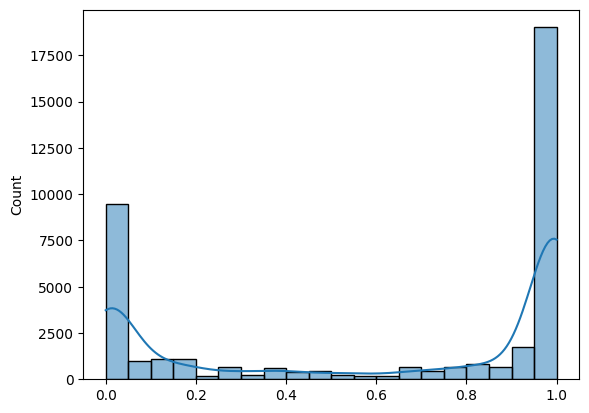

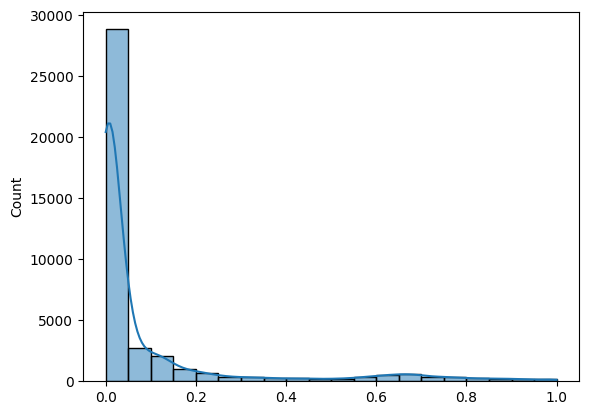

In [ ]:
sns.histplot(test_df_transf['probs_test_c_calib'].values,
             kde = True,
             bins = 20)
plt.show()

sns.histplot(test_df_transf['preds_r'].values,
             kde = True,
             bins = 20)
plt.show()

In [ ]:
df_eval = pd.DataFrame({
    'real': test_df_transf[target].values,
    'pred': test_df_transf['preds_r'].values
})

df_eval['percentil'] = pd.qcut(
    df_eval['pred'],
    q = 10,
    labels=False,
    duplicates='drop'
)

resultado = (
    df_eval
    .groupby('percentil')
    .agg(
        qtd = ('real', 'size'),
        taxa_real = ('real', 'mean'),
        taxa_prev = ('pred', 'mean'),
        mae=('real', lambda x: np.mean(np.abs(x - df_eval.loc[x.index, 'pred'])))
    )
    .reset_index()
)

resultado

,percentil,qtd,taxa_real,taxa_prev,mae
0,0,15959,0.0176,0.0000,0.0176
1,1,3989,0.0118,0.0084,0.0103
2,2,3990,0.0238,0.0174,0.0180
3,3,3989,0.0419,0.0299,0.0255
4,4,3990,0.0771,0.0686,0.0378
5,5,3989,0.1656,0.1781,0.0720
6,6,3990,0.6095,0.6570,0.1586


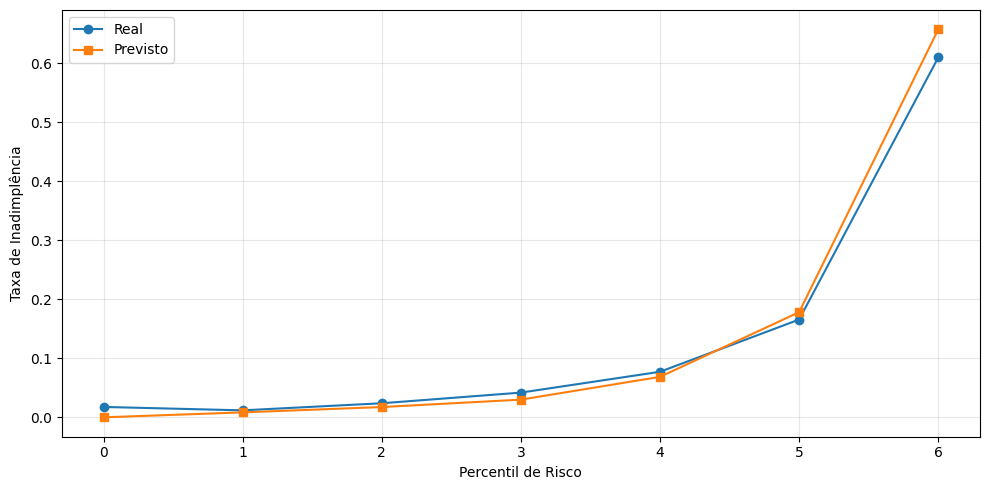

In [ ]:
df_eval = pd.DataFrame({
    'real': test_df_transf[target].values,
    'pred': test_df_transf['preds_r'].values
})

df_eval['percentil'] = pd.qcut(
    df_eval['pred'],
    q = 10,
    labels=False,
    duplicates='drop'
)

resultado = (
    df_eval
    .groupby('percentil')
    .agg(
        qtd = ('real', 'size'),
        taxa_real = ('real', 'mean'),
        taxa_prev = ('pred', 'mean'),
        mae=('real', lambda x: np.mean(np.abs(x - df_eval.loc[x.index, 'pred'])))
    )
    .reset_index()
)

plt.figure(figsize=(10,5))

plt.plot(resultado['percentil'],
         resultado['taxa_real'],
         marker = 'o',
         label = 'Real')

plt.plot(resultado['percentil'],
         resultado['taxa_prev'],
         marker = 's',
         label = 'Previsto')

plt.xlabel('Percentil de Risco')
plt.ylabel('Taxa de Inadimplência')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(
    '/content/drive/MyDrive/Estudos/USP/MBA/TCC/Projeto/output/Figures/decil_hurdle.pdf',
    bbox_inches='tight'
)

plt.show()

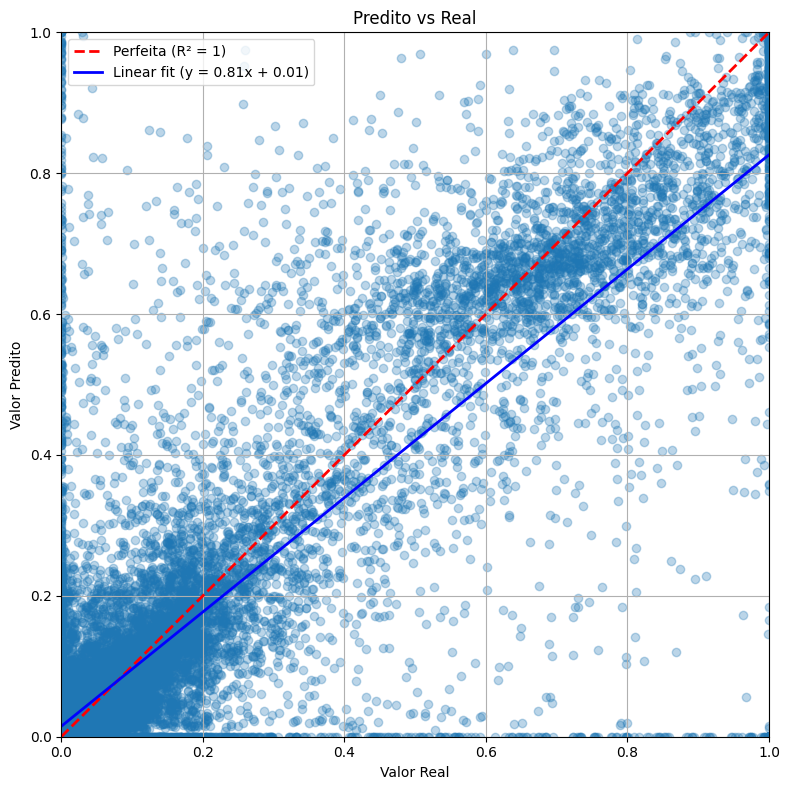

In [ ]:
y_true = test_df_transf[target]
y_pred = test_df_transf['preds_r'].values

plt.figure(figsize=(8, 8))

plt.scatter(y_true, y_pred, alpha=0.3)

# Limites comuns aos dois eixos
lims = [
    min(y_true.min(), y_pred.min()),
    max(y_true.max(), y_pred.max())
]

# Linha de referência: y = x (R² = 1)
plt.plot(
    lims,
    lims,
    'r--',
    linewidth=2,
    label='Perfeita (R² = 1)'
)

# Ajuste linear: y_pred = a * y_true + b
coef = np.polyfit(y_true, y_pred, 1)
a, b = coef

x_fit = np.linspace(lims[0], lims[1], 100)
y_fit = a * x_fit + b

plt.plot(
    x_fit,
    y_fit,
    color='blue',
    linewidth=2,
    label=f'Linear fit (y = {a:.2f}x + {b:.2f})'
)

plt.xlim(lims)
plt.ylim(lims)

plt.xlabel('Valor Real')
plt.ylabel('Valor Predito')
plt.title('Predito vs Real')

plt.legend()
plt.grid(True)
plt.tight_layout()

plt.savefig(
    '/content/drive/MyDrive/Estudos/USP/MBA/TCC/Projeto/output/Figures/dispersao_hurdle.pdf',
    bbox_inches='tight'
)

plt.show()

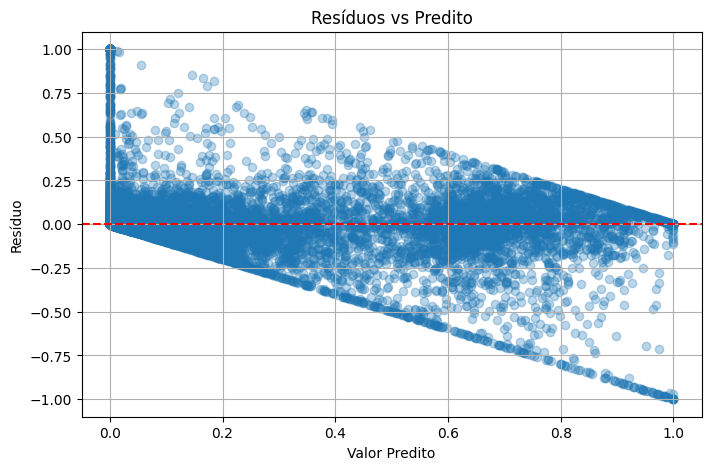

In [ ]:
residuos = y_true - test_df_transf['preds_r'].values

plt.figure(figsize=(8, 5))
plt.scatter(test_df_transf['preds_r'].values, residuos, alpha=0.3)
plt.axhline(0, color='red', linestyle='--')

plt.xlabel("Valor Predito")
plt.ylabel("Resíduo")
plt.title("Resíduos vs Predito")

plt.grid(True)
plt.show()

# Avaliação Final

## Forecasting Carteira

### Naive and Mean Method

In [ ]:
# Naive Method
# A carteira no momento t é preservada para todos os instantes t+h
df_resultados = test_df.copy()

df_resultados['anomes'] = test_ids
df_resultados['txa_inad_pred'] = test_df_transf['preds_r'] # txa_inad_pred
df_resultados['cart_ativ_naive'] = df_resultados['carteira_ativa']

# Mean method
# A carteira recebe a média do ano de 2024
df_cart_ativ = df_master[df_master['anomes'].astype(str).str[:4] == '2024']\
                    .groupby(chaves_grupo, observed = True)\
                    .agg(
                        mean_cart_ativ = ('carteira_ativa', lambda x: x.mean()),
                    )\
                    .reset_index()

In [ ]:
df_resultados_fim = df_resultados[chaves_grupo + ['cart_ativ_naive', 'anomes', 'horizonte', 'txa_inad_pred']]\
                        .merge(df_cart_ativ,
                            on = chaves_grupo,
                            how = 'left')

df_resultados_fim['cart_inad_pred_naive'] = df_resultados_fim['cart_ativ_naive'] * df_resultados_fim['txa_inad_pred']
df_resultados_fim['cart_inad_pred_mean'] = df_resultados_fim['mean_cart_ativ'] * df_resultados_fim['txa_inad_pred']

df_resultados_fim['anomes'] = (
    202500 + df_resultados_fim['horizonte']
).astype(str)

In [ ]:
df_avalia = df_resultados_fim\
    .merge(
        df_master_orig[['anomes', 'uf', 'segmento', 'porte', 'modalidade', 'carteira_ativa']],
        on = ['anomes', 'uf', 'segmento', 'porte', 'modalidade'],
        how = 'inner'
    )

y_true = df_avalia['carteira_ativa']
y_pred_naive = df_avalia['cart_ativ_naive']
y_pred_mean = df_avalia['mean_cart_ativ']

# 1. Cálculo do R² (Coeficiente de Determinação)
r2_naive = r2_score(y_true, y_pred_naive)
r2_mean = r2_score(y_true, y_pred_mean)

# 2. Cálculo do Desvio Padrão dos erros (Resíduos)
std_naive = np.std(y_true - y_pred_naive)
std_mean = np.std(y_true - y_pred_mean)

print("=== Performance: Carteira Ativa ===")
print(f"[Naive] R²: {r2_naive:.4f} | Desvio Padrão dos Erros: {std_naive/10**6:.2f}")
print(f"[Mean]  R²: {r2_mean:.4f} | Desvio Padrão dos Erros: {std_mean/10**6:.2f}")

=== Performance: Carteira Ativa ===
[Naive] R²: 0.9806 | Desvio Padrão dos Erros: 683.28
[Mean]  R²: 0.9662 | Desvio Padrão dos Erros: 899.30


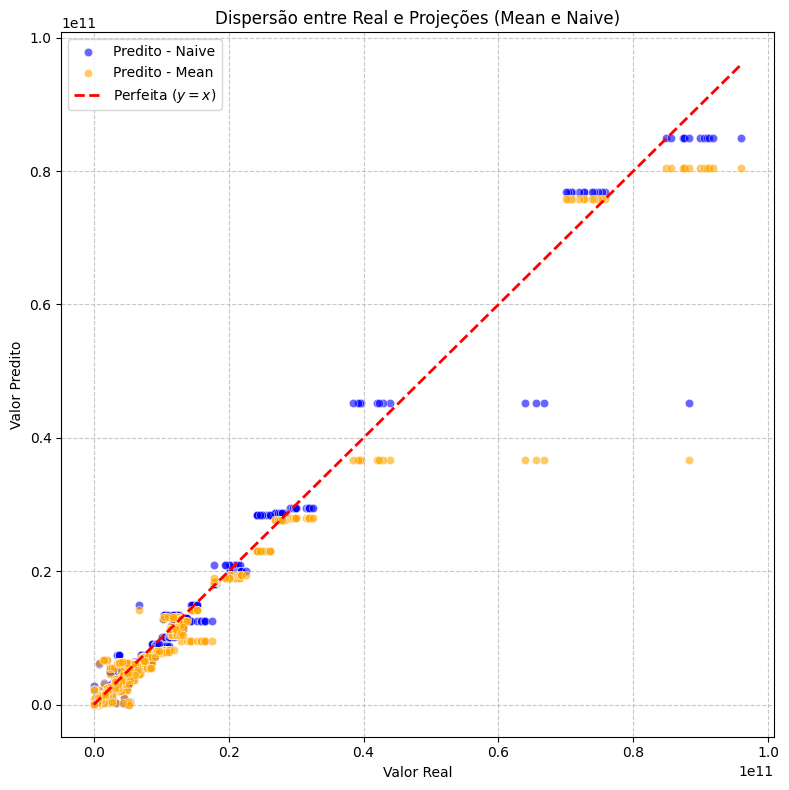

In [ ]:
plt.figure(figsize=(8, 8))

# Dispersão para o modelo Naive
sns.scatterplot(
    x=df_avalia['carteira_ativa'],
    y=df_avalia['cart_ativ_naive'],
    color='blue',
    alpha=0.6,
    label='Predito - Naive'
)

# Dispersão para o modelo Mean
sns.scatterplot(
    x=df_avalia['carteira_ativa'],
    y=df_avalia['mean_cart_ativ'],
    color='orange',
    alpha=0.6,
    label='Predito - Mean'
)

# Linha de identidade (y = x) para referência de predição perfeita
max_val = max(df_avalia['carteira_ativa'].max(), df_avalia['cart_ativ_naive'].max(), df_avalia['mean_cart_ativ'].max())
min_val = min(df_avalia['carteira_ativa'].min(), df_avalia['cart_ativ_naive'].min(), df_avalia['mean_cart_ativ'].min())

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    color='red',
    linestyle='--',
    linewidth=2,
    label='Perfeita ($y = x$)'
)

plt.title('Dispersão entre Real e Projeções (Mean e Naive)')
plt.xlabel('Valor Real')
plt.ylabel('Valor Predito')
plt.legend(loc='upper left')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()

plt.savefig(
    '/content/drive/MyDrive/Estudos/USP/MBA/TCC/Projeto/output/Figures/dispersao_carteira.pdf',
    bbox_inches='tight'
)

plt.show()

### Diferença entre Carteiras

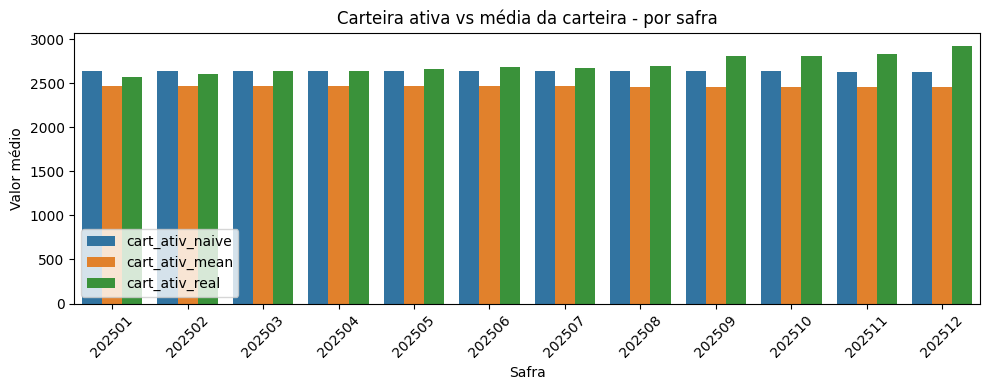

In [ ]:
df_cart_fcst = df_resultados_fim\
            .groupby('horizonte', observed=True)\
            .agg(
                cart_ativ_naive = ('cart_ativ_naive', lambda x: x.sum()/10**9),
                cart_ativ_mean = ('mean_cart_ativ', lambda x: x.sum()/10**9),
                # cart_ativ_drift = ('carteira_ativa_pred_drift', lambda x: x.sum()/10**9),
                # cart_ativ_snaive = ('carteira_ativa_pred_snaive', lambda x: x.sum()/10**9),
                # cart_ativ_ets = ('carteira_ativa_pred_ets', lambda x: x.sum()/10**9)
            )\
            .reset_index()\
            .sort_values('horizonte')

df_cart_fcst['anomes'] = (
    202500 + df_cart_fcst['horizonte']
).astype(str)

df_cart_real = df_master_orig\
                    .groupby('anomes', observed=True)\
                    .agg(
                        cart_ativ_real = ('carteira_ativa', lambda x: x.sum()/10**9)
                    )\
                    .reset_index()\
                    .sort_values('anomes')

df_plot = df_cart_fcst.merge(df_cart_real,
                             on = 'anomes',
                             how = 'inner')


plt.figure(figsize = (10, 4))
sns.barplot(
    data = df_plot.melt(
        id_vars = 'anomes',
        value_vars = ['cart_ativ_naive', 'cart_ativ_mean', 'cart_ativ_real'],
        var_name = 'feature',
        value_name = 'valor'
    ),
    x = 'anomes',
    y = 'valor',
    hue = 'feature'
)

plt.title('Carteira ativa vs média da carteira - por safra')
plt.xlabel('Safra')
plt.ylabel('Valor médio')
plt.xticks(rotation = 45)
plt.legend(loc='lower left')
plt.tight_layout()

plt.show()

## Resultados

/tmp/ipykernel_2936/44015726.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(['horizonte', 'uf'])\


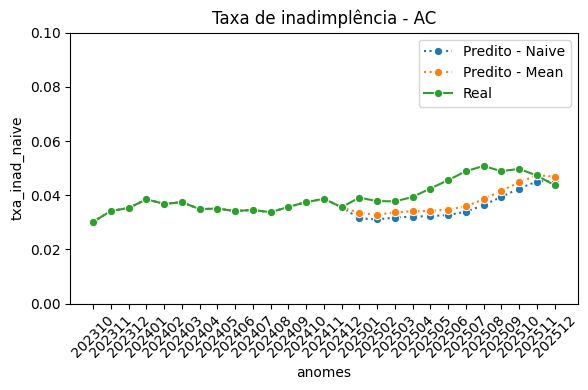

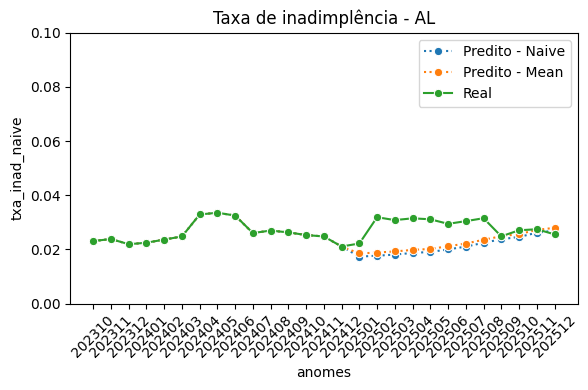

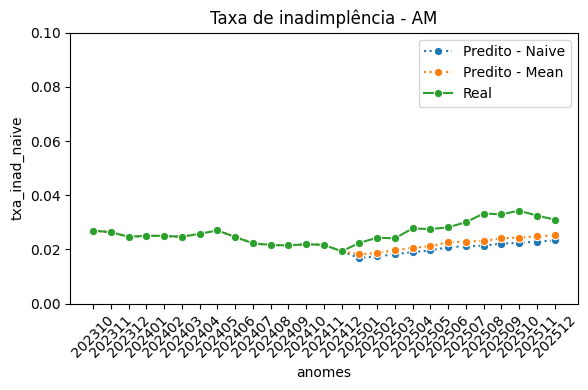

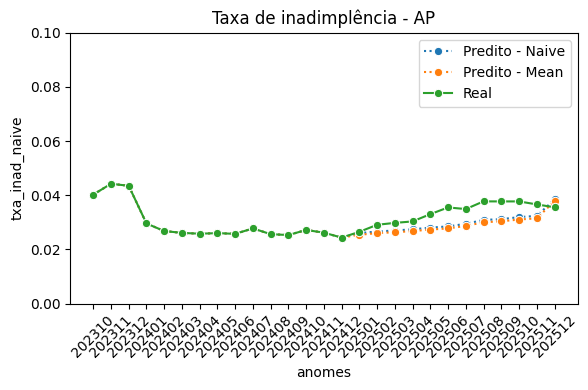

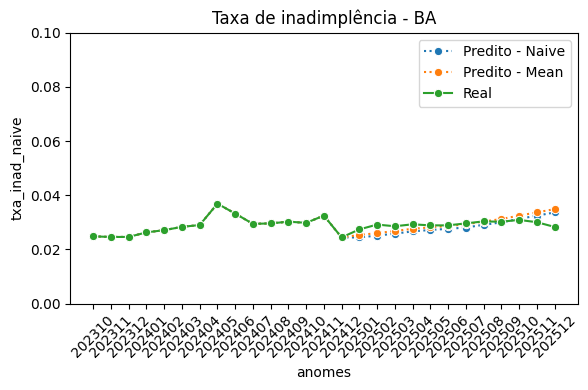

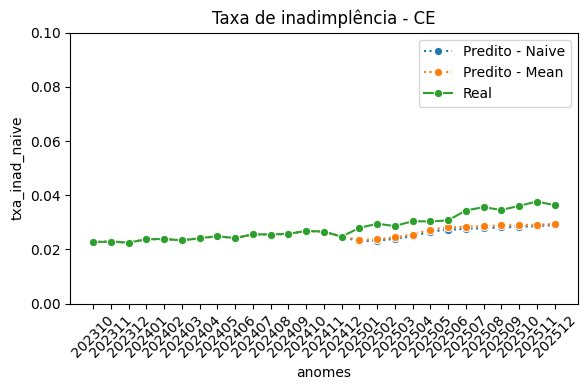

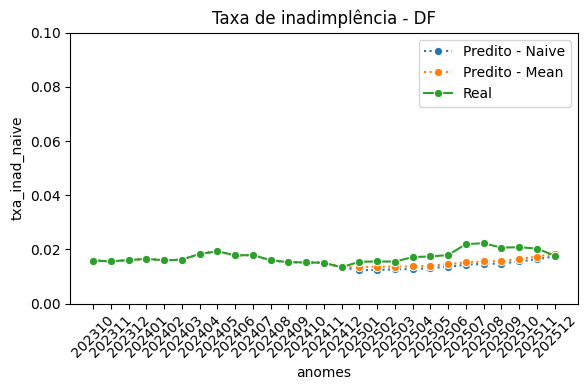

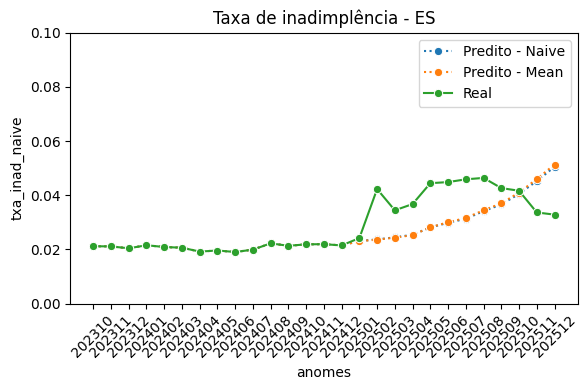

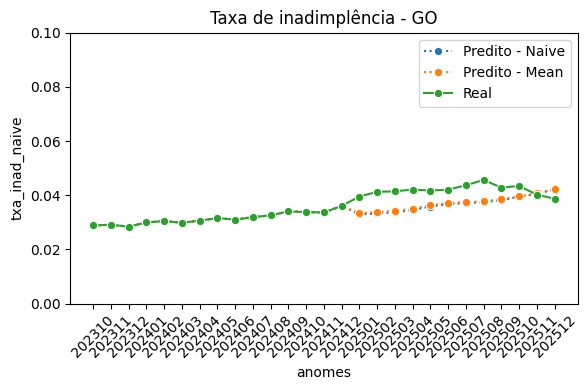

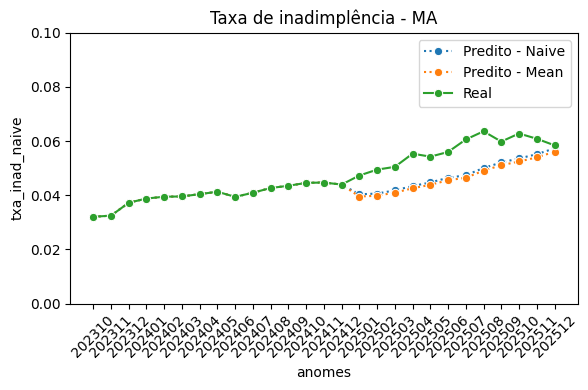

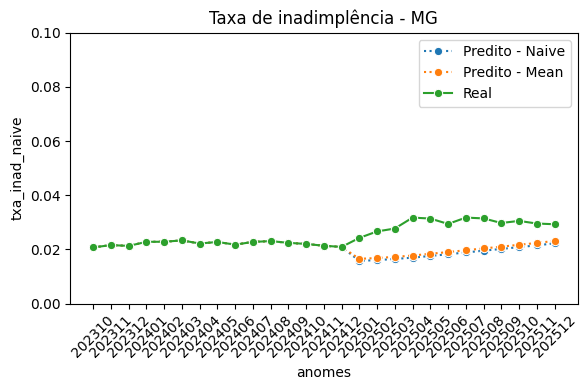

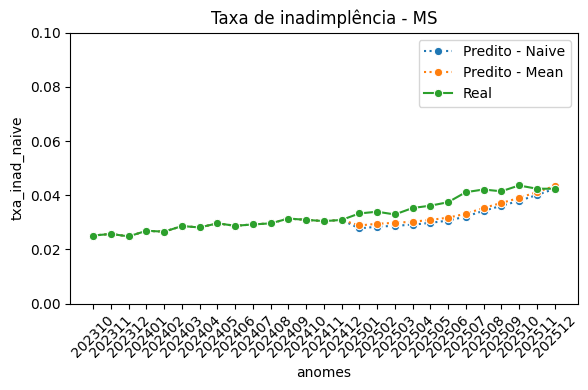

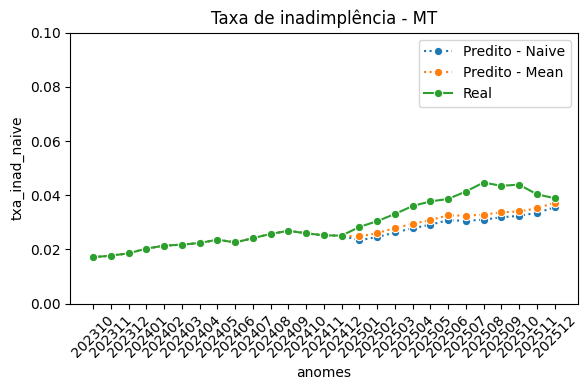

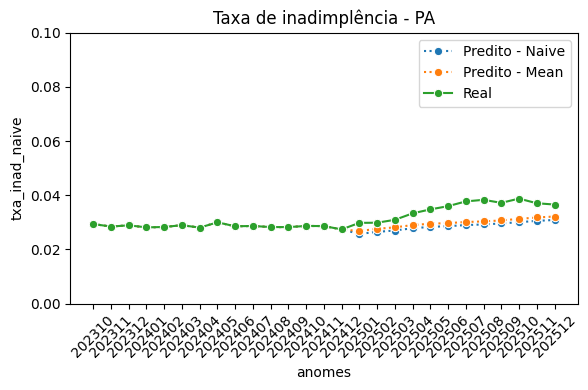

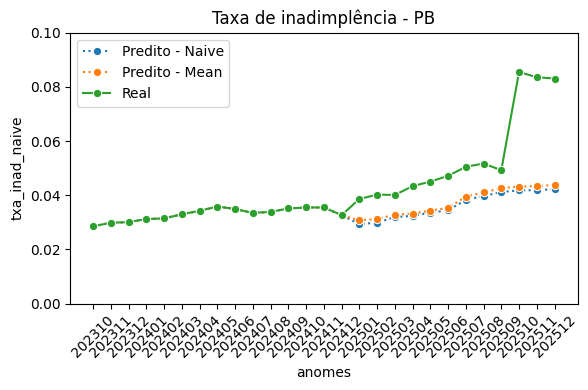

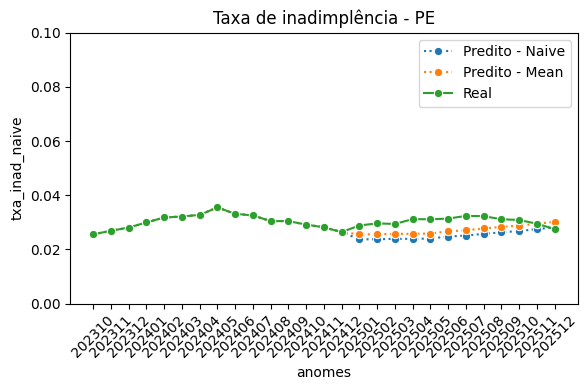

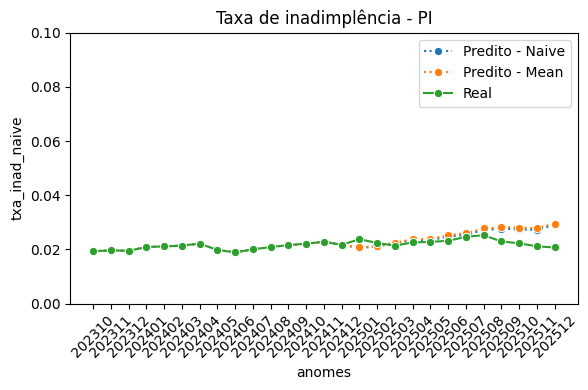

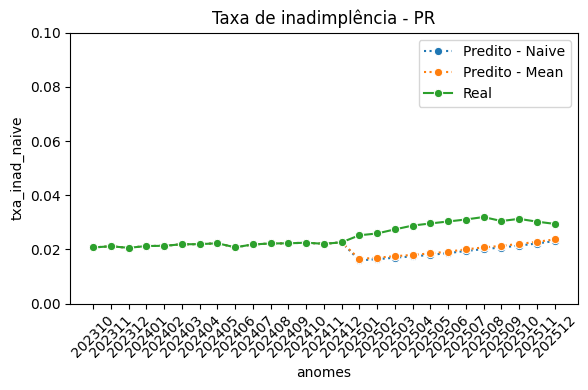

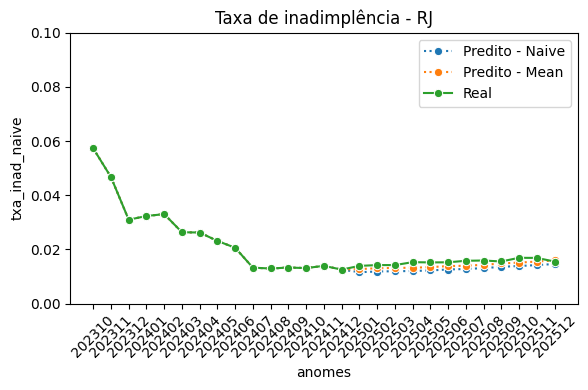

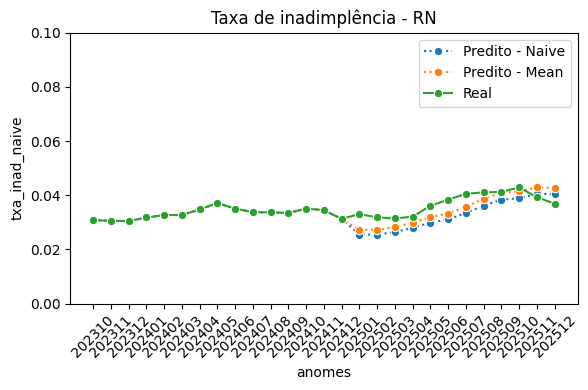

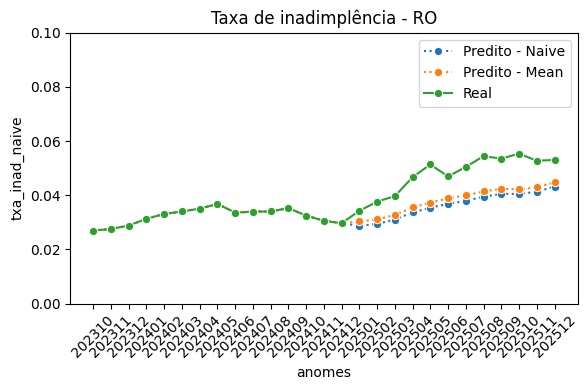

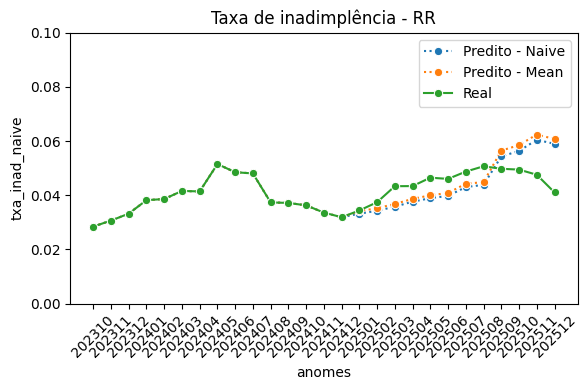

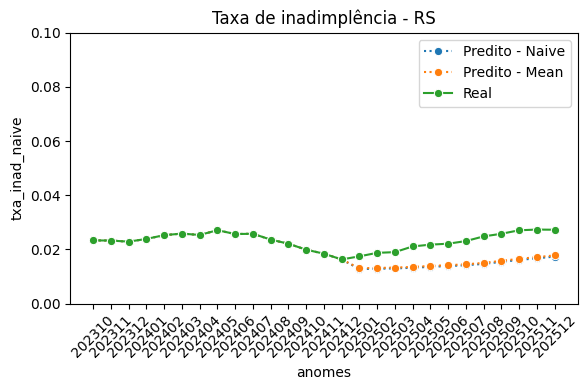

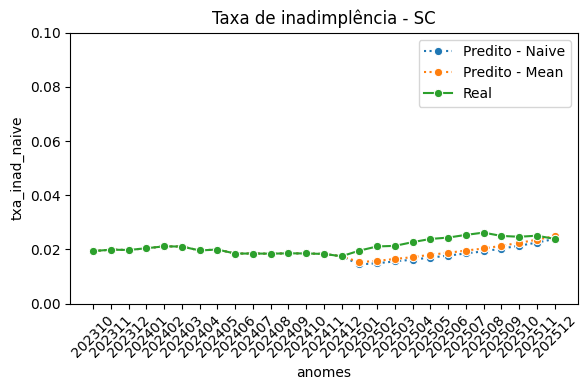

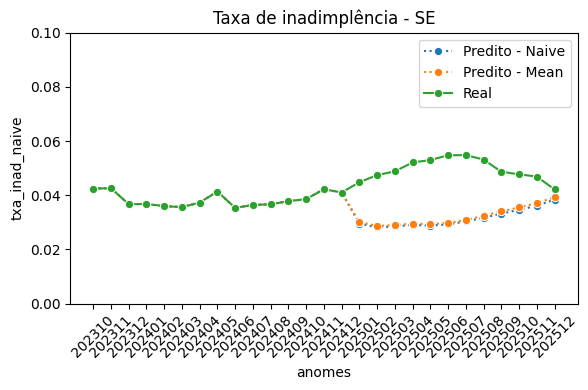

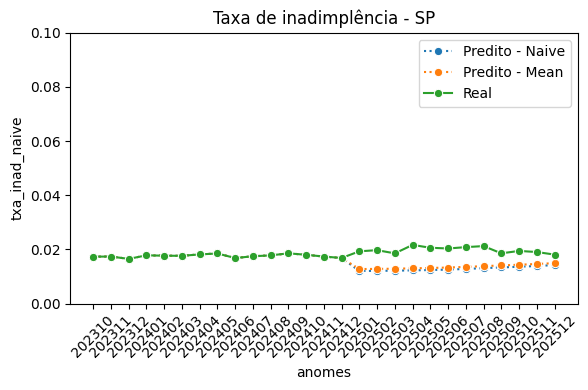

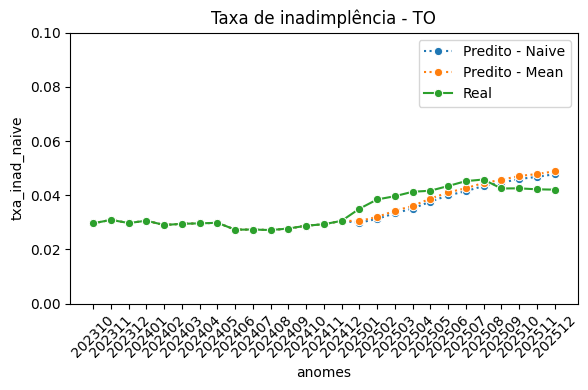

In [ ]:
# Calculo a  inadimplência real por UF
df_agg_real = df_master_orig\
                .groupby(['anomes', 'uf'], observed=True)\
                .agg(
                    cart_ativ = ('carteira_ativa', 'sum'),
                    cart_inad = ('carteira_inadimplencia', 'sum')
                )\
                .reset_index()
df_agg_real['txa_inad_real'] = df_agg_real['cart_inad'] / df_agg_real['cart_ativ']

# Calculo a inadimplência predita por UF
df_agg_pred = df_resultados_fim\
    .groupby(['horizonte', 'uf'])\
    .agg(
        cart_inad_pred_naive = ('cart_inad_pred_naive', 'sum'),
        cart_inad_pred_mean = ('cart_inad_pred_mean', 'sum'),
        cart_ativ_naive = ('cart_ativ_naive', 'sum'),
        mean_cart_ativ = ('mean_cart_ativ', 'sum'),
        # cart_ativ_drift = ('carteira_ativa_pred_drift', 'sum'),
        # cart_ativ_snaive = ('carteira_ativa_pred_snaive', 'sum'),
        # cart_ativ_ets = ('carteira_ativa_pred_ets', 'sum')
    ).reset_index()

df_agg_pred['txa_inad_naive'] = df_agg_pred['cart_inad_pred_naive'] / df_agg_pred['cart_ativ_naive']
df_agg_pred['txa_inad_mean'] = df_agg_pred['cart_inad_pred_mean'] / df_agg_pred['mean_cart_ativ']
# df_agg_pred['txa_inad_drift'] = df_agg_pred['cart_inad_pred'] / df_agg_pred['cart_ativ_drift']
# df_agg_pred['txa_inad_snaive'] = df_agg_pred['cart_inad_pred'] / df_agg_pred['cart_ativ_snaive']
# df_agg_pred['txa_inad_ets'] = df_agg_pred['cart_inad_pred'] / df_agg_pred['cart_ativ_ets']

# Transformo horizonte em anomes
df_agg_pred['anomes'] = (
    202500 + df_agg_pred['horizonte']
).astype(str)

# Histórico 2024
df_historico = df_agg_real[
    df_agg_real['anomes'].str[:4].isin(['2023', '2024'])
][['anomes', 'uf', 'txa_inad_real']].copy()
df_historico['txa_inad_naive'] = df_historico['txa_inad_real']
df_historico['txa_inad_mean'] = df_historico['txa_inad_real']


# Projeção 2025
df_projecao = df_agg_pred\
    .merge(
        df_agg_real[['anomes', 'uf', 'txa_inad_real']],
        on = ['anomes', 'uf'],
        how = 'left'
    )\
    [['anomes', 'uf', 'txa_inad_real', 'txa_inad_naive', 'txa_inad_mean']]


# Base final
df_final = pd.concat(
    [df_historico, df_projecao],
    ignore_index = True
)\
.sort_values(['uf', 'anomes'])\
.reset_index(drop=True)

l_uf = ['SP', 'PR', 'BA', 'GO']

# Plot por UF
for uf in df_final['uf'].unique():

    df_plot = df_final[df_final['uf'] == uf].sort_values('anomes')
    plt.figure(figsize = (6, 4))
    # Gráfico
    sns.lineplot(
        data = df_plot,
        x = 'anomes',
        y = 'txa_inad_naive',
        label = 'Predito - Naive',
        linestyle = ':',
        marker = 'o'
    )

    sns.lineplot(
        data = df_plot,
        x = 'anomes',
        y = 'txa_inad_mean',
        label = 'Predito - Mean',
        linestyle = ':',
        marker = 'o'
    )

    sns.lineplot(
        data = df_plot,
        x = 'anomes',
        y = 'txa_inad_real',
        label = 'Real',
        linestyle = '-',
        marker = 'o'
    )

    plt.title(f'Taxa de inadimplência - {uf}')
    plt.ylim(0, 0.1)
    plt.xticks(rotation = 45)
    plt.tight_layout()

    plt.savefig(
        f'/content/drive/MyDrive/Estudos/USP/MBA/TCC/Projeto/output/Figures/UF/curva_projetada_{uf}.pdf',
        bbox_inches='tight'
    )

    plt.show()

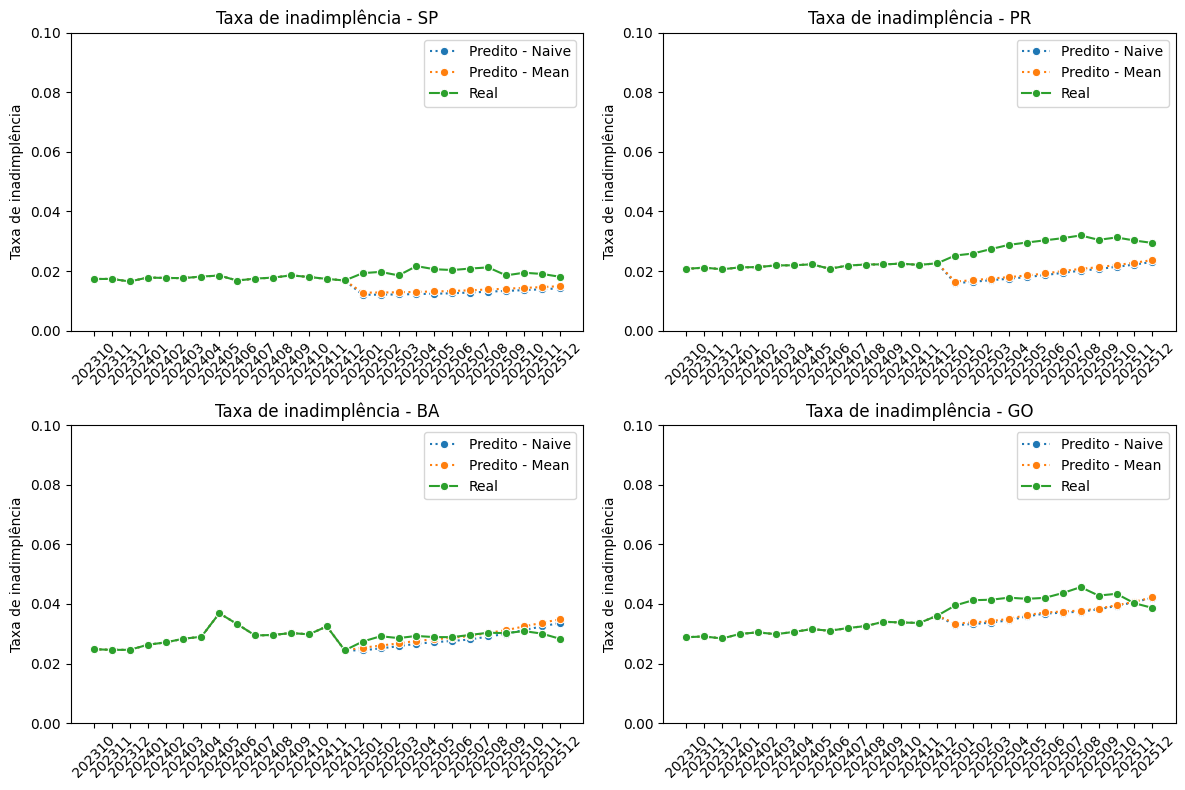

In [ ]:
l_uf = ['SP', 'PR', 'BA', 'GO']

# Figura 2 x 2
fig, axes = plt.subplots(
    nrows = 2,
    ncols = 2,
    figsize = (12, 8)
)

axes = axes.flatten()

for ax, uf in zip(axes, l_uf):

    df_plot = (
        df_final[df_final['uf'] == uf]
        .sort_values('anomes')
    )

    # Predito - Naive
    sns.lineplot(
        data = df_plot,
        x = 'anomes',
        y = 'txa_inad_naive',
        label = 'Predito - Naive',
        linestyle = ':',
        marker = 'o',
        ax = ax
    )

    # Predito - Mean
    sns.lineplot(
        data = df_plot,
        x = 'anomes',
        y = 'txa_inad_mean',
        label = 'Predito - Mean',
        linestyle = ':',
        marker = 'o',
        ax = ax
    )

    # Real
    sns.lineplot(
        data = df_plot,
        x = 'anomes',
        y = 'txa_inad_real',
        label = 'Real',
        linestyle = '-',
        marker = 'o',
        ax = ax
    )

    ax.set_title(f'Taxa de inadimplência - {uf}')
    ax.set_ylim(0, 0.1)
    ax.tick_params(axis = 'x', rotation = 45)

    ax.set_xlabel('')
    ax.set_ylabel('Taxa de inadimplência')

    ax.legend()

# Ajustes da figura
plt.tight_layout()

plt.savefig(
    '/content/drive/MyDrive/Estudos/USP/MBA/TCC/Projeto/output/Figures/UF/curvas_projetadas_2x2.pdf',
    bbox_inches = 'tight'
)

plt.show()

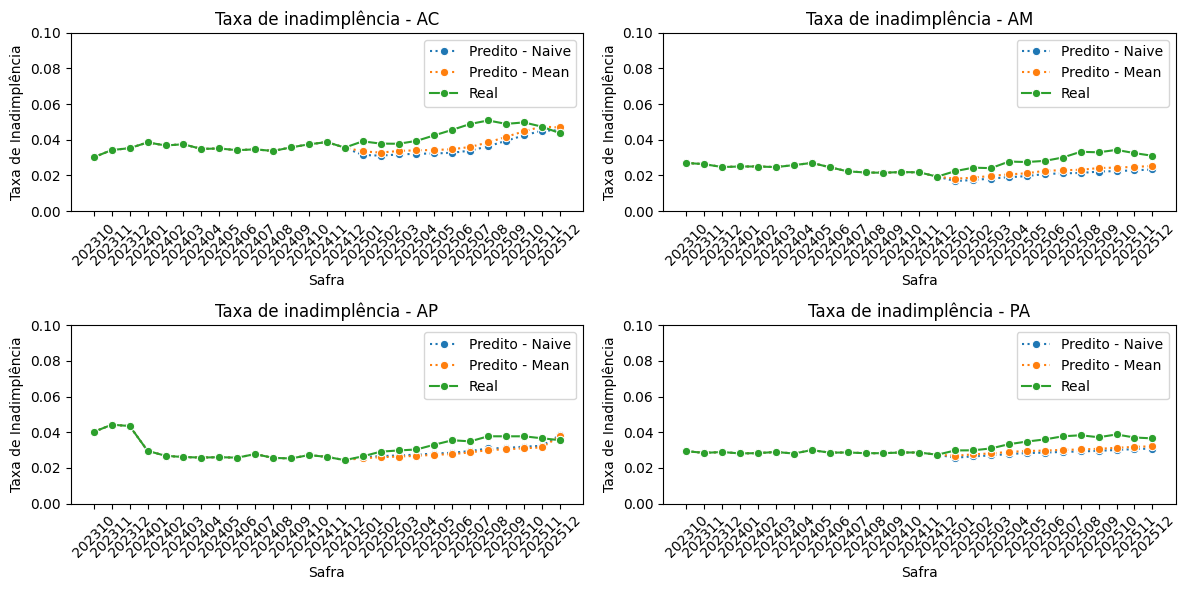

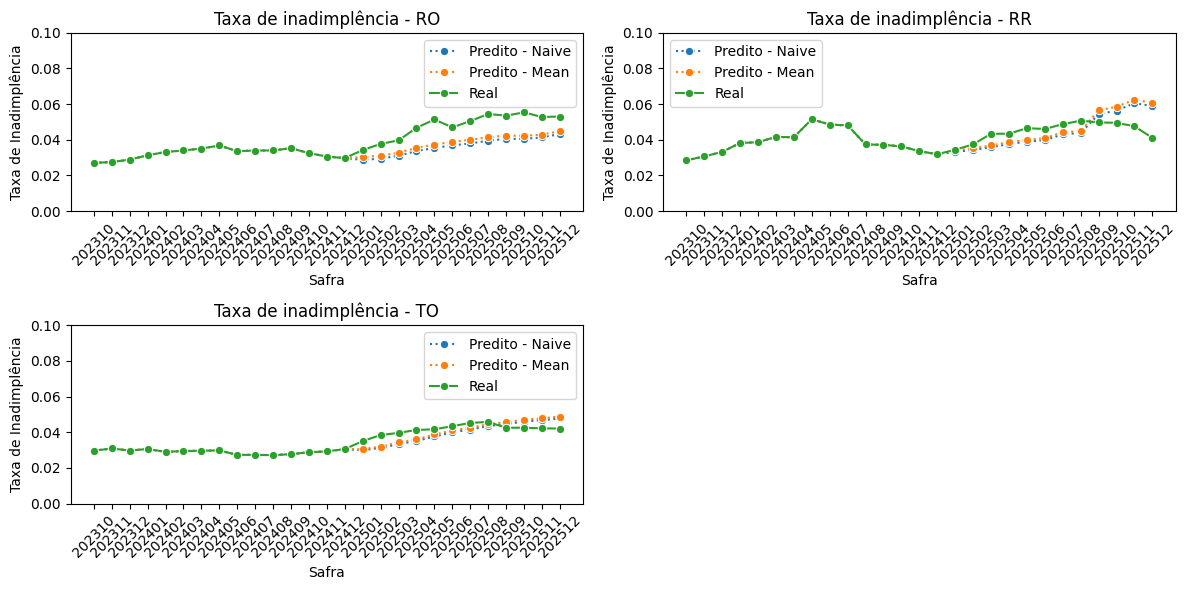

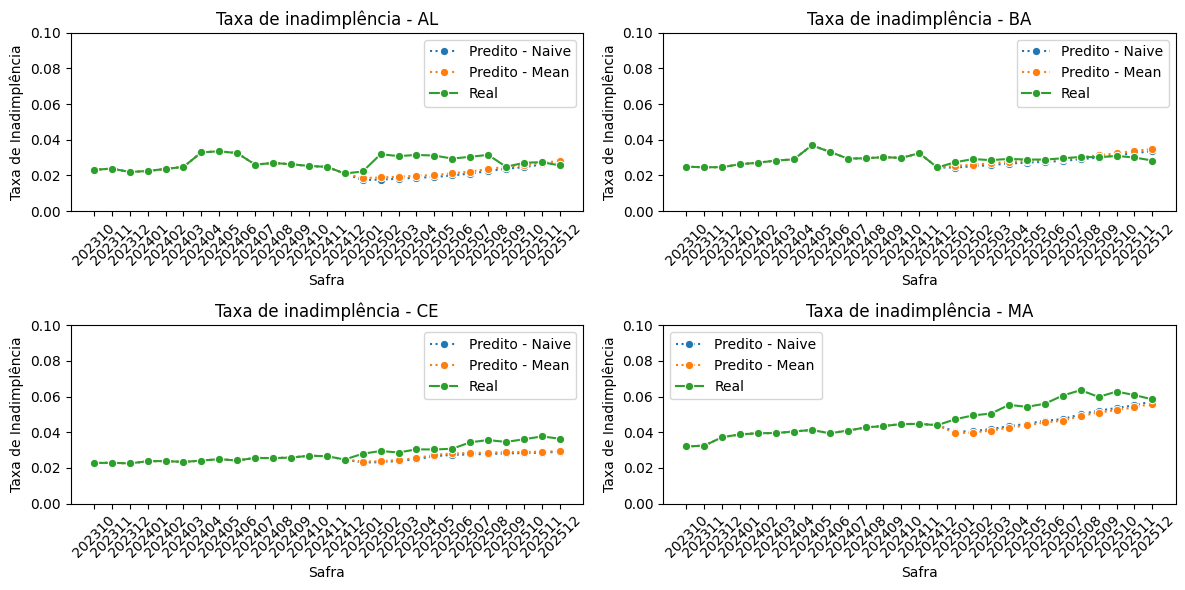

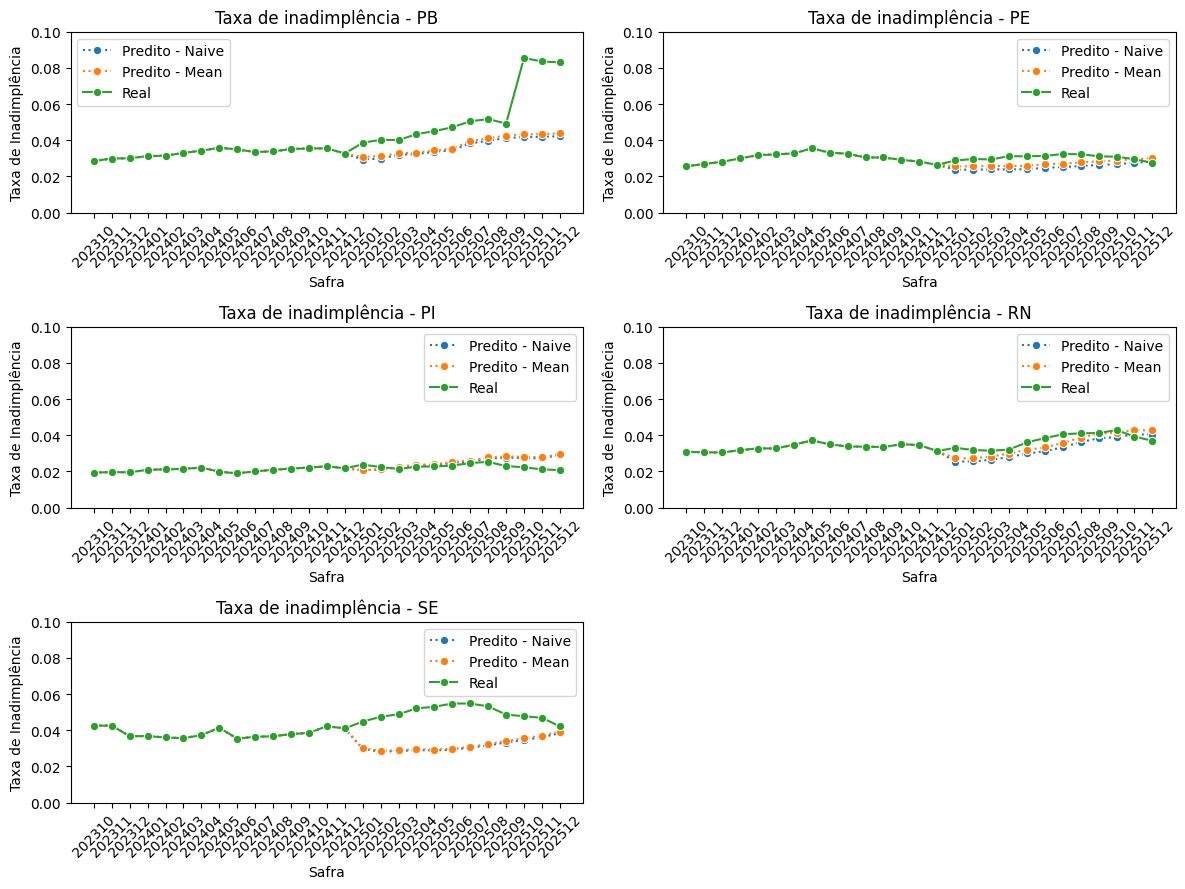

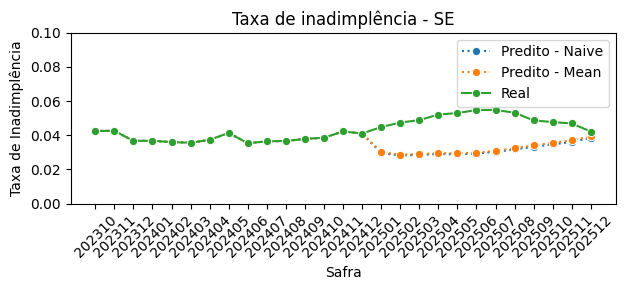

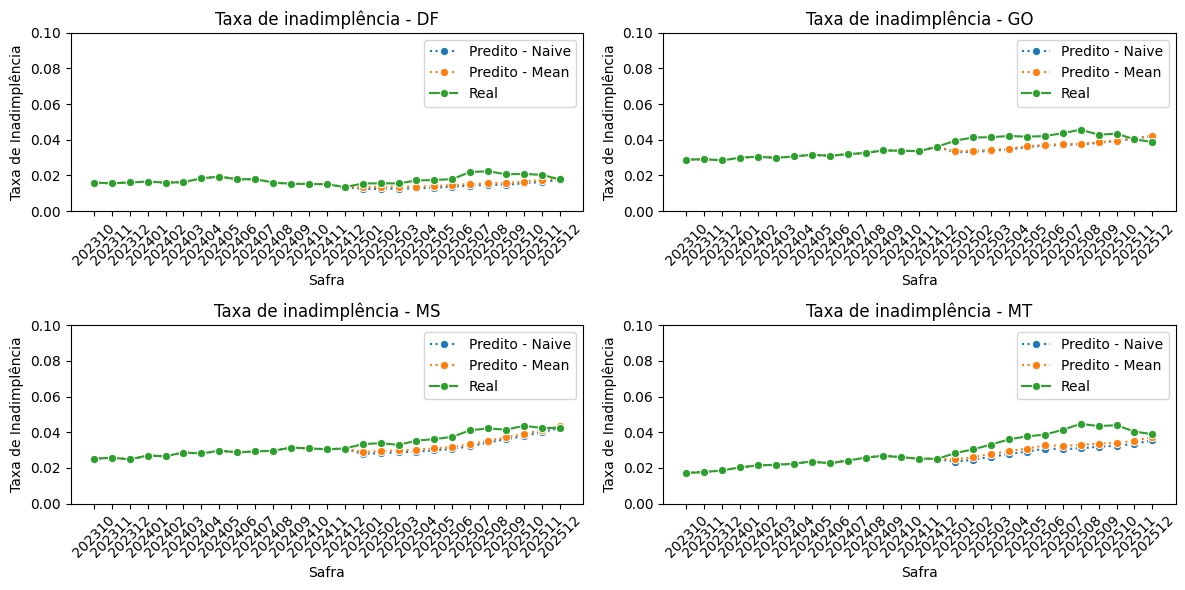

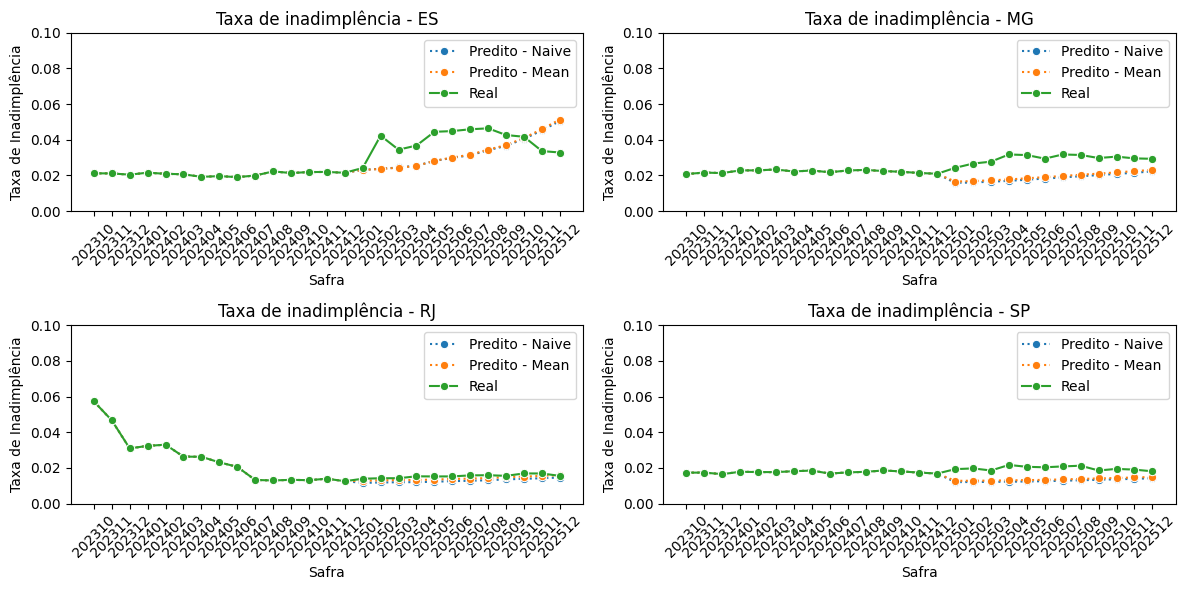

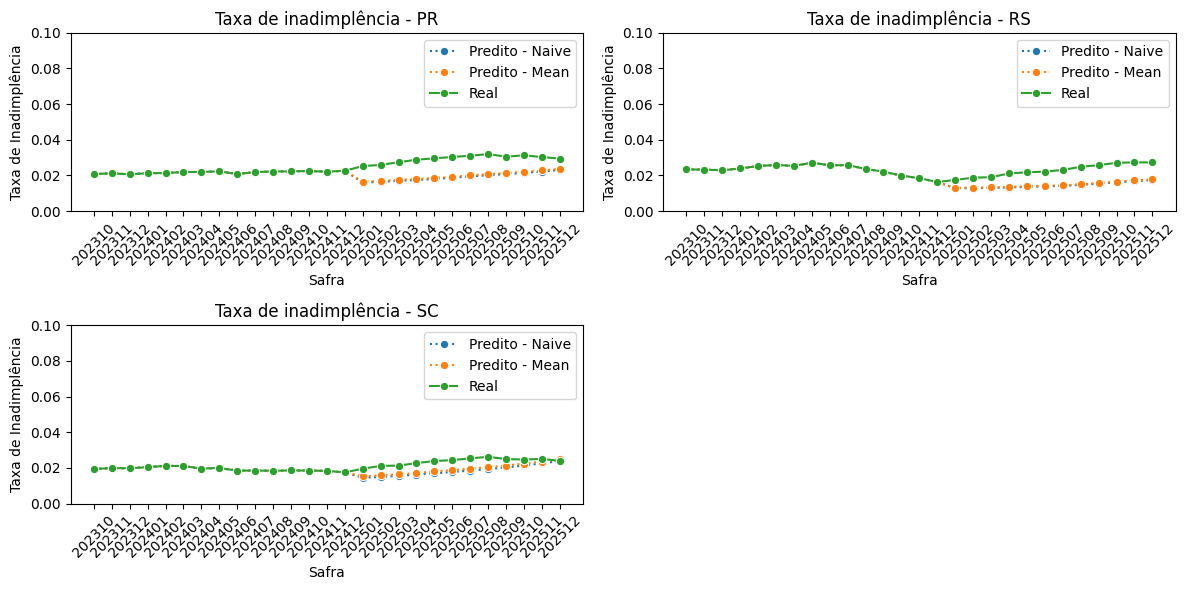

In [ ]:
import math

# Mapeamento oficial das UFs por região
regioes_br = {
    'Norte1': ['AC', 'AM', 'AP', 'PA'],
    'Norte2': ['RO', 'RR', 'TO'],
    'Nordeste1': ['AL', 'BA', 'CE', 'MA', ],
    'Nordeste2': ['PB', 'PE', 'PI', 'RN', 'SE'],
    'Nordeste3': ['SE'],
    'Centro_Oeste': ['DF', 'GO', 'MS', 'MT'],
    'Sudeste': ['ES', 'MG', 'RJ', 'SP'],
    'Sul': ['PR', 'RS', 'SC']
}

# Plot em blocos por região
for regiao, ufs in regioes_br.items():

    # Define o tamanho do grid (2 colunas, linhas dinâmicas)
    n_ufs = len(ufs)
    cols = 2
    rows = math.ceil(n_ufs / cols)

    # Cria a figura e os eixos
    fig, axes = plt.subplots(rows, cols, figsize=(12, 3*rows))
    axes = axes.flatten() # Transforma a matriz de eixos em um array 1D para facilitar o loop

    for i, uf in enumerate(ufs):
        ax = axes[i]
        df_plot = df_final[df_final['uf'] == uf].sort_values('anomes')

        # Gráficos (passando o parâmetro ax=ax para plotar no subplot correto)
        sns.lineplot(
            data = df_plot, x = 'anomes', y = 'txa_inad_naive',
            label = 'Predito - Naive', linestyle = ':', marker = 'o', ax=ax
        )
        sns.lineplot(
            data = df_plot, x = 'anomes', y = 'txa_inad_mean',
            label = 'Predito - Mean', linestyle = ':', marker = 'o', ax=ax
        )
        sns.lineplot(
            data = df_plot, x = 'anomes', y = 'txa_inad_real',
            label = 'Real', linestyle = '-', marker = 'o', ax=ax
        )

        ax.set_title(f'Taxa de inadimplência - {uf}')
        ax.set_ylim(0, 0.1)
        ax.tick_params(axis='x', rotation=45)
        ax.set_xlabel('Safra')
        ax.set_ylabel('Taxa de Inadimplência')

    # Remove os subplots vazios caso a região tenha um número ímpar de UFs
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()

    # Salva um PDF por região
    plt.savefig(
        f'/content/drive/MyDrive/Estudos/USP/MBA/TCC/Projeto/output/Figures/UF/curva_projetada_{regiao}.pdf',
        bbox_inches='tight'
    )
    plt.show()

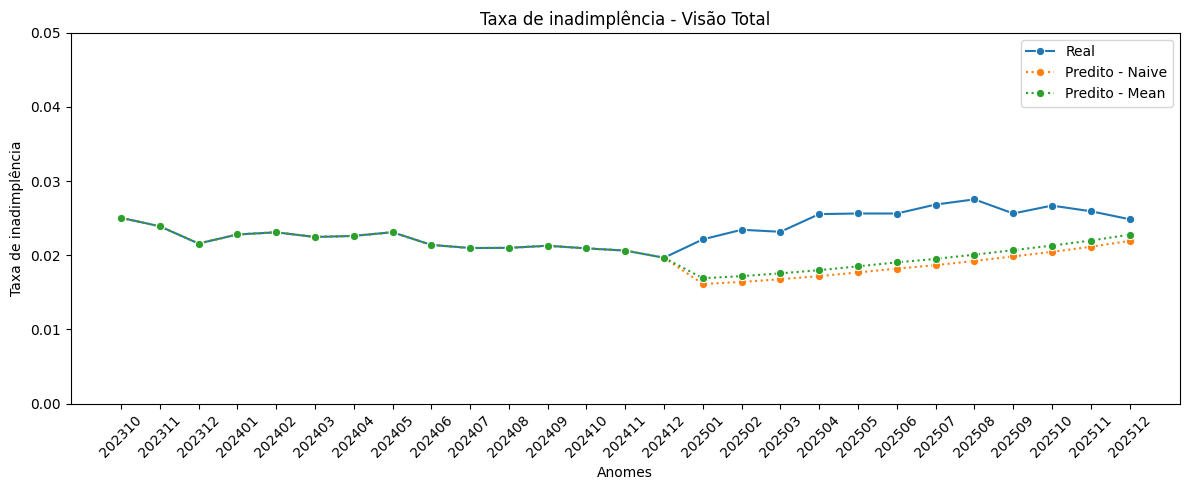

In [ ]:
# Real
df_agg_real = df_master_orig\
    .groupby(['anomes'], observed=True)\
    .agg(
        cart_ativ = ('carteira_ativa', 'sum'),
        cart_inad = ('carteira_inadimplencia', 'sum')
    )\
    .reset_index()

df_agg_real['txa_inad_real'] = df_agg_real['cart_inad'] / df_agg_real['cart_ativ']


# Predito
df_agg_pred = df_resultados_fim\
    .groupby(['horizonte'])\
    .agg(
        cart_inad_pred_naive = ('cart_inad_pred_naive', 'sum'),
        cart_inad_pred_mean = ('cart_inad_pred_mean', 'sum'),
        cart_ativ_naive = ('cart_ativ_naive', 'sum'),
        mean_cart_ativ = ('mean_cart_ativ', 'sum')
    )\
    .reset_index()

df_agg_pred['txa_inad_naive'] = df_agg_pred['cart_inad_pred_naive'] / df_agg_pred['cart_ativ_naive']
df_agg_pred['txa_inad_mean'] = df_agg_pred['cart_inad_pred_mean'] / df_agg_pred['mean_cart_ativ']

df_agg_pred['anomes'] = (202500 + df_agg_pred['horizonte']).astype(str)


# Histórico 2024
df_historico = df_agg_real[
    df_agg_real['anomes'].str[:4].isin(['2023', '2024'])
][['anomes', 'txa_inad_real']].copy()

df_historico['txa_inad_naive'] = df_historico['txa_inad_real']
df_historico['txa_inad_mean'] = df_historico['txa_inad_real']


# Projeção 2025
df_projecao = df_agg_pred\
    .merge(
        df_agg_real[['anomes', 'txa_inad_real']],
        on = 'anomes',
        how = 'left'
    )\
    [['anomes', 'txa_inad_real', 'txa_inad_naive', 'txa_inad_mean']]


# Base final
df_final = pd.concat(
    [df_historico, df_projecao],
    ignore_index = True
)\
.sort_values('anomes')\
.reset_index(drop=True)


# Plot comparativo
plt.figure(figsize=(12, 5))

sns.lineplot(
    data = df_final,
    x = 'anomes',
    y = 'txa_inad_real',
    label = 'Real',
    marker = 'o',
    linestyle = '-'
)

sns.lineplot(
    data = df_final,
    x = 'anomes',
    y = 'txa_inad_naive',
    label = 'Predito - Naive',
    marker = 'o',
    linestyle = ':'
)

sns.lineplot(
    data = df_final,
    x = 'anomes',
    y = 'txa_inad_mean',
    label = 'Predito - Mean',
    marker = 'o',
    linestyle = ':'
)

plt.title('Taxa de inadimplência - Visão Total')
plt.xlabel('Anomes')
plt.ylabel('Taxa de inadimplência')
plt.ylim(0, 0.05)
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

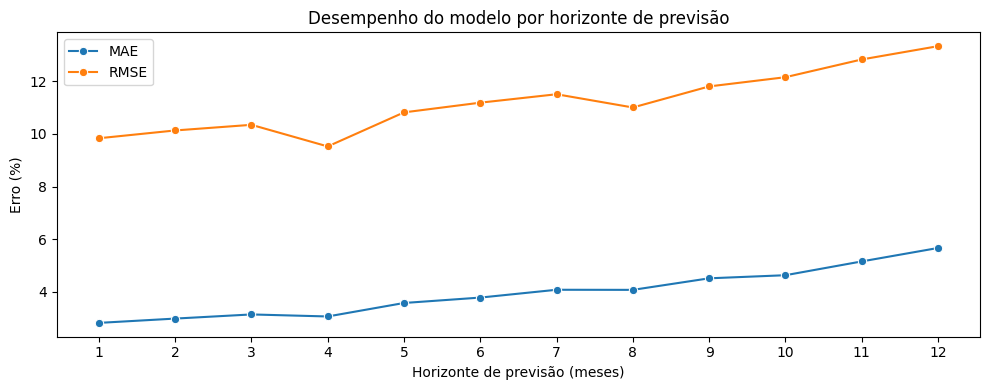

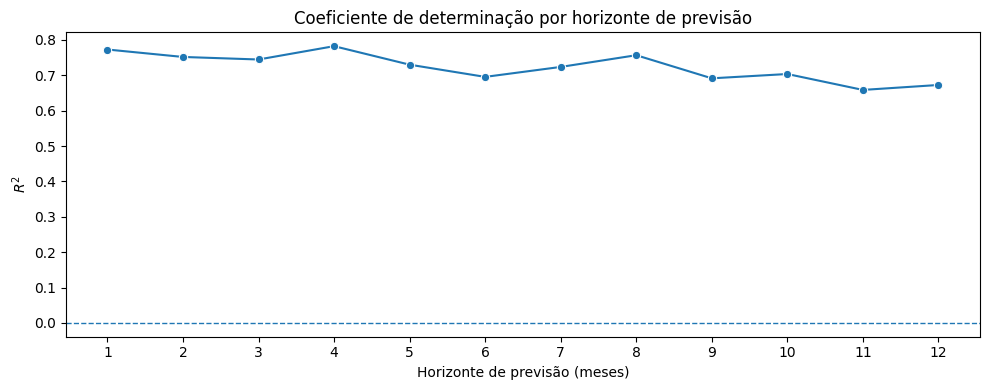

In [ ]:
df_horizonte = (
    df_resultados
    .groupby('horizonte', observed=True)
    .apply(
        lambda x: pd.Series({
            'MAE': mean_absolute_error(x['txa_inad'], x['txa_inad_pred']),
            'RMSE': np.sqrt(mean_squared_error(x['txa_inad'], x['txa_inad_pred'])),
            'R2': r2_score(x['txa_inad'], x['txa_inad_pred']),
            'N': len(x)
        }),
        include_groups=False
    )
    .reset_index()
)

df_plot = df_horizonte.copy()

df_plot[['MAE', 'RMSE']] *= 100

plt.figure(figsize=(10, 4))

sns.lineplot(
    data=df_plot,
    x='horizonte',
    y='MAE',
    marker='o',
    label='MAE'
)

sns.lineplot(
    data=df_plot,
    x='horizonte',
    y='RMSE',
    marker='o',
    label='RMSE'
)

plt.xlabel('Horizonte de previsão (meses)')
plt.ylabel('Erro (%)')
plt.title('Desempenho do modelo por horizonte de previsão')
plt.xticks(range(1, 13))
plt.legend()
plt.tight_layout()

plt.savefig(
    '/content/drive/MyDrive/Estudos/USP/MBA/TCC/Projeto/output/Figures/evolucao_mae_rmse.pdf',
    bbox_inches='tight'
)

plt.show()

plt.figure(figsize=(10, 4))

sns.lineplot(
    data=df_horizonte,
    x='horizonte',
    y='R2',
    marker='o'
)

plt.axhline(0, linestyle='--', linewidth=1)

plt.xlabel('Horizonte de previsão (meses)')
plt.ylabel('$R^2$')
plt.title('Coeficiente de determinação por horizonte de previsão')
plt.xticks(range(1, 13))
plt.tight_layout()


plt.savefig(
    '/content/drive/MyDrive/Estudos/USP/MBA/TCC/Projeto/output/Figures/evolucao_r2.pdf',
    bbox_inches='tight'
)

plt.show()

In [ ]:
df_plot

,horizonte,MAE,RMSE,R2,N
0,1,2.8141,9.8345,0.7727,3452.0000
1,2,2.9777,10.1310,0.7517,3442.0000
2,3,3.1353,10.3453,0.7445,3426.0000
3,4,3.0582,9.5234,0.7822,3414.0000
4,5,3.5709,10.8185,0.7299,3401.0000
5,6,3.7765,11.1876,0.6954,3384.0000
6,7,4.0735,11.5079,0.7235,3321.0000
7,8,4.0696,11.0043,0.7566,3274.0000
8,9,4.5090,11.8054,0.6913,3243.0000
9,10,4.6269,12.1561,0.7035,3217.0000


/usr/local/lib/python3.13/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor
Received: inputs=['Tensor(shape=(300, 93))']
  warnings.warn(msg)
/usr/local/lib/python3.13/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor
Received: inputs=['Tensor(shape=(50, 93))']
  warnings.warn(msg)
/tmp/ipykernel_2936/329481609.py:41: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


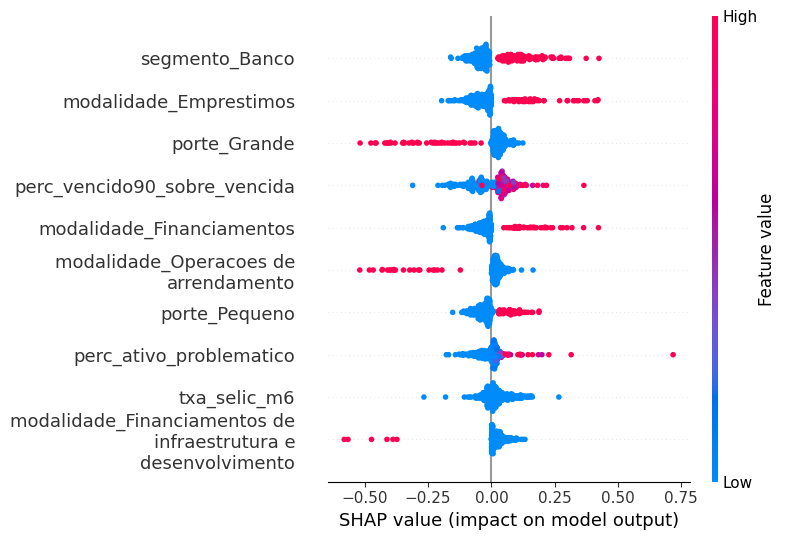

In [ ]:
import textwrap

# ============================================================
# SHAP — MLP Classificador
# P(Y > 0 | X)
# ============================================================

# Background pequeno para acelerar o cálculo
background_c = train_df_transf[predictors].sample(
    n=min(100, len(train_df_transf)),
    random_state=42
)

# Amostra para explicação
X_test_shap_c = test_df_transf[predictors].sample(
    n=min(300, len(test_df_transf)),
    random_state=42
)

# GradientExplainer para rede neural
explainer_c = shap.GradientExplainer(
    mlp_classif,
    background_c.values
)

shap_values_c = explainer_c.shap_values(
    X_test_shap_c.values
)

# Ajuste para diferentes versões do SHAP
if isinstance(shap_values_c, list):
    shap_values_c = shap_values_c[0]

shap_values_c = np.squeeze(shap_values_c)

# Formatação dos nomes das features para o Classificador
max_chars = 30
feature_names_c = [textwrap.fill(col, width=max_chars) for col in X_test_shap_c.columns]

# Gráfico
shap.summary_plot(
    shap_values_c,
    X_test_shap_c,
    feature_names=feature_names_c,
    max_display = 10,
    show = False
)

plt.savefig(
    '/content/drive/MyDrive/Estudos/USP/MBA/TCC/Projeto/output/Figures/shap_classif.pdf',
    bbox_inches='tight'
)
plt.show()
plt.close()

In [ ]:
# ============================================================
# SHAP — MLP Regressor
# E[Y | Y > 0, X]
# ============================================================

# Apenas observações que passam pelo classificador
mask_shap = test_df_transf['probs_test_c_calib'] > 0.5

# Número disponível de observações positivas
n_shap_r = min(300, mask_shap.sum())

X_test_shap_r = test_df_transf.loc[
    mask_shap,
    predictors
].sample(
    n=n_shap_r,
    random_state=42
)

# Background do regressor
# Idealmente, observações positivas do treinamento
mask_train_positive = train_df_transf[target] > 0

background_r = train_df_transf.loc[
    mask_train_positive,
    predictors
].sample(
    n=min(100, mask_train_positive.sum()),
    random_state=42
)

# GradientExplainer
explainer_r = shap.GradientExplainer(
    mlp_regress,
    background_r.values
)

shap_values_r = explainer_r.shap_values(
    X_test_shap_r.values
)

# Ajuste para diferentes versões do SHAP
if isinstance(shap_values_r, list):
    shap_values_r = shap_values_r[0]

shap_values_r = np.squeeze(shap_values_r)

# Formatação dos nomes das features para o Regressor
feature_names_r = [textwrap.fill(col, width=max_chars) for col in X_test_shap_r.columns]

# Gráfico
shap.summary_plot(
    shap_values_r,
    X_test_shap_r,
    feature_names=feature_names_r,
    max_display = 10,
    show = False
)
plt.savefig(
    '/content/drive/MyDrive/Estudos/USP/MBA/TCC/Projeto/output/Figures/shap_regress.pdf',
    bbox_inches='tight'
)

plt.close()

/usr/local/lib/python3.13/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor
Received: inputs=['Tensor(shape=(300, 93))']
  warnings.warn(msg)
/usr/local/lib/python3.13/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor
Received: inputs=['Tensor(shape=(50, 93))']
  warnings.warn(msg)
/tmp/ipykernel_2936/222673829.py:52: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(
